### Warp tfMRI to MNI

In [ ]:
import os
import subprocess
from datetime import datetime
from concurrent.futures import ProcessPoolExecutor, as_completed

def warp_to_mni(subject_dir, task):
    """
    Warp a subject's functional data for a given task to MNI space using FSL's applywarp.
    Ensures no existing files are overwritten by appending a timestamp if needed.
    """
    bold_dir     = os.path.join(subject_dir, 'BOLD', task, 'preprocessing')
    anat_reg_dir = os.path.join(subject_dir, 'anatomy', 'preprocessing', 'reg2MNI152')
    proc_dir     = os.path.join(bold_dir, f'{task}.ica_aroma', 'nr_wm_csf', 'highpassfilter')

    input_nii   = os.path.join(proc_dir, 'denoised_func_data_nonaggr_res_pp.nii.gz')
    premat      = os.path.join(bold_dir, 'reg', f'{task}_example_func_ns2highres.mat')
    warp_coeff  = os.path.join(anat_reg_dir, 'highres2reference_warp.nii.gz')
    ref         = os.path.join(anat_reg_dir, 'reference_brain.nii.gz')
    output_nii  = os.path.join(proc_dir, 'denoised_func_data_nonaggr_res_pp2MNI152.nii.gz')

    # Check inputs
    for f in (input_nii, premat, warp_coeff, ref):
        if not os.path.exists(f):
            raise FileNotFoundError(f"Missing file for {task} in {os.path.basename(subject_dir)}: {f}")

    if os.path.exists(output_nii):
        raise FileExistsError(f"{output_nii} already exists - stopping to avoid overwrite")


    cmd = [
        "applywarp",
        "--ref="+ref,
        "--in=" + input_nii,
        "--warp=" + warp_coeff,
        "--premat="+premat,
        "--out="+output_nii
    ]
    subprocess.run(cmd, check=True)
    return os.path.basename(subject_dir), task, output_nii

root = '/project_cephfs/3022035.06/LEAP_wave1'
tasks = ['REWARD_M', 'REWARD_S']
subs = [d for d in os.listdir(root) if d.isdigit()]

results = {}
with ProcessPoolExecutor(max_workers=20) as executor:
    futures = {
        executor.submit(warp_to_mni, os.path.join(root, sub), task): (sub, task)
        for sub in subs for task in tasks
    }
    for future in as_completed(futures):
        sub, task = futures[future]
        try:
            _, _, out = future.result()
            print(f"[{sub} | {task}] → {out}")
            results[(sub, task)] = out
        except Exception as e:
            print(f"[{sub} | {task}] FAILED: {e}")

print("Warping complete for all tasks:", results)


In [ ]:
import os

root  = '/project_cephfs/3022035.06/LEAP_wave1'
tasks = ['REWARD_M', 'REWARD_S']
subs  = [d for d in os.listdir(root) if d.isdigit()]

for task in tasks:
    print(task)
    total = 0
    exists = 0
    for sub in subs:
        subj_dir = os.path.join(root, sub)
        total += 1
        proc_dir    = os.path.join(subj_dir, 'BOLD', task, 'preprocessing',  f'{task}.ica_aroma', 'nr_wm_csf', 'highpassfilter')
        output_nii  = os.path.join(proc_dir, 'denoised_func_data_nonaggr_res_pp2MNI152.nii.gz')
        if os.path.exists(output_nii):
            exists += 1

    print(f"{exists} out of {total} expected output files exist")

### Mask Analysis

In [ ]:
import os
import numpy as np
import nibabel as nib
import pandas as pd
from nilearn import datasets
from nilearn.maskers import NiftiMasker

def visualize_masks_on_random_subjects(asd_df, mask_path, output_dir, n_subjects=3):
    os.makedirs(output_dir, exist_ok=True)

    try:
        # Load the group mask
        mask_img = nib.load(mask_path)
        base_brain_dir = "/project_cephfs/3022035.06/LEAP_wave1"  # change if needed

        # Pick random subjects
        random_subjects = asd_df.sample(n=min(n_subjects, len(asd_df)))

        for idx, subj_row in random_subjects.iterrows():
            subj_id = subj_row['subjects']
            subject_brain_path = os.path.join(base_brain_dir, str(subj_id), "anatomy", "preprocessing", "reg2MNI152", "brain2reference.nii.gz")

            if not os.path.exists(subject_brain_path):
                print(f"Subject {subj_id} brain file not found, skipping...")
                continue

            subj_brain_img = nib.load(subject_brain_path)

            # Plot
            plotting.plot_roi(mask_img, bg_img=subj_brain_img,title=f"Mask on Subject {subj_id}", draw_cross=False, alpha=0.5)
            plotting.show()

            masker = NiftiMasker(mask_img=mask_path, standardize=True, dtype="float32")
            mat = masker.fit_transform(subj_row['data'])
            reconstructed_func = masker.inverse_transform(mat)

            one_img = nib.Nifti1Image(reconstructed_func.get_fdata()[:,:,:,0],reconstructed_func.affine,reconstructed_func.header)
            plotting.plot_stat_map(one_img,  bg_img=subj_brain_img, threshold=0.0, title=f"First fMRI Volume: Subject {subj_id}",black_bg=False,  dim=0.5)
            plotting.show()


    except Exception as e:
        print(f"Error visualizing mask: {e}")

    print("\nMask visualization complete!")



output_dir   = "/project/3022057.01/LEAP/GroupMasks"      
os.makedirs(output_dir, exist_ok=True)

subjects_csv = "/project/3022057.01/LEAP/final_subjects.csv" 
asd_df = pd.read_csv(subjects_csv)
# Thresh hold for whole brain
threshhold = .95

# Grey matter mask from combining subjects; thresholded at median of avrerage
print("\nBuilding group grey matter mask from subject GM masks...")
all_gm_paths = asd_df['mask_path'].tolist()
sample_img = nib.load(all_gm_paths[0])
gm_data = np.stack([nib.load(p).get_fdata() for p in all_gm_paths], axis=0)
gm_mean = np.mean(gm_data, axis=0)
# gm_mask = (gm_mean >= 0.2).astype(np.uint8)
median_val = np.median(gm_mean[gm_mean > 0])
gm_mask = (gm_mean >= median_val).astype(np.uint8)
nib.save(nib.Nifti1Image(gm_mask, sample_img.affine, sample_img.header), os.path.join(output_dir, f"group_gm_mask.nii.gz"))
print(f"Saved group GM mask with {int(gm_mask.sum())} voxels.")

# Whole brain MNI mask (combine subject-level full brain masks)
all_wholebrain_paths = asd_df['full_brain_mask'].tolist()
wb_data = np.stack([nib.load(p).get_fdata() for p in all_wholebrain_paths], axis=0)
wb_mean = np.mean(wb_data, axis=0)
wb_mask = (wb_mean >= threshhold).astype(np.uint8)
out_path = os.path.join(output_dir, f"group_wholebrain_mask_{str(threshhold)}percent.nii.gz")
nib.save(nib.Nifti1Image(wb_mask, sample_img.affine, sample_img.header), out_path)
print(f"Saved group whole brain mask with {int(wb_mask.sum())} voxels.")

# #  Nilearn built-in GM and Whole Brain masks Ignored for now since these are the asymmetric masks
# print("\nSaving Nilearn MNI masks...")
# mni152_mask = datasets.load_mni152_brain_mask(resolution=2)
# nib.save(mni152_mask, os.path.join(output_dir, "nilearn_mni152_brain_mask.nii.gz"))
# mni152_gm_mask = datasets.load_mni152_gm_mask(resolution=2)
# nib.save(mni152_gm_mask, os.path.join(output_dir, "nilearn_mni152_gm_mask.nii.gz"))
# print("\nAll masks successfully created and saved!")

import os
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn import plotting

# -----------------------------
# Load the masks
# -----------------------------
output_dir = "/project/3022057.01/LEAP/GroupMasks"

mask_files = {
    f"Group GM Mask": os.path.join(output_dir, f"group_gm_mask.nii.gz"),
    f"Group Whole Brain Mask ({threshhold}%)": os.path.join(output_dir, f"group_wholebrain_mask_{str(threshhold)}percent.nii.gz"),
    # "Nilearn Whole Brain Mask": os.path.join(output_dir, "nilearn_mni152_brain_mask.nii.gz"),
    # "Nilearn GM Mask": os.path.join(output_dir, "nilearn_mni152_gm_mask.nii.gz"),
}

# -----------------------------
# Analyze and visualize
# -----------------------------
print("\nAnalyzing and visualizing masks...")

voxel_counts = {}

for name, path in mask_files.items():
    img = nib.load(path)
    data = img.get_fdata()
    num_voxels = int((data > 0).sum())
    voxel_counts[name] = num_voxels

    print(f"{name}: {num_voxels} voxels")

    # Plot
    display = plotting.plot_roi(img, title=f"{name}", draw_cross=False)
    display.savefig(os.path.join(output_dir, f"{name.replace(' ', '_').replace('(', '').replace(')', '').replace('%','')}.png"))
    plotting.show()
    
    visualize_masks_on_random_subjects(asd_df, path, output_dir, n_subjects=3)

# -----------------------------
# Plot voxel counts
# -----------------------------
plt.figure(figsize=(10,6))
plt.bar(voxel_counts.keys(), voxel_counts.values(), color='skyblue', edgecolor='black')
plt.title('Number of Voxels per Mask')
plt.ylabel('Voxel Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "voxel_counts_summary.png"))
plt.show()

print("\nAnalysis complete!")

### Parkinson's

In [ ]:
import os
os.environ["LD_PRELOAD"] = os.path.join(os.environ["CONDA_PREFIX"], "lib", "libstdc++.so.6")

import subprocess
import pandas as pd
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
from nilearn.maskers import NiftiMasker
from joblib import Parallel, delayed
from sklearn.decomposition import PCA
import json

# --- Settings ---
output_dir = "/project/3022057.01/POM/"
subjects_csv = "final_df.csv"

# Quality-control thresholds (percentiles)
MOTION_PERCENTILE = 99         # percentile for motion cutoff
TIMEPOINT_PERCENTILE = 1       # percentile for timepoints cutoff

# Data cleaning flags
DROP_UNDEFINED = False          # if True, drop the '4_Undefined' subtype

os.makedirs(output_dir, exist_ok=True)

# --- Load dataset ---
# file_path = '/project/3022044.01/Pom/allinfo.csv'
file_path = '/project/3022044.01/Pom/allinfo_final.csv'
df = pd.read_csv(file_path) 
df0 = df.copy()

# --- Clean participants ---
# Remove explicit 'NA' strings and any genuine NaNs
df = df[~df['Subtype'].isin(['NA'])].dropna(subset=['Subtype'])
# Optionally drop the '4_Undefined' group
if DROP_UNDEFINED:
    df = df[df['Subtype'] != '4_Undefined']

# Add numeric label mapping
label_mapping = {
    '0_Healthy': 0,
    '1_Mild-Motor': 1,
    '2_Intermediate': 2,
    '3_Diffuse-Malignant': 3,
    '4_Undefined': 4
}
df['group_numeric_label'] = df['Subtype'].map(label_mapping)
df['group_label'] = df['Subtype']

# --- Path building ---
# base_dir = '/project/3022044.01/Pom/data/prepro'
base_dir = '/project/3022057.01/POM/derivatives'

# df['data'] = (base_dir + '/prepro_part2/' + df['Subject'] + '/' + df['Subject'] + '_' + df['Session'] + '_2mm_hp.nii.gz')
df['data'] = (base_dir + '/' + df['Subject'] + '/ses-' + df['Session'] + '/' + df['Subject'] + '_ses-' + df['Session'] + '_task-rest_acq-MB8_run-1_space-MNI152NLin6Asym_desc-hp100_bold.nii.gz')

# df['motion_path'] = (base_dir + '/' + df['Subject'] + '/ses-' + df['Session'] + '/func/' + df['Subject'] + '_ses-' + df['Session']  + '_task-rest_acq-MB8_run-1_desc-confounds_timeseries.tsv')
df['motion_path'] = (base_dir + '/' + df['Subject'] + '/ses-' + df['Session'] + '/' + df['Subject'] + '_ses-' + df['Session'] + '_task-rest_acq-MB8_run-1_desc-meanfwd.txt')

# df['TR_path'] = (base_dir + '/' + df['Subject'] + '/ses-' + df['Session'] + '/func/' + df['Subject'] + '_ses-' + df['Session'] + '_task-rest_acq-MB8_run-1_echo-1_space-MNI152NLin6Asym_desc-preproc_bold.json')
df['TR_path'] = ('/project/3022026.01/pep/bids/derivatives/fmriprep_v23.0.2/rest/' + df['Subject'] + '/ses-' + df['Session'] + '/func/' + df['Subject'] + '_ses-' + df['Session'] +'_task-rest_acq-MB8_run-1_echo-1_space-MNI152NLin6Asym_desc-preproc_bold.json')
# df['full_brain_mask'] = '/project/3022044.01/Pom/template/tpl-MNI152NLin6Asym_res-02_desc-brain_mask.nii.gz'
df['full_brain_mask'] = (base_dir + '/' + df['Subject'] + '/ses-' + df['Session'] + '/' + df['Subject'] + '_ses-' + df['Session'] + '_task-rest_acq-MB8_run-1_space-MNI152NLin6Asym_desc-brain_mask.nii.gz')

required_cols = ['data', 'motion_path', 'full_brain_mask','TR_path']

# --- Identify any missing required file ---
exists_data   = df['data'].apply(os.path.exists)
exists_motion = df['motion_path'].apply(os.path.exists)
exists_TR     = df['TR_path'].apply(os.path.exists)
exists_mask   = df['full_brain_mask'].apply(os.path.exists)

# A row is “good” only if all four files exist:
all_good = exists_data & exists_motion & exists_TR & exists_mask

# Anything else is bad:
bad = df[~all_good]

# 1. Print a concise report (optional but recommended)
if not bad.empty:
    print(f"Dropping {len(bad)} subjects with missing files …")
    for _, row in bad.iterrows():
        missing = []
        if not os.path.exists(row['data']):            missing.append('data')
        if not os.path.exists(row['motion_path']):     missing.append('motion_path')
        if not os.path.exists(row['TR_path']):         missing.append('TR_path')
        if not os.path.exists(row['full_brain_mask']): missing.append('full_brain_mask')
        print(f"  • {row['Subject']} {row['Session']}: {', '.join(missing)}")

# 2. Silently drop them and continue
df = df[all_good].reset_index(drop=True)

def process_subject_row(row):
    # All required files exist (we checked above)
    with open(row['motion_path'], 'r') as f:
        motion_value = float(f.readline().strip())
    with open(row['TR_path'], 'r') as f:
        tr_info = json.load(f)
    TR = tr_info.get('RepetitionTime')
    if TR is None:
        return None
    n_timepoints = nib.load(row['data']).shape[-1]
    return dict(
        Subject=row['Subject'],
        Session=row['Session'],
        motion=motion_value,
        TR=TR,
        n_timepoints=n_timepoints
    )

# --- Run processing ---
results = Parallel(n_jobs=20)(delayed(process_subject_row)(row) for _, row in df.iterrows())
results = [r for r in results if r is not None]
results_df = pd.DataFrame(results)

# --- Merge back ---
df1 = df.copy()
df = df.merge(results_df, on=['Subject','Session'], how='inner')

# --- Filtering ---
motion_cutoff = np.percentile(df['motion'], MOTION_PERCENTILE)
timepoint_cutoff = np.percentile(df['n_timepoints'], TIMEPOINT_PERCENTILE)

plt.hist(df['motion'], bins=30, edgecolor='black')
plt.axvline(motion_cutoff, linestyle='--', label=f"{MOTION_PERCENTILE}th percentile ({motion_cutoff:.3f} mm)")
plt.title('Motion values across subjects')
plt.xlabel('Mean Relative Motion (mm)')
plt.ylabel('Number of Subjects')
plt.legend(); plt.grid(True); plt.show()

# Plot timepoint distribution
plt.hist(df['n_timepoints'], bins=30, edgecolor='black')
plt.axvline(timepoint_cutoff, linestyle='--', label=f"{TIMEPOINT_PERCENTILE}th percentile ({timepoint_cutoff:.0f} timepoints)")
plt.title('Timepoints across subjects')
plt.xlabel('Timepoints')
plt.ylabel('Number of Subjects')
plt.legend(); plt.grid(True); plt.show()

# Apply cutoffs
df = df[(df['motion'] <= motion_cutoff) & (df['n_timepoints'] >= timepoint_cutoff)]

# 1) Count rows per subject
# counts = df['Subject'].value_counts()
# bad = counts[counts != 2]
# if not bad.empty:
#     raise RuntimeError(
#         f"Subjects with unexpected visit‐counts: {bad.to_dict()}. "
#         "Each subject must have exactly 2 rows (Visit1 & Visit3)."
#     )

# n_rows = len(df)
# n_subs = counts.size
# if n_subs * 2 != n_rows:
#     raise RuntimeError(
#         f"{n_subs} unique subjects but {n_rows} total rows; "
#         "expected rows == 2 × subjects."
#     )

# print(f"✔ {n_subs} subjects, {n_rows} rows (2 visits each)")

# 2) Check no Subject+Session pair is repeated
if df[['Subject','Session']].duplicated().any():
    dup_pairs = df.loc[df[['Subject','Session']].duplicated(keep=False), ['Subject','Session']]
    raise RuntimeError(
        f"Found duplicate Subject+Session entries:\n{dup_pairs.to_string(index=False)}"
    )

# 3) Check no two rows are completely identical
if df.duplicated().any():
    dup_rows = df[df.duplicated()]
    raise RuntimeError(
        f"Found fully duplicated rows:\n{dup_rows.to_string(index=False)}"
    )

# 4) Check no data‐path is used twice
if df['data'].duplicated().any():
    dup_data = df.loc[df['data'].duplicated(), 'data'].unique().tolist()
    raise RuntimeError(
        f"Found duplicate data file paths for visits: {dup_data}"
    )

# --- Save final ---
df.to_csv(os.path.join(output_dir, subjects_csv), index=False)
print(f"Saved final dataframe with {len(df)} subjects.")

# --- Optional: Summary ---
print("Total Subjects", len(df['Subject']))
print(f"Unique subjects: {df['Subject'].nunique()}")
print(df['group_label'].value_counts())
print(df['group_numeric_label'].value_counts())

# --- Final Pie Chart of 4-class distribution ---
group_counts = df['group_label'].value_counts()

labels = [f'{label} (n={count})' for label, count in group_counts.items()]
sizes = group_counts.values

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'black'})
plt.title('Final Distribution of Parkinsons Subtypes')
plt.axis('equal')
plt.savefig(os.path.join(output_dir,'class_pie.png'),
            dpi=300,
            bbox_inches='tight')
plt.show()

# Counts at each stage:
raw_counts       = df0['Subtype'].value_counts()
cleaned_counts   = df1['Subtype'].value_counts()   # after dropping NA & 4_Undefined
processed_counts = df ['Subtype'].value_counts()   # after merge/processing

counts = pd.DataFrame({
    'raw':       raw_counts,
    'cleaned':   cleaned_counts,
    'processed':  processed_counts
}).fillna(0).astype(int)

print(counts)
import matplotlib.pyplot as plt

# 'counts' is your DataFrame indexed by Subtype with columns ['raw','cleaned','processed']
fig, ax = plt.subplots(figsize=(10, 6))

# This will plot grouped bars automatically
counts.plot(kind='bar', ax=ax)

ax.set_ylabel("Number of subjects")
ax.set_title("Subject counts by Subtype: raw → cleaned → processed")
ax.legend(title="Stage")
ax.set_xticklabels(counts.index, rotation=45, ha='right')

plt.tight_layout()
fig.savefig(os.path.join(output_dir,'subtype_counts_stages.png'),
            dpi=300,
            bbox_inches='tight')

plt.show()

In [ ]:
# --- 1) Compute unique‐subject counts per stage ---
raw_subj_counts       = df0.groupby('Subtype')['Subject'].nunique()
cleaned_subj_counts   = df1.groupby('Subtype')['Subject'].nunique()
processed_subj_counts = df .groupby('Subtype')['Subject'].nunique()

counts_subj = pd.DataFrame({
    'raw'      : raw_subj_counts,
    'cleaned'  : cleaned_subj_counts,
    'processed': processed_subj_counts
}).fillna(0).astype(int)

# --- 2) Grouped bar plot of unique‐subjects by Subtype & stage ---
fig, ax = plt.subplots(figsize=(10,6))
counts_subj.plot(kind='bar', ax=ax)
ax.set_ylabel("Number of unique subjects")
ax.set_title("Unique‑subject counts by Subtype: raw → cleaned → processed")
ax.legend(title="Stage")
ax.set_xticklabels(counts_subj.index, rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'unique_subj_counts_bar.png'),
            dpi=300, bbox_inches='tight')
plt.show()

# --- Pie chart: cleaned stage, with counts & total ---
total_cleaned = cleaned_subj_counts.sum()
labels_cleaned = [
    f"{label} (n={count})"
    for label, count in cleaned_subj_counts.items()
]

fig, ax = plt.subplots(figsize=(6,6))
ax.pie(
    cleaned_subj_counts.values,
    labels=labels_cleaned,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor':'black'}
)
ax.set_ylabel('')
ax.set_title(f'Unique Subjects by Subtype (cleaned; N={total_cleaned})')
plt.savefig(
    os.path.join(output_dir, 'unique_subj_pie_cleaned_counts.png'),
    dpi=300, bbox_inches='tight'
)
plt.show()

# --- Pie chart: processed stage, with counts & total ---
total_processed = processed_subj_counts.sum()
labels_processed = [
    f"{label} (n={count})"
    for label, count in processed_subj_counts.items()
]

fig, ax = plt.subplots(figsize=(6,6))
ax.pie(
    processed_subj_counts.values,
    labels=labels_processed,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor':'black'}
)
ax.set_ylabel('')
ax.set_title(f'Unique Subjects by Subtype (processed; N={total_processed})')
plt.savefig(
    os.path.join(output_dir, 'unique_subj_pie_processed_counts.png'),
    dpi=300, bbox_inches='tight'
)
plt.show()


### Set Up and Run Folds

In [5]:
import os
import numpy as np
import nibabel as nib
from nilearn import plotting
from nilearn.maskers import NiftiMasker
import pandas as pd
import matplotlib.pyplot as plt
from nilearn.image import resample_img, index_img          # add at top

def visual_mask(subs ,mask_path, n_qc_subjects):
        # Visualize QC on Random Subjects
        print("\nVisualizing QC on random subjects...")

        mask_img = nib.load(mask_path)
        mask_affine, mask_shape = mask_img.affine, mask_img.shape
        random_subjects = subs.sample(n=min(n_qc_subjects, len(subs)))
        for idx, subj_row in random_subjects.iterrows():
            subj_id = subj_row['Subject']
            subject_brain_path = f"/project/3022026.01/pep/bids/derivatives/fmriprep_v23.0.2/rest/{subj_id}/anat/{subj_id}_acq-MPRAGE_run-1_space-MNI152NLin6Asym_desc-preproc_T1w.nii.gz"

            if not os.path.exists(subject_brain_path):
                print(f"Subject {subj_id} brain file not found, skipping...")
                continue
            
            func = nib.load(subj_row['data'])
            first_vol = index_img(func, 0)               # returns a 3‑D Niimg
            anat = nib.load(subject_brain_path)

            # downsample anat & func to mask grid:
            anat = resample_img(
                anat,
                target_affine=func.affine,
                target_shape=mask_shape,
                interpolation='continuous'   # or 'nearest' for labels
            )
            for name, img in (("anat", anat), ("func", func)):
                if img.ndim == 3:
                    if img.shape != mask_shape:
                        print(f"{subj_id} {name} shape {img.shape} ≠ mask {mask_shape}")
                elif img.ndim == 4:
                    if img.shape[:3] != mask_shape:
                        print(f"{subj_id} {name} spatial shape {img.shape[:3]} ≠ mask {mask_shape}")
                if not np.allclose(img.affine, mask_affine, atol=1e-5):
                    print(f"{subj_id} {name} affine ≠ mask affine")


            subj_brain_img = nib.load(subject_brain_path)

            # Plot the mask over structural
            plotting.plot_roi(mask_img, bg_img=subj_brain_img, title=f"Mask on Subject {subj_id}", draw_cross=False, alpha=0.5)
            plotting.show()
            
            # 2) mask on fMRI mean  ← NEW
            plotting.plot_roi(mask_img, bg_img=first_vol, title=f"Mask on fMRI First Vol {subj_id}", alpha=0.5, draw_cross=False)

            plotting.show()

            # Plot first fMRI volume masked
            masker = NiftiMasker(mask_img=mask_path, standardize=True, dtype="float32")
            mat = masker.fit_transform(subj_row['data'])
            reconstructed_func = masker.inverse_transform(mat)

            one_img = nib.Nifti1Image(reconstructed_func.get_fdata()[:, :, :, 0], reconstructed_func.affine, reconstructed_func.header)
            plotting.plot_stat_map(one_img, bg_img=subj_brain_img, threshold=0.0, title=f"First fMRI Volume: Subject {subj_id}", black_bg=False, dim=0.5)
            plotting.show()

def fold_gm_mask(dataframe, train_idx, test_idx, output_dir, mask_name='group_gm_mask.nii.gz', n_qc_subjects=3,gm=True,threshold=0.9):
    os.makedirs(output_dir, exist_ok=True)
    try:
        # Build Group GM Mask
        print("\nBuilding group GM mask from training subjects for fold...")
        
        train_subs = dataframe.iloc[train_idx].reset_index(drop=True)
        test_subs  = dataframe.iloc[test_idx].reset_index(drop=True)

        if gm:
            all_gm_paths = train_subs['mask_path'].tolist()
            sample_img = nib.load(all_gm_paths[0])
            gm_data = np.stack([nib.load(p).get_fdata() for p in all_gm_paths], axis=0)
            gm_mean = np.mean(gm_data, axis=0)
            # Threshold at median of nonzero values
            median_val = np.median(gm_mean[gm_mean > 0])
            gm_mask = (gm_mean >= median_val).astype(np.uint8)
        else:
            all_wholebrain_paths = train_subs['full_brain_mask'].tolist()
            sample_img = nib.load(all_wholebrain_paths[0])
            wb_data = np.stack([nib.load(p).get_fdata() for p in all_wholebrain_paths], axis=0)
            wb_mean = np.mean(wb_data, axis=0)
            gm_mask = (wb_mean >= threshold).astype(np.uint8)

        # Save the group GM mask
        mask_path = os.path.join(output_dir, mask_name)
        nib.save(nib.Nifti1Image(gm_mask, sample_img.affine, sample_img.header), mask_path)
        print(f"Saved group GM mask with {int(gm_mask.sum())} voxels at: {mask_path}")
        
        print("Check on Train Subjects")
        visual_mask(train_subs ,mask_path, n_qc_subjects)

        print("Check on Test Subjects")
        visual_mask(test_subs ,mask_path, n_qc_subjects)

    except Exception as e:
        print(f"Error during GM mask building or visualization: {e}")

    print("\nGM Mask creation and QC visualization complete!")
    return mask_path


In [1]:
import sys
sys.path.append('/project/3022057.01/IFA/utils')

import os
import json
import numpy as np
import pickle
import pandas as pd
import hcp_utils as hcp
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess
from sklearn.model_selection import StratifiedKFold


settings = {
    "phenotype": [
        "Parkinsons Stage",
    ],
    "percentile": 0.15,
    "outputfolder": "/project/3022057.01/POM/ParkStage",
    "n_folds": 4,
    "random_state": 42,
    "n_filters_per_group": 1,
    "nPCA_levels": [
        8
    ],
    "tangent_class": True,
    "tan_class_model": "SVM (C=0.1)",
    "metric": "logeuclid",
    "label": "group_numeric_label",
    "a_label": 1,
    "b_label": 0,
    "deconfound": True,
    "paired": False,
    "cov_log": False,
    "shrinkage": 0.05,
    "age_conf": "Age",
    "sex_conf": "Gender",
    "csv": "/project/3022057.01/POM/final_df.csv"
}


# Ensure the output folder exists
outputfolder = settings["outputfolder"]
if not os.path.exists(outputfolder):
    os.makedirs(outputfolder)

settings_filepath = os.path.join(outputfolder, 'settings.json')
with open(settings_filepath, 'w') as f:
    json.dump(settings, f, indent=4)

subjects_csv =   settings["csv"]
sub_df = pd.read_csv(subjects_csv)

confounders =  ["age", "sex", "motion"]
continuous_confounders = ["age", "motion"]
categorical_confounders = ["sex"]

if settings["deconfound"]:
    age_conf = settings["age_conf"]
    sex_conf = settings["sex_conf"]

    # rename those two columns to generic names
    sub_df = sub_df.rename(columns={age_conf: "age", sex_conf: "sex"})

    con_confounders = sub_df[continuous_confounders]
    cat_confounders = sub_df[categorical_confounders]
    # change variable name here 
    con_confounders.to_pickle(os.path.join(outputfolder, "con_confounders.pkl"))
    cat_confounders.to_pickle(os.path.join(outputfolder, "cat_confounders.pkl"))


pixdim[1,2,3] should be non-zero; setting 0 dims to 1



Fold 1

Building group GM mask from training subjects for fold...
Saved group GM mask with 141314 voxels at: /project/3022057.01/POM/ParkStage/fold_0/group_gm_mask_fold.nii.gz
Check on Train Subjects

Visualizing QC on random subjects...


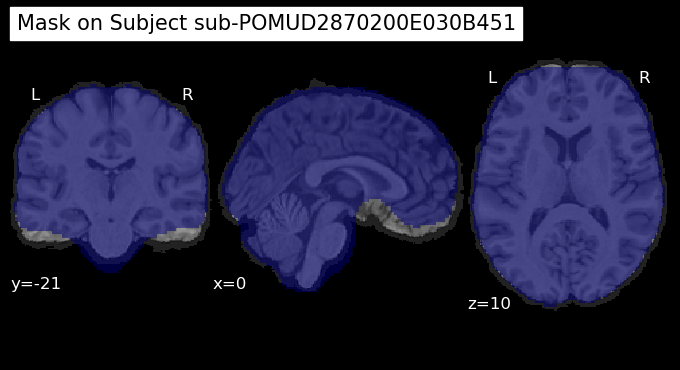

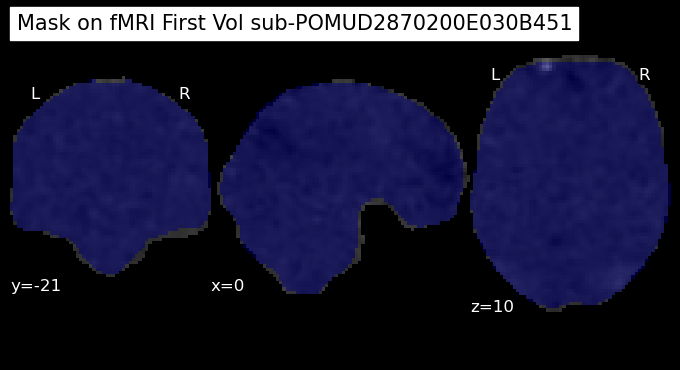

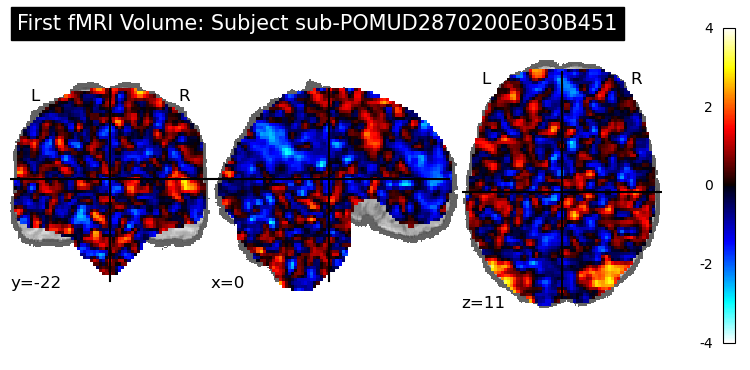

Check on Test Subjects

Visualizing QC on random subjects...


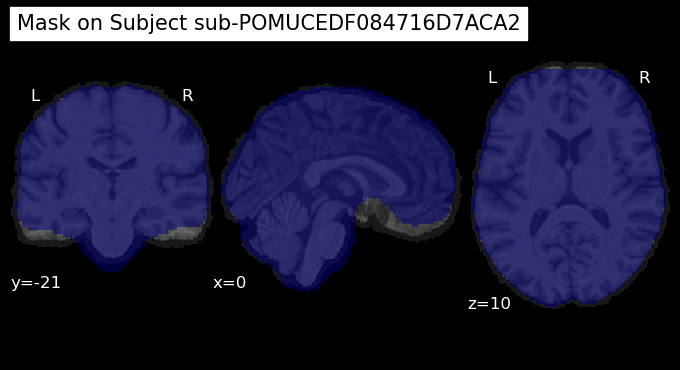

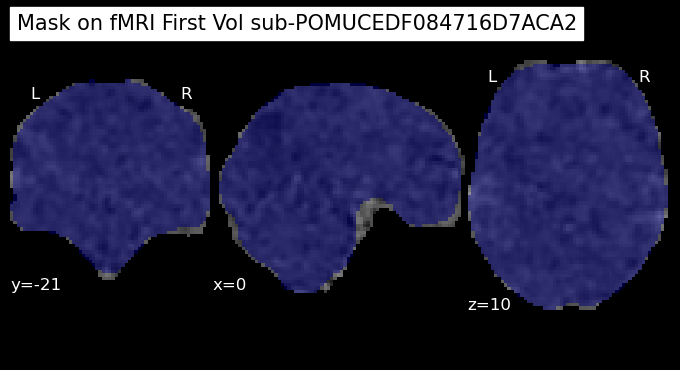

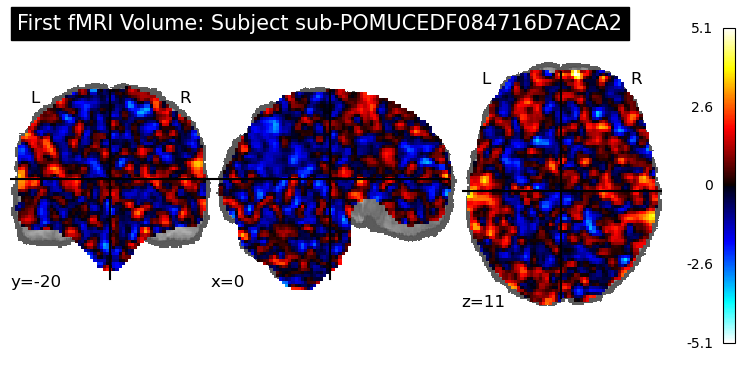


GM Mask creation and QC visualization complete!

Fold 2

Building group GM mask from training subjects for fold...
Saved group GM mask with 141453 voxels at: /project/3022057.01/POM/ParkStage/fold_1/group_gm_mask_fold.nii.gz
Check on Train Subjects

Visualizing QC on random subjects...


KeyboardInterrupt: 

In [6]:
import ast
import pickle
from sklearn.model_selection import StratifiedGroupKFold

n_folds = settings["n_folds"]
random_state = settings["random_state"]

label = settings["label"]
labels = sub_df[label].to_numpy()
np.save(os.path.join(outputfolder,"labels.npy"),labels)

sub_ID = sub_df["Subject"].to_numpy()
np.save(os.path.join(outputfolder,"Sub_ID.npy"),sub_ID)

time_points = sub_df["n_timepoints"].to_numpy()
np.save(os.path.join(outputfolder,"time_points.npy"),time_points)

func_paths = sub_df["data"].to_numpy()

skf = StratifiedGroupKFold(n_splits=n_folds, shuffle=True, random_state=random_state)
for fold, (train_idx, test_idx) in enumerate(skf.split(func_paths, labels, groups=sub_ID)):
    print(f"\nFold {fold+1}")

    fold_output_dir = os.path.join(outputfolder, f"fold_{fold}")
    if not os.path.exists(fold_output_dir):
        os.makedirs(fold_output_dir)
    indices_dir = os.path.join(fold_output_dir, "Indices")
    if not os.path.exists(indices_dir):
        os.makedirs(indices_dir)
    np.save(os.path.join(indices_dir, "train_idx.npy"), train_idx)
    np.save(os.path.join(indices_dir, "test_idx.npy"), test_idx)
   
    # Build mask and save into fold folder
    mask_path = fold_gm_mask(dataframe=sub_df, train_idx=train_idx, test_idx=test_idx, output_dir=fold_output_dir, mask_name="group_gm_mask_fold.nii.gz",n_qc_subjects=1,gm=False,threshold=.7)
    
    paths = [(func_path, mask_path) for func_path in func_paths]
    paths = np.array(paths, dtype=object)


    with open(os.path.join(fold_output_dir, "paths.pkl"), "wb") as f:
        pickle.dump(paths, f)


Functional image affine:
 [[   2.38599992    0.            0.          -90.        ]
 [   0.            2.38599992    0.         -126.        ]
 [   0.            0.            2.4000001   -72.        ]
 [   0.            0.            0.            1.        ]]
Mask image affine:
 [[   2.38599992    0.            0.          -90.        ]
 [   0.            2.38599992    0.         -126.        ]
 [   0.            0.            2.4000001   -72.        ]
 [   0.            0.            0.            1.        ]]
Atlas image affine:
 [[   3.    0.    0.  -78.]
 [   0.    3.    0. -112.]
 [   0.    0.    3.  -68.]
 [   0.    0.    0.    1.]]
Resampled Atlas affine:
 [[   2.38599992    0.            0.          -90.        ]
 [   0.            2.38599992    0.         -126.        ]
 [   0.            0.            2.4000001   -72.        ]
 [   0.            0.            0.            1.        ]]
Resampled Atlas shape: (77, 92, 76)
Functional image shape: (77, 92, 76, 800)
Mask image

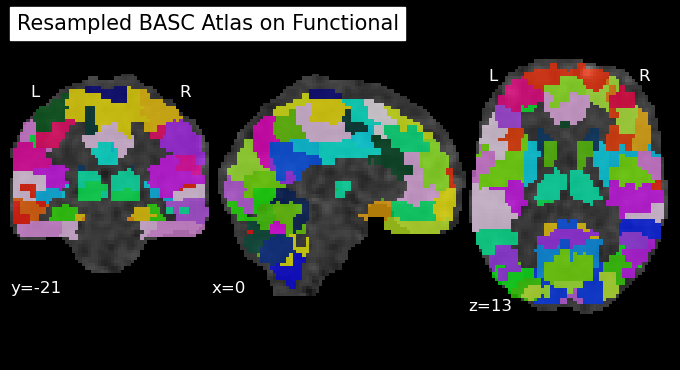

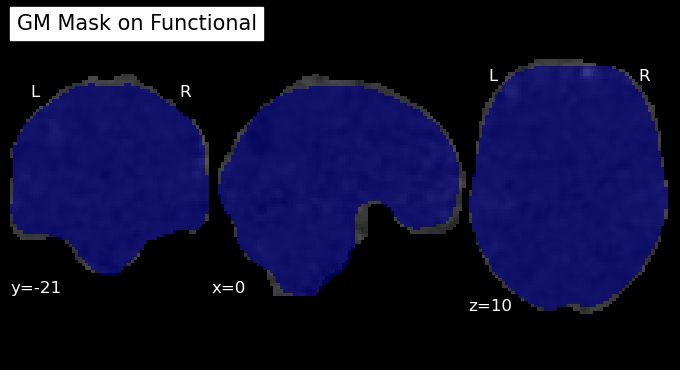

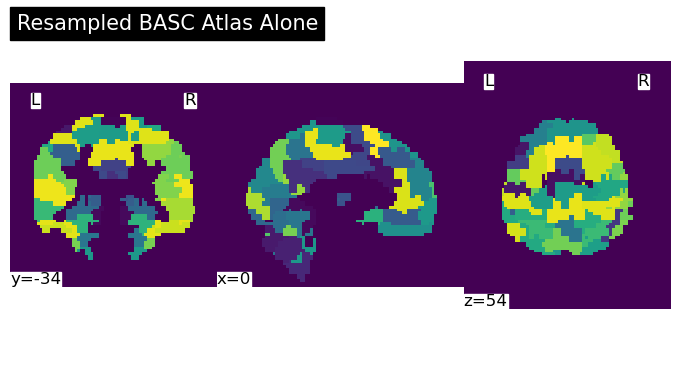

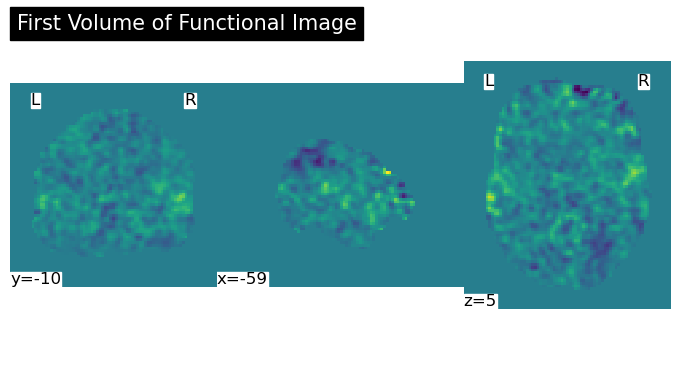

Extracted parcel-wise time series shape: (800, 122)
Reconstructed voxel-wise data shape: (77, 92, 76, 800)


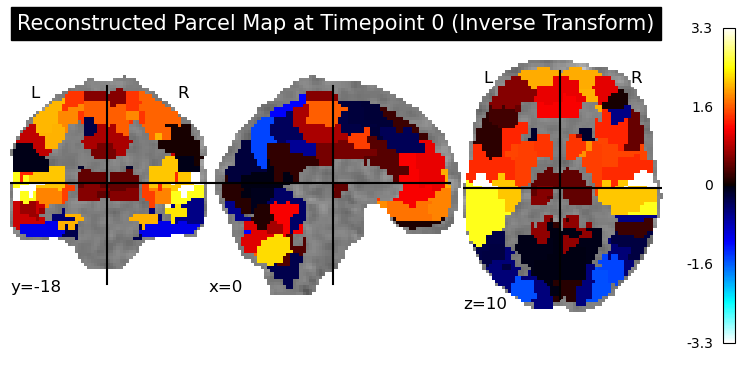

In [7]:
from nilearn.maskers import NiftiMasker, NiftiLabelsMasker
from nilearn.datasets import fetch_atlas_basc_multiscale_2015
import nibabel as nib
import numpy as np
from nilearn.image import resample_to_img
from nilearn import plotting

basc = fetch_atlas_basc_multiscale_2015(resolution=122, version='asym')
basc_labels = basc.maps

# Load your functional image and mask
func_img = nib.load(paths[0][0])
mask_img = nib.load(paths[0][1])
atlas_img = nib.load(basc_labels)

# Resample BASC atlas to match the functional image space (Native MNI)
resampled_atlas = resample_to_img(atlas_img, func_img, interpolation='nearest')

# Check affine matrices
print("Functional image affine:\n", func_img.affine)
print("Mask image affine:\n", mask_img.affine)
print("Atlas image affine:\n", atlas_img.affine)
print("Resampled Atlas affine:\n", resampled_atlas.affine)
print("Resampled Atlas shape:", resampled_atlas.shape)

# Check shapes
print("Functional image shape:", func_img.shape)
print("Mask image shape:", mask_img.shape)
print("Atlas image shape:", atlas_img.shape)

# Check voxel sizes
print("Functional voxel size:", np.abs(func_img.header.get_zooms()))
print("Mask voxel size:", np.abs(mask_img.header.get_zooms()))
print("Atlas voxel size:", np.abs(atlas_img.header.get_zooms()))

masker = NiftiLabelsMasker(labels_img=basc_labels, mask_img=mask_img, standardize='zscore_sample', dtype=np.float32,resampling_target='data')
masker.fit(func_img)

# Check the internal resampled atlas (after masker fit)
print("Masker's region_atlas_ affine:\n", masker.labels_img_.affine)
print("Masker's region_atlas_ shape:", masker.labels_img_.shape)

# Should now match func_img (2mm MNI space)
print("Functional image affine:\n", func_img.affine)
print("Functional image shape:", func_img.shape)

# Show the resampled atlas over the functional image
print("\nVisualizing resampled atlas over functional image...")
plotting.plot_roi(resampled_atlas, bg_img=func_img.slicer[:,:,:,0], title="Resampled BASC Atlas on Functional", draw_cross=False)

# Show the GM mask over the functional image
print("\nVisualizing GM mask over functional image...")
plotting.plot_roi(mask_img, bg_img=func_img.slicer[:,:,:,0], title="GM Mask on Functional", draw_cross=False)

# Show both mask and atlas separately to double-check overlays
print("\nVisualizing resampled atlas only...")
plotting.plot_img(resampled_atlas, title="Resampled BASC Atlas Alone", draw_cross=False)

print("\nVisualizing functional image alone (reference)...")
plotting.plot_img(func_img.slicer[:, :, :, 0], title="First Volume of Functional Image", draw_cross=False)

plotting.show()

# Extract time series per parcel
parcel_timeseries = masker.transform(func_img)  # shape: (n_timepoints, n_parcels)

print(f"Extracted parcel-wise time series shape: {parcel_timeseries.shape}")
# Reconstruct the voxel-wise data from the parcel time series
reconstructed_voxel_data = masker.inverse_transform(parcel_timeseries)  # Nifti1Image, 4D (X, Y, Z, T)

print(f"Reconstructed voxel-wise data shape: {reconstructed_voxel_data.shape}")
# Plot first volume of reconstructed data
plotting.plot_stat_map(reconstructed_voxel_data.slicer[:, :, :, 0], bg_img=func_img.slicer[:,:,:,0], title="Reconstructed Parcel Map at Timepoint 0 (Inverse Transform)", threshold=0.0, black_bg=False)
plotting.show()


In [ ]:
import os
import subprocess

run_fold_script = "/project/3022057.01/IFA/run_IFA/Partial/run_fold_leap.sh"

# New job per fold
for fold in range(5):
    fold_output_dir = os.path.join(outputfolder, f"fold_{fold}")

    command = [
        "sbatch",
        "--job-name", f"fold_{fold}",
        "--output", os.path.join(fold_output_dir, "slurm-%j.out"),
        "--error", os.path.join(fold_output_dir, "slurm-%j.err"),
        run_fold_script,  # Path to `run_fold.sh`
        outputfolder,     # Pass outputfolder as first argument
        str(fold),         # Pass fold as second argument
    ]
    
    # Submit the job
    subprocess.run(command)

In [2]:
import sys
import os
import json
import numpy as np
import argparse
import pickle
from pyriemann.estimation import Covariances
import traceback
from concurrent.futures import ProcessPoolExecutor
import functools
import gc
import pandas as pd
import psutil
import resource
from nilearn.maskers import NiftiMasker, NiftiLabelsMasker
from nilearn.input_data import NiftiMapsMasker
from nilearn.datasets import fetch_atlas_basc_multiscale_2015, fetch_atlas_smith_2009
basc = fetch_atlas_basc_multiscale_2015(resolution=122, version='asym')
basc_labels = basc.maps
# smith = fetch_atlas_smith_2009(dimension=70, resting=True)
# basc_labels = smith["maps"]

# Add the path to custom modules
sys.path.append('/project/3022057.01/IFA/utils')

# Import necessary modules
from analysis import evaluate, compare
from PCA import PPCA, migp
from filters import orthonormalize_filters, save_brain
from ICA import ICA
from DualRegression import DualRegress
from filters import TSSF, FKT, evaluate_filters
from tangent import tangent_classification
from haufe import partial_filter_dual_regression
from preprocessing import load_subject


# End of save block
from filters import voxelwise_FKT

def save_text_results(text, filepath):
    """Save text results to a file."""
    with open(filepath, "a") as f:  # Using 'a' to append results to the file
        f.write(text + "\n")
        
def partiallate_subject(sub, vt):
    try:
        # Load subject data using our load_subject function.
        partialled_subject = load_subject(sub)
        # Remove the projection onto vt.
        # partialled_subject = data - (data @ np.linalg.pinv(vt)) @ vt
        # del data  # free memory


        _, gm_mask_file = sub
        masker = NiftiMasker(mask_img=gm_mask_file, dtype=np.float32)
        masker.fit()

        partial_full = masker.inverse_transform(partialled_subject)
        del partialled_subject
        
        # labels_masker = NiftiMapsMasker(
        #     maps_img=basc_labels,      # your 70 ICA components
        #     standardize='zscore_sample',  # z-score each timeseries
        #     smoothing_fwhm=None,        # ← turn off any extra smoothing
        #     memory=None,                # ← disable on-disk caching
        #     verbose=0
        # )
        labels_masker = NiftiLabelsMasker(labels_img=basc_labels, mask_img=gm_mask_file, standardize='zscore_sample',  dtype=np.float32,resampling_target='data')
        Xp = labels_masker.fit_transform(partial_full)
        del partial_full
        
        # Drop first 5
        return Xp
    
    except Exception as e:
        print(f"Error processing subject {sub}: {e}")
        traceback.print_exc()
        raise

def partiallate_subjects(paths, vt, output_dir, n_workers=20):
    try:
        # Create a function that always uses the same vt.
        func = functools.partial(partiallate_subject, vt=vt)
        with ProcessPoolExecutor(max_workers=n_workers) as executor:
            # Map over the list of subject paths. Results will be in the same order.
            partiallated_data_list = list(executor.map(func, paths))
        
        # Convert the list to a NumPy array.
        data_save_path = os.path.join(output_dir, "partiallated_data.pkl")
        with open(data_save_path, "wb") as f:
            pickle.dump(partiallated_data_list, f)
        print(f"Partiallated data saved to {data_save_path}")
        
        # Compute covariances one subject at a time
        cov_est = Covariances(estimator='oas')
        partial_covs = []
        for subject_data in partiallated_data_list:
            # subject_data shape: (T, Parcels)
            cov = cov_est.transform(subject_data.T[np.newaxis, :, :])  # (1, Parcels, Parcels)
            partial_covs.append(cov[0])  # cov_est.transform returns a batch (n_matrices, n_channels, n_channels)
        
        partial_covs = np.array(partial_covs)
        covs_save_path = os.path.join(output_dir, "partiallated_covs.npy")
        np.save(covs_save_path, partial_covs)
        print(f"Covariances saved to {covs_save_path}")
        
        return partiallated_data_list, partial_covs
    except Exception as e:
        print(f"Error in parcellation process: {e}")
        traceback.print_exc()
        raise  # Re-raise the error so the process crashes.

def major_recon_discrim(discrim_basis, major_space,output_folder):
    try:
        # Compute reconstruction
        reconstructed = discrim_basis.T @ np.linalg.pinv(major_space) @ major_space
        numerator = np.linalg.norm(discrim_basis.T - reconstructed, 'fro') ** 2
        denominator = np.linalg.norm(discrim_basis.T, 'fro') ** 2
        reconstruction_percentage = (1 - numerator / denominator)
        print("Reconstruction Percentage:", reconstruction_percentage)
        
        # Save the reconstruction percentage
        recon_file = os.path.join(output_folder, "discriminant_reconstruction_percentage_vt.txt")
        with open(recon_file, "w") as f:
            f.write(str(reconstruction_percentage) + "\n")
    except Exception as e:
        print("Failed to compute reconstruction percentage:", e)
        reconstruction_percentage = None

def PPCA_ICA(reducedsubs,basis=None, n_components=None, IFA=True,random_state=42, output_folder=None):
    if not IFA:
        _, basis = PPCA(reducedsubs.copy(), threshold=0.0, niters=1, n=n_components)

    spatial_maps = ICA(basis, output_dir=output_folder,random_state=random_state)
    spatial_maps = spatial_maps.T
    for i in range(spatial_maps.shape[1]):
        save_brain(spatial_maps[:,i], f"s_map_{i}", output_folder)

    np.save(os.path.join(output_folder, "basis.npy"), basis)
    np.save(os.path.join(output_folder, "spatial_maps.npy"), spatial_maps)

    return spatial_maps

def run_comparisons(results_list, base_output_folder, pairs, alpha=0.05):
    """
    Run pairwise comparisons for a list of evaluation results.
    
    Parameters:
    - results_list: list of evaluation results (e.g., normalized or unnormalized).
    - base_output_folder: base directory where comparison subfolders will be created.
    - pairs: list of tuples (i, j, label_one, label_two) indicating the indices in results_list and their labels.
    """
    if not os.path.exists(base_output_folder):
        os.makedirs(base_output_folder)
        
    for i, j, label_one, label_two in pairs:
        pair_dir = os.path.join(base_output_folder, f"{label_one}_vs_{label_two}")
        if not os.path.exists(pair_dir):
            os.makedirs(pair_dir)
        compare(
            results_list[i], results_list[j],
            label_one=label_one, label_two=label_two,
             alpha=alpha, output_dir=pair_dir
        )

def cpu_mem():
    # Get the soft and hard limits of virtual memory (address space)
    soft, hard = resource.getrlimit(resource.RLIMIT_AS)
    print(f"Soft limit: {soft / (1024 ** 3):.2f} GB")
    print(f"Hard limit: {hard / (1024 ** 3):.2f} GB")

    # Get the soft and hard limits of the data segment (physical memory usage)
    soft, hard = resource.getrlimit(resource.RLIMIT_DATA)
    print(f"Soft limit: {soft / (1024 ** 3):.2f} GB")
    print(f"Hard limit: {hard / (1024 ** 3):.2f} GB")
   # Display memory information
    print(f"Total Memory: { psutil.virtual_memory().total / (1024**3):.2f} GB")
    print(f"Available Memory: { psutil.virtual_memory().available / (1024**3):.2f} GB")
    print(f"Used Memory: { psutil.virtual_memory().used / (1024**3):.2f} GB")
    print(f"Memory Usage: { psutil.virtual_memory().percent}%")
    

fold = 0

with open(os.path.join(outputfolder, "settings.json"), "r") as f:
    settings = json.load(f)

random_state           = settings["random_state"]
n_filters_per_group    = settings["n_filters_per_group"]
nPCA_levels            = settings["nPCA_levels"]
tangent_class          = settings["tangent_class"]
tan_class_model        = settings["tan_class_model"]
metric                 = settings["metric"]
a_label                = settings["a_label"]
b_label                = settings["b_label"]
deconf             = settings["deconfound"]
paired                 = settings["paired"]

# Load numpy files
sub_ID = np.load(os.path.join(outputfolder, "Sub_ID.npy"),
                 allow_pickle=True)
labels = np.load(os.path.join(outputfolder, "labels.npy"))
time_points = np.load(os.path.join(outputfolder, "time_points.npy"))

# Load Fold Specific Vairables
fold_output_dir = os.path.join(outputfolder, f"fold_{fold}")

with open(os.path.join(fold_output_dir, "paths.pkl"), "rb") as f:
    paths = pickle.load(f)

summary_file_path = os.path.join(fold_output_dir, "output_summary.txt")
indices_dir = os.path.join(fold_output_dir, "Indices")
train_idx = np.load(os.path.join(indices_dir, "train_idx.npy"))
test_idx = np.load(os.path.join(indices_dir, "test_idx.npy"))
fold_results = os.path.join(fold_output_dir, "Results")
if not os.path.exists(fold_results):
    os.makedirs(fold_results)

# Prepare data for train and test sets
train_labels = labels[train_idx]
train_paths = paths[train_idx]
test_labels = labels[test_idx]

if deconf:
    con_confs = pd.read_pickle(os.path.join(outputfolder, "con_confounders.pkl"))
    cat_confs = pd.read_pickle(os.path.join(outputfolder, "cat_confounders.pkl"))
    
    train_con_confounders = con_confs.iloc[train_idx]
    test_con_confounders = con_confs.iloc[test_idx]
    train_cat_confounders = cat_confs.iloc[train_idx]
    test_cat_confounders = cat_confs.iloc[test_idx]
else:
    train_con_confounders = None
    test_con_confounders = None
    train_cat_confounders = None
    test_cat_confounders = None

# Save summary of data split
save_text_results(f"Fold {fold + 1}:", summary_file_path)
save_text_results(f"  Train size: {len(train_idx)}", summary_file_path)
save_text_results(f"  Test size: {len(test_idx)}", summary_file_path)
save_text_results(f"  Train labels distribution: {np.bincount(labels[train_idx].astype(int))}", summary_file_path)
save_text_results(f"  Test labels distribution: {np.bincount(labels[test_idx].astype(int))}", summary_file_path)
common = np.intersect1d(sub_ID[train_idx], sub_ID[test_idx])
if len(common) > 0:
    raise RuntimeError(
        f"Found {len(common)} subject(s) in both train and test: {common.tolist()}"
    )

print(f" No subjects are shared between train and test for fold {fold+1}")

if paired:
    paired_train = np.array_equal(
        sub_ID[train_idx][train_labels == a_label],
        sub_ID[train_idx][train_labels == b_label]
    )
    paired_test = np.array_equal(
        sub_ID[test_idx][test_labels == a_label],
        sub_ID[test_idx][test_labels == b_label]
    )
    save_text_results(f"  Paired Across Train: {paired_train}", summary_file_path)
    save_text_results(f"  Paired Across Test: {paired_test}", summary_file_path)
    
# Run MIGP
migp_dir = os.path.join(fold_output_dir, "MIGP")
if not os.path.exists(migp_dir):
    os.makedirs(migp_dir)

# reduced_subs_path = os.path.join(migp_dir, "reducedsubs.npy")
# mA = 2 * time_points[train_idx][train_labels == a_label].max()
# mB = 2 * time_points[train_idx][train_labels == b_label].max()
# if os.path.exists(reduced_subs_path):
#     print(f"Loading existing reducedsubs from {reduced_subs_path}")
#     reducedsubs = np.load(reduced_subs_path)
# else:
#     print("Reducedsubs not found — running MIGP")
#     reducedsubsA = migp(train_paths[train_labels == a_label], m=mA, n_jobs=15,batch_size=1)
#     np.save(os.path.join(migp_dir, "reducedsubsA.npy"), reducedsubsA)

#     reducedsubsB = migp(train_paths[train_labels == b_label], m=mB, n_jobs=15,batch_size=1)
#     np.save(os.path.join(migp_dir, "reducedsubsB.npy"), reducedsubsB)

#     reducedsubs = np.concatenate((reducedsubsA, reducedsubsB), axis=0)
#     np.save(reduced_subs_path, reducedsubs)
#     del reducedsubsA, reducedsubsB
#     gc.collect()

reduced_subs_path = os.path.join(migp_dir, "reducedsubs.npy")
m = 2 * time_points[train_idx].max()

# if os.path.exists(reduced_subs_path):
#     print(f"Loading existing reducedsubs from {reduced_subs_path}")
#     reducedsubs = np.load(reduced_subs_path)
# else:
#     print("Reducedsubs not found — running MIGP on all training subjects")
#     reducedsubs = migp(train_paths, m=m, n_jobs=20, batch_size=1)
#     np.save(reduced_subs_path, reducedsubs)
#     gc.collect()


nPCA = nPCA_levels[0]
# Directory for resulst for basis spanned by nPCA components + fixed number of filters
nPCA_dir = os.path.join(fold_output_dir, f"nPCA_{nPCA}")
if not os.path.exists(nPCA_dir):
    os.makedirs(nPCA_dir)

# Get Parcellated Filters
filters_dir = os.path.join(nPCA_dir, "Filters")
if not os.path.exists(filters_dir):
    os.makedirs(filters_dir)

# vt_path = os.path.join(filters_dir, "vt.npy")
# if os.path.exists(vt_path):
#     print("Loading existing vt.npy...")
#     vt = np.load(vt_path).astype(np.float32)
# else:
#     print("vt.npy not found, running PPCA...")
#     _, vt = PPCA(reducedsubs.copy(), threshold=0.0, niters=1, n=nPCA)
#     np.save(vt_path, vt)

# Run the PCA job, now just to get the voxel level filters using GPU
voxel_filters_dir = os.path.join(filters_dir, "Voxel")
if not os.path.exists(voxel_filters_dir):
    os.makedirs(voxel_filters_dir)
        

 No subjects are shared between train and test for fold 1


In [3]:
def memory_profile():
    """Prints current RAM usage, peak RAM usage, and SLURM-allocated memory."""
    # Read /proc/self/status
    # https://hpcf.umbc.edu/general-productivity/checking-memory-usage/
    status = {}
    with open("/proc/self/status", "r") as f:
        for line in f:
            parts = line.strip().split(":")
            if len(parts) == 2:
                key, value = parts
                status[key] = value.strip()

    # Memory usage
    ram_current_gb = int(status.get("VmRSS", "0").split()[0]) / 1e6
    ram_peak_gb = int(status.get("VmPeak", "0").split()[0]) / 1e6

    # SLURM allocation
    slurm_mem_gb = None
    if "SLURM_MEM_PER_NODE" in os.environ:
        slurm_mem_gb = int(os.environ["SLURM_MEM_PER_NODE"]) / 1024
    elif "SLURM_MEM_PER_CPU" in os.environ:
        ncpus = int(os.environ.get("SLURM_CPUS_ON_NODE", 1))
        slurm_mem_gb = (int(os.environ["SLURM_MEM_PER_CPU"]) * ncpus) / 1024

    # Print results
    print("[Memory Profile]")
    print(f"  Current RAM used (VmRSS): {ram_current_gb:.2f} GB")
    print(f"  Peak RAM used   (VmPeak): {ram_peak_gb:.2f} GB")
    if slurm_mem_gb is not None:
        print(f"  SLURM Allocated Memory:   {slurm_mem_gb:.2f} GB")
    else:
        print("  SLURM Allocated Memory:   Unknown (not running under SLURM)")

import threading
import time
import os

def read_memory_status():
    """Return current RAM, peak RAM from /proc/self/status."""
    status = {}
    with open("/proc/self/status", "r") as f:
        for line in f:
            parts = line.strip().split(":")
            if len(parts) == 2:
                key, value = parts
                status[key] = value.strip()

    ram_current_gb = int(status.get("VmRSS", "0").split()[0]) / 1e6
    ram_peak_gb = int(status.get("VmPeak", "0").split()[0]) / 1e6
    return ram_current_gb, ram_peak_gb

def get_slurm_memory_allocated():
    """Return memory allocated by SLURM."""
    slurm_mem_gb = None
    if "SLURM_MEM_PER_NODE" in os.environ:
        slurm_mem_gb = int(os.environ["SLURM_MEM_PER_NODE"]) / 1024
    elif "SLURM_MEM_PER_CPU" in os.environ:
        ncpus = int(os.environ.get("SLURM_CPUS_ON_NODE", 1))
        slurm_mem_gb = (int(os.environ["SLURM_MEM_PER_CPU"]) * ncpus) / 1024
    return slurm_mem_gb

def monitor_memory(interval=60, output_file="memory_log.csv", stop_event=None):
    """Monitor memory usage every `interval` seconds, save to CSV."""
    if not os.path.exists(output_file):
        with open(output_file, "w") as f:
            f.write("timestamp,current_ram_gb,peak_ram_gb,slurm_allocated_gb\n")

    slurm_alloc = get_slurm_memory_allocated()

    while not (stop_event and stop_event.is_set()):
        now = time.strftime("%Y-%m-%d %H:%M:%S")
        ram_current, ram_peak = read_memory_status()

        slurm_alloc_value = slurm_alloc if slurm_alloc else 0.0

        with open(output_file, "a") as f:
            f.write(f"{now},{ram_current:.2f},{ram_peak:.2f},{slurm_alloc_value:.2f}\n")
            f.flush()

        print(f"[{now}] Current RAM: {ram_current:.2f} GB | Peak RAM: {ram_peak:.2f} GB")
        time.sleep(interval)



def run_pca(outputfolder, voxel_filters_dir, train_paths, train_labels, a_label, b_label, mA, mB, batch_size=5):
    try:
        with open(os.path.join(outputfolder, "settings.json"), "r") as f:
            settings = json.load(f)
        

        n_filters_per_group = settings["n_filters_per_group"]
        cov_log = settings["cov_log"]
        shrink = settings["shrinkage"]
        filters_dir = os.path.dirname(voxel_filters_dir)
        vt = np.load(os.path.join(filters_dir, "vt.npy"))
        
        A_path = os.path.join(voxel_filters_dir, "A_partial.npy")
        if os.path.exists(A_path):
            A_partial = np.load(A_path).astype(np.float32) 
            print(f"Loaded existing A_partial from {A_path}")
        else:
            A_partial = migp(train_paths[train_labels == a_label], m=mA, n_jobs=15,batch_size=batch_size,vt=vt)
            A_partial = A_partial.astype(np.float32) 
            np.save(A_path, A_partial)

        B_path = os.path.join(voxel_filters_dir, "B_partial.npy")
        if os.path.exists(B_path):
            B_partial = np.load(B_path).astype(np.float32) 
            print(f"Loaded existing B_partial from {B_path}")
        else:
            B_partial = migp(train_paths[train_labels == b_label], m=mB, n_jobs=15,batch_size=batch_size,vt=vt)
            B_partial = B_partial.astype(np.float32)
            np.save(B_path, B_partial)

        voxelwise_FKT(groupA=A_partial, groupB=B_partial, 
                        n_filters_per_group=n_filters_per_group, 
                        groupA_paths=None, groupB_paths=None, 
                        paths=False,log=cov_log,shrinkage=shrink,
                        cov_method='svd',outputfolder=voxel_filters_dir, save=False, save_img=False)

    except Exception as e:
        print(f"Error in run_pca: {e}", flush=True)
        import traceback
        traceback.print_exc()
        # Exit with non-zero code so SLURM knows the job failed
        sys.exit(1)


# stop_event = threading.Event()
# monitor_thread = threading.Thread(target=monitor_memory, kwargs={"interval": 30, "stop_event": stop_event})
# monitor_thread.start()
# try:
#     # ======= Your real script code below here =======
#     print("Running heavy computation...")

#     run_pca(outputfolder, voxel_filters_dir, train_paths, train_labels, a_label, b_label, mA, mB, batch_size=1)

# finally:
#     # Signal the memory monitor to stop
#     stop_event.set()
#     monitor_thread.join()
#     print("Memory monitoring stopped.")

# memory_profile()
        

# Paths where we'll cache the results
data_save_path = os.path.join(filters_dir, "partiallated_data.pkl")
covs_save_path = os.path.join(filters_dir, "partiallated_covs.npy")

# Try to load cached results, otherwise compute and save
if os.path.exists(data_save_path) and os.path.exists(covs_save_path):
    # Load previously saved data
    with open(data_save_path, "rb") as f:
        partial_data = pickle.load(f)
    partial_covs = np.load(covs_save_path)
    print(f"Loaded partiallated data from {data_save_path}")
    print(f"Loaded covariances from {covs_save_path}")
else:
    vt = None
    partial_data, partial_covs = partiallate_subjects(paths, vt, output_dir=filters_dir, n_workers=20)

# Then split into train and test using your indices:
partial_train_data = [partial_data[i] for i in train_idx]
partial_test_data  = [partial_data[i] for i in test_idx]

partial_train_covs = partial_covs[train_idx]
partial_test_covs  = partial_covs[test_idx]


Loaded partiallated data from /project/3022057.01/POM/ParkStage/fold_0/nPCA_8/Filters/partiallated_data.pkl
Loaded covariances from /project/3022057.01/POM/ParkStage/fold_0/nPCA_8/Filters/partiallated_covs.npy


In [ ]:
# Then split into train and test using your indices:

def save_text_results(text, filepath):
    """Save text results to a file."""
    with open(filepath, "a") as f:  # Using 'a' to append results to the file
        f.write(text + "\n")
        

fold = 0

with open(os.path.join(outputfolder, "settings.json"), "r") as f:
    settings = json.load(f)

random_state           = settings["random_state"]
n_filters_per_group    = settings["n_filters_per_group"]
nPCA_levels            = settings["nPCA_levels"]
tangent_class          = settings["tangent_class"]
tan_class_model        = settings["tan_class_model"]
metric                 = settings["metric"]
a_label                = settings["a_label"]
b_label                = settings["b_label"]
deconfound             = settings["deconfound"]
paired                 = settings["paired"]

# Load numpy files
sub_ID = np.load(os.path.join(outputfolder, "Sub_ID.npy"),
                 allow_pickle=True)
labels = np.load(os.path.join(outputfolder, "labels.npy"))
time_points = np.load(os.path.join(outputfolder, "time_points.npy"))

# Load Fold Specific Vairables
fold_output_dir = os.path.join(outputfolder, f"fold_{fold}")

with open(os.path.join(fold_output_dir, "paths.pkl"), "rb") as f:
    paths = pickle.load(f)

summary_file_path = os.path.join(fold_output_dir, "output_summary.txt")
indices_dir = os.path.join(fold_output_dir, "Indices")
train_idx = np.load(os.path.join(indices_dir, "train_idx.npy"))
test_idx = np.load(os.path.join(indices_dir, "test_idx.npy"))
fold_results = os.path.join(fold_output_dir, "Results")
if not os.path.exists(fold_results):
    os.makedirs(fold_results)

# Prepare data for train and test sets
train_labels = labels[train_idx]
train_paths = paths[train_idx]
test_labels = labels[test_idx]

if deconfound:
    con_confs = pd.read_pickle(os.path.join(outputfolder, "con_confounders.pkl"))
    cat_confs = pd.read_pickle(os.path.join(outputfolder, "cat_confounders.pkl"))
    
    train_con_confounders = con_confs.iloc[train_idx]
    test_con_confounders = con_confs.iloc[test_idx]
    train_cat_confounders = cat_confs.iloc[train_idx]
    test_cat_confounders = cat_confs.iloc[test_idx]
else:
    train_con_confounders = None
    test_con_confounders = None
    train_cat_confounders = None
    test_cat_confounders = None

# Save summary of data split
save_text_results(f"Fold {fold + 1}:", summary_file_path)
save_text_results(f"  Train size: {len(train_idx)}", summary_file_path)
save_text_results(f"  Test size: {len(test_idx)}", summary_file_path)
save_text_results(f"  Train labels distribution: {np.bincount(labels[train_idx].astype(int))}", summary_file_path)
save_text_results(f"  Test labels distribution: {np.bincount(labels[test_idx].astype(int))}", summary_file_path)
common = np.intersect1d(sub_ID[train_idx], sub_ID[test_idx])
if len(common) > 0:
    raise RuntimeError(
        f"Found {len(common)} subject(s) in both train and test: {common.tolist()}"
    )


nPCA = nPCA_levels[0]
# Directory for resulst for basis spanned by nPCA components + fixed number of filters
nPCA_dir = os.path.join(fold_output_dir, f"nPCA_{nPCA}")
if not os.path.exists(nPCA_dir):
    os.makedirs(nPCA_dir)

# Get Parcellated Filters
filters_dir = os.path.join(nPCA_dir, "Filters")
if not os.path.exists(filters_dir):
    os.makedirs(filters_dir)


# Paths where we'll cache the results
data_save_path = os.path.join("/project/3022057.01/ParkStage/fold_0/nPCA_8/Filters/partiallated_data.pkl")
covs_save_path = os.path.join("/project/3022057.01/ParkStage/fold_0/nPCA_8/Filters/partiallated_covs.npy")

# Try to load cached results, otherwise compute and save
if os.path.exists(data_save_path) and os.path.exists(covs_save_path):
    # Load previously saved data
    with open(data_save_path, "rb") as f:
        partial_data = pickle.load(f)
    partial_covs = np.load(covs_save_path)
    print(f"Loaded partiallated data from {data_save_path}")
    print(f"Loaded covariances from {covs_save_path}")
    

partial_train_data = [partial_data[i] for i in train_idx]
partial_test_data  = [partial_data[i] for i in test_idx]

partial_train_covs = partial_covs[train_idx]
partial_test_covs  = partial_covs[test_idx]

In [ ]:
import os
os.environ["LD_PRELOAD"] = os.path.join(os.environ["CONDA_PREFIX"], "lib", "libstdc++.so.6")

import sys
import pandas as pd
from itertools import product

import numpy as np
from scipy import stats
import statsmodels.api as sm

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns


from skopt import gp_minimize
from skopt.space import Real, Integer

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold, LeaveOneOut
from sklearn.svm import LinearSVC, OneClassSVM
from sklearn.linear_model import LogisticRegression, ElasticNet, Ridge, LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, r2_score, make_scorer, f1_score, mean_squared_error
from sklearn.cross_decomposition import PLSRegression, CCA, PLSCanonical
from sklearn.decomposition import DictionaryLearning, PCA, SparsePCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils import resample

from pyriemann.utils.tangentspace import  unupper
from pyriemann.estimation import Covariances

from scipy.linalg import eigh
from scipy.stats import zscore

from joblib import Parallel, delayed


from collections import Counter

import sys
sys.path.append('/project/3022057.01/IFA/utils')

import regression
import tangent
from importlib import reload

# after editing regression.py:
reload(regression)
reload(tangent)

# now pull in your updated functions
from regression import deconfound
from tangent    import tangent_transform


def sliding_window_transformation(data, window=20, overlap_perc=0.1, tr=2.3):
    """
    Compute OAS-regularized covariance matrices over sliding windows of fMRI time series.

    Parameters:
        data           : list of arrays of shape (T, Parcels), one per subject
        XwindowX         : window size in seconds (default = 20s)
        window : in samples
        overlap_perc   : percent overlap between windows (default = 10%)
        tr             : TR in seconds (default = 2.3s)

    Returns:
        all_subject_covs : list of arrays, each of shape (n_windows, Parcels, Parcels)
    """
    # window_size = int(round(window / tr))  # e.g., 20s / 2.3s = 9 TRs
    # stride = int(round((window * (1 - overlap_perc))/tr))  # e.g., 10% overlap → stride = 1 TR
    
    # Window in samples
    window_size = int(window)
    stride = max(1, int(round(window_size * (1 - overlap_perc))))

    cov_est = Covariances(estimator='oas')
    all_subject_covs = []

    for subject_data in data:
        T, P = subject_data.shape
        # print(T,window_size)
        # print(T)
        # print(stride)
        subject_covs = []
        for start in range(0, T - window_size + 1, stride):
            window_data = subject_data[start:start + window_size, :]
            # print(np.array(window_data.shape))
            cov = cov_est.transform(window_data.T[np.newaxis, :, :])  # (1, Parcels, Parcels)
            subject_covs.append(cov[0])
        # print(np.array(subject_covs).shape)
        all_subject_covs.append(np.array(subject_covs))

    return all_subject_covs


def balance_windows(
    cov_list,
    labels=None,
    con_confounders=None,
    cat_confounders=None,
    random_state=42,
    method='undersample',
    targets=None
):
    """
    Balance a list of windowed covariance matrices, preserving confounder alignment.
    For classification (labels not None), under- or oversamples so each class has equal windows.
    For regression (labels is None, targets provided), just concatenates all windows and replicates targets/confounders.
    Returns: X_balanced, y_balanced, con_confounders_balanced, cat_confounders_balanced
    """
    rng = np.random.RandomState(random_state)

    # 1) Count windows per subject
    subject_window_counts = [arr.shape[0] for arr in cov_list]

    # 2) Concatenate all covariance windows into X
    X = np.concatenate(cov_list, axis=0)

    # 3) Prepare replicated confounders if given
    if con_confounders is not None:
        con_confounders_rep = con_confounders.loc[con_confounders.index.repeat(subject_window_counts)].reset_index(drop=True)
    else:
        con_confounders_rep = None

    if cat_confounders is not None:
        cat_confounders_rep = cat_confounders.loc[cat_confounders.index.repeat(subject_window_counts)].reset_index(drop=True)
    else:
        cat_confounders_rep = None

    # 4) Initialize outputs to None
    X_balanced = None
    y_balanced = None
    con_confounders_balanced = None
    cat_confounders_balanced = None

    # ----- classification branch -----
    if labels is not None:
        # 4a) Repeat labels per window
        y = np.repeat(labels, subject_window_counts)
        classes, counts = np.unique(y, return_counts=True)

        # 5a) Decide how many windows per class
        if method == 'undersample':
            target_n, replace = counts.min(), False
        elif method == 'oversample':
            target_n, replace = counts.max(), True
        else:
            raise ValueError("method must be 'undersample' or 'oversample'")

        # 6a) Sample indices for each class
        idxs_list = []
        for cls in classes:
            cls_idxs = np.where(y == cls)[0]
            sampled = resample(cls_idxs, replace=replace, n_samples=target_n, random_state=rng)
            idxs_list.append(sampled)

        idxs = np.hstack(idxs_list)
        rng.shuffle(idxs)

        # 7a) Build balanced outputs
        X_balanced = X[idxs]
        y_balanced = y[idxs]

        if con_confounders_rep is not None:
            con_confounders_balanced = con_confounders_rep.iloc[idxs].reset_index(drop=True)

        if cat_confounders_rep is not None:
            cat_confounders_balanced = cat_confounders_rep.iloc[idxs].reset_index(drop=True)

        # 8a) Optional logging
        print("Before balancing:")
        for cls, cnt in zip(classes, counts):
            print(f"  class {cls}: {cnt} windows")
        print("After balancing:")
        for cls in classes:
            print(f"  class {cls}: {np.sum(y_balanced == cls)} windows")

    # ----- regression branch -----
    else:
        if targets is None:
            raise ValueError("For regression you must supply `targets` (continuous).")
        # 4b) Repeat targets per window
        y_balanced = targets.loc[targets.index.repeat(subject_window_counts)].reset_index(drop=True)

        # 5b) In regression, keep every window
        X_balanced = X

        # 6b) Confounders (if any) are already repeated
        if con_confounders_rep is not None:
            con_confounders_balanced = con_confounders_rep.reset_index(drop=True)

        if cat_confounders_rep is not None:
            cat_confounders_balanced = cat_confounders_rep.reset_index(drop=True)

    return X_balanced, y_balanced, con_confounders_balanced, cat_confounders_balanced


class TSSF_full(BaseEstimator, ClassifierMixin):
    def __init__(self, clf_1, clf_2, n_fil, metric="riemann", cov_reg="oas", plot=False):
        self.clf_1 = clf_1     
        self.clf_2 = clf_2
        self.n_fil = n_fil
        self.metric = metric
        self.cov_reg = cov_reg
        self.train_labels = None
        self.subspace = None
        self.train_red_cov = None
        self.red_tan_vec = None
        self.con_conf = None
        self.cat_conf = None
        self.plot = plot

    def site_transport(self, test_red_cov=None):
            
        if test_red_cov is not None:
            X_train, X_test, _ = tangent_transform(self.train_red_cov, test_red_cov, metric=self.metric)
        else:
            X_train, _ = tangent_transform(self.train_red_cov, test=None, metric=self.metric)
                
        if test_red_cov is not None:
            return X_test 
        
        return  X_train
            
    def project(self,data):
        if isinstance(self.subspace, list):
            # stack the per-class subspaces back into a 2D array
            proj_space = np.hstack(self.subspace)   # shape: (p, n_fil*#classes)
        else:
            proj_space = self.subspace                 # shape: (p, n_fil)

        data_transformed = [subj @ proj_space for subj in data]
        # Compute covariances one subject at a time
        cov_est = Covariances(estimator=self.cov_reg)
        red_cov = np.array([ cov_est.transform(subj.T[np.newaxis, :, :])[0] for subj in data_transformed ],dtype=float)
        return red_cov
    
    def _plot_spectrum(self, eigs, riem_eigs, subset):
        """
        Plot raw eigenvalues, squared eigenvalues, and sorted spectrum
        with the top-n_fil highlighted in red/blue.
        """

        sorted_idx  = np.argsort(riem_eigs)
        sorted_vals = riem_eigs[sorted_idx]
        # map chosen original indices → sorted positions
        highlight_pos = [np.where(sorted_idx == idx)[0][0] for idx in subset]
        colors        = ['red' if eigs[idx] < 0 else 'blue' for idx in subset]

        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
        # 1) raw
        ax1.scatter(np.arange(len(eigs)), eigs, edgecolor='k', s=20)
        ax1.set(title="Raw eigenvalues", xlabel="Component", ylabel="Eigenvalue")
        # 2) squared
        ax2.scatter(np.arange(len(riem_eigs)), riem_eigs, edgecolor='k', s=20)
        ax2.set(title="Squared eigenvalues", xlabel="Component")
        # 3) sorted + highlights
        ax3.scatter(np.arange(len(sorted_vals)), sorted_vals, edgecolor='k', s=20, alpha=0.6)
        ax3.scatter(highlight_pos, sorted_vals[highlight_pos], color=colors, s=25,
                    label=f"top {len(subset)}")
        ax3.set(title="Sorted eigenvalues", xlabel="Sorted index")
        ax3.legend(loc='best')

        plt.tight_layout(pad=2.0)
        plt.show()

    def fit(self, tan_covs, labels, data, deconf=True, con_confounder_train=None, cat_confounder_train=None):
        self.train_labels = labels
        self.clf_1.fit(tan_covs, labels)
        coef = np.atleast_2d(self.clf_1.coef_)
        if coef.shape[1] != tan_covs.shape[1]:
            coef = coef.T

        if coef.shape[0] == 1 or not isinstance(self.n_fil, list):
            coef /= np.linalg.norm(coef, axis=1, keepdims=True) + 1e-12  # row-unit-norm
            coef = coef.sum(axis=0, keepdims=True)   
            boundary_matrix = unupper(coef)[0,:,:]
            eigs, filters  = eigh(boundary_matrix)
            riem_eigs = eigs**2
            subset = np.argsort(riem_eigs)[-self.n_fil:]
            self.subspace = filters[:,subset]
            if self.plot:
                self._plot_spectrum(eigs, riem_eigs, subset)
        else:
            self.subspace = []
            for i in range(coef.shape[0]):
                boundary_matrix = unupper(coef[i:i+1,:])[0,:,:]
                eigs, filters  = eigh(boundary_matrix)
                riem_eigs = eigs**2
                # Eigs not riemeigs since positive class refers to the one (rest is covered by their own filters per class)
                # subset = np.argsort(-eigs)[-self.n_fil[i]:]
                # subset = np.argsort(eigs)[-self.n_fil[i]:]
                subset = np.argsort(riem_eigs)[-self.n_fil[i]:]
                self.subspace.append(filters[:,subset])

                if self.plot:
                    self._plot_spectrum(eigs, riem_eigs, subset)


        self.train_red_cov = self.project(data)
        self.red_tan_vec = self.site_transport()
        self.con_conf = con_confounder_train
        self.cat_conf = cat_confounder_train

        if deconf:
            X_train = deconfound(
                self.red_tan_vec, self.con_conf, self.cat_conf,
                X_test=None,
                con_confounder_test=None,
                cat_confounder_test=None
            )
        else:
            X_train = self.red_tan_vec

        
        self.clf_2.fit(X_train, self.train_labels)

        return self

    def predict(self, test_data, deconf=True, 
                con_confounder_test=None, cat_confounder_test=None):
        
        test_red_cov = self.project(test_data)
        X_test = self.site_transport(test_red_cov)
        # n_dropped = len(site_mask) - np.sum(site_mask)
        # if n_dropped > 0:
        #     print(f"[INFO] Dropped {n_dropped} test samples due to unseen site(s)")

        if deconf:
            # cat_confounder_train = cat_confounder_train.drop(columns=["t1_site"])
            # cat_confounder_test = cat_confounder_test.drop(columns=["t1_site"])

            # if cat_confounder_train["sex"].nunique() == 1:
            #     cat_confounder_train = cat_confounder_train.drop(columns=["sex"])
            #     cat_confounder_test = cat_confounder_test.drop(columns=["sex"])
            # Drop invalid rows (where no tangent projection was possible)
            _, X_test = deconfound(
                self.red_tan_vec, self.con_conf, self.cat_conf,
                X_test=X_test,
                con_confounder_test=con_confounder_test,
                cat_confounder_test=cat_confounder_test
            )
        

        return self.clf_2.predict(X_test)




def severity(train_targ, test_targ, y_train, y_test, con_train, con_test, cat_train, cat_test, deconf=False, outputfolder=None, eps=1e-1, tf=0):
    feature_cols = train_targ.columns
    # 1) raw→numpy
    X_train = train_targ.values.astype(float)
    X_test  = test_targ.values.astype(float)

    # 2) standard‐scale
    scaler = StandardScaler().fit(X_train)
    X_train = scaler.transform(X_train)
    X_test  = scaler.transform(X_test)

    # 3) optional deconfounding on the *scaled* data
    if deconf:
        # label_con_train = con_train.drop(columns=["motion"])
        # label_con_test  = con_test .drop(columns=["motion"])
        # Pass in X_train/X_test here, not train_targ/test_targ
        X_train, X_test = deconfound(
            X_train, con_train, cat_train,
            X_test=X_test,
            con_confounder_test=con_test,
            cat_confounder_test=cat_test,
            output_path=os.path.join(outputfolder, "betas_fold0")
        )
        # deconfound may return DataFrames
        X_train = np.asarray(X_train, dtype=float)
        X_test  = np.asarray(X_test,  dtype=float)

    
    # optional scaling or logit
    if tf == 1:
        scaler = MinMaxScaler().fit(X_train)
        X_train, X_test = scaler.transform(X_train), scaler.transform(X_test)
    elif tf == 2:
        scaler = MinMaxScaler().fit(X_train)
        def logit_transform(arr):
            p = np.clip(scaler.transform(arr), eps, 1-eps)
            return np.log(p/(1-p))
        X_train, X_test = logit_transform(X_train), logit_transform(X_test)


    # fit
    pca = PCA(2).fit(X_train)
    lda = LinearDiscriminantAnalysis().fit(X_train, y_train)
    qda = QuadraticDiscriminantAnalysis().fit(X_train, y_train)

    # get 1D scores
    scores = {
        "PCA1": (pca.transform(X_train)[:,0], pca.transform(X_test)[:,0]),
        "PCA2": (pca.transform(X_train)[:,1], pca.transform(X_test)[:,1]),
        "LDA":  (lda.decision_function(X_train),   lda.decision_function(X_test)),
        "QDA":  (qda.decision_function(X_train),   qda.decision_function(X_test)),
    }
    # boundaries from train
    bounds = {k: np.median(train_scores) for k,(train_scores,_) in scores.items()}

    # helper for strip
    def plot_strip(ax, arr, boundary, y, title):
        jit = (np.random.rand(len(arr))-.5)*.02
        ax.scatter(arr, jit, c=y, cmap="coolwarm", edgecolor="k", alpha=0.6, s=30)
        ax.axvline(boundary, color="k", linestyle="--", lw=1.5)
        ax.set_yticks([])
        ax.set_ylabel(title)
        preds = (arr>boundary).astype(int)
        return accuracy_score(y, preds)

    # 2×4 grid
    fig, axes = plt.subplots(4,2, figsize=(10,12), sharex=False)
    for row,(name,(train_s, test_s)) in enumerate(scores.items()):
        if "PCA" not in name:
            b = 0
        else:
            b = bounds[name]
        acc_tr = plot_strip(axes[row,0], train_s, b, y_train, name+" (train)")
        acc_te = plot_strip(axes[row,1], test_s,  b, y_test,  name+" (test)")
        axes[row,0].text(.95,.8,f"Acc {acc_tr:.2f}", transform=axes[row,0].transAxes,
                         ha="right",va="center",bbox=dict(boxstyle="round",fc="w",ec=".5"))
        axes[row,1].text(.95,.8,f"Acc {acc_te:.2f}", transform=axes[row,1].transAxes,
                         ha="right",va="center",bbox=dict(boxstyle="round",fc="w",ec=".5"))
        for c in (0,1):
            axes[row,c].spines['top'].set_visible(False)
            axes[row,c].spines['right'].set_visible(False)
            axes[row,c].grid(False)
    axes[-1,0].set_xlabel("Projection value")
    axes[-1,1].set_xlabel("Projection value")
    plt.tight_layout()
    plt.show()

    # 2D decision on TEST only
    if X_test.shape[1] == 2:
        acc_lda = lda.score(X_test,y_test)
        acc_qda = qda.score(X_test,y_test)
        xx,yy = np.meshgrid(
            np.linspace(X_test[:,0].min()-1,X_test[:,0].max()+1,300),
            np.linspace(X_test[:,1].min()-1,X_test[:,1].max()+1,300))
        grid = np.c_[xx.ravel(),yy.ravel()]
        Z_lda = lda.predict(grid).reshape(xx.shape)
        Z_qda = qda.predict(grid).reshape(xx.shape)
        cmap0 = ListedColormap(['#66c2a5','#fc8d62'])

        fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,5),sharex=True,sharey=True)
        ax1.contourf(xx,yy,Z_lda,alpha=.2,cmap=cmap0)
        ax1.scatter(X_test[:,0],X_test[:,1],c=y_test,cmap='coolwarm',edgecolor='k',s=40)
        ax1.set_title(f"LDA (acc={acc_lda:.2f})"); ax1.set_xlabel(feature_cols[0]); ax1.set_ylabel(feature_cols[1])
        ax2.contourf(xx,yy,Z_qda,alpha=.2,cmap=cmap0)
        ax2.scatter(X_test[:,0],X_test[:,1],c=y_test,cmap='coolwarm',edgecolor='k',s=40)
        ax2.set_title(f"QDA (acc={acc_qda:.2f})"); ax2.set_xlabel(feature_cols[0])
        for ax in (ax1,ax2):
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.grid(False)
        plt.tight_layout()
        plt.show()

    train_scores = lda.decision_function(X_train)
    test_scores  = lda.decision_function(X_test)
    
    train_df = pd.DataFrame(
        {'decision_score': train_scores},
        index=train_targ.index
    )
    test_df = pd.DataFrame(
        {'decision_score': test_scores},
        index=test_targ.index
    )

    return train_df, test_df

def preprocess(covs_train, y_train, covs_test,  y_test,  data_train, data_test,  
                       con_confounder_train, cat_confounder_train, con_confounder_test,  cat_confounder_test, 
                       sex_filter=None, age_range=None,  label_filter=None):
    """
    0) label_filter: keep only samples whose labels are in label_filter
    1) sex_filter: keep only samples of a given sex
    3) per-site tangent_transform
    4) optional deconfound
    5) returns X_train, X_test and updated y/confounders
    """
    # --- 0) label filtering ---
    # --- 0) label filtering & (optional) combining ---
    if label_filter is not None:
        # label_filter can be None, or e.g.
        #   [0,1,3]
        #   [[0,1],2,3]
        #   [[0,1],3]
        groups = label_filter if isinstance(label_filter, (list,tuple)) else [label_filter]
        # build a mapping: original_label -> new_label (0..n_groups-1)
        mapping = {}
        for new_lbl, group in enumerate(groups):
            for orig in np.atleast_1d(group):
                mapping[orig] = new_lbl

        # keep only samples whose original y is in mapping
        keys = list(mapping.keys())
        keep_tr_label = np.isin(y_train, keys)
        keep_te_label = np.isin(y_test,  keys)

        # filter covariates + confounders
        covs_train, y_train = covs_train[keep_tr_label], y_train[keep_tr_label]
        covs_test,  y_test  = covs_test [keep_te_label], y_test [keep_te_label]
        data_train = data_train[keep_tr_label]
        data_test = data_test[keep_te_label]
        con_confounder_train = con_confounder_train.iloc[keep_tr_label]
        con_confounder_test  = con_confounder_test .iloc[keep_te_label]
        cat_confounder_train = cat_confounder_train.iloc[keep_tr_label]
        cat_confounder_test  = cat_confounder_test .iloc[keep_te_label]

        # remap y → 0..len(groups)-1
        y_train = np.array([mapping[val] for val in y_train], dtype=int)
        y_test  = np.array([mapping[val] for val in y_test],  dtype=int)


    # --- 1) sex filtering ---
    if sex_filter is not None:                     # e.g. "M" or 1
        sex_tr = cat_confounder_train["sex"].to_numpy()
        sex_te = cat_confounder_test ["sex"].to_numpy()

        keep_tr_sex = sex_tr == sex_filter
        keep_te_sex = sex_te == sex_filter

        covs_train, y_train = covs_train[keep_tr_sex], y_train[keep_tr_sex]
        covs_test,  y_test  = covs_test [keep_te_sex], y_test [keep_te_sex]
        data_train = data_train[keep_tr_sex]
        data_test = data_test[keep_te_sex]

        con_confounder_train = con_confounder_train.iloc[keep_tr_sex]
        con_confounder_test  = con_confounder_test .iloc[keep_te_sex]
        cat_confounder_train = cat_confounder_train.iloc[keep_tr_sex]
        cat_confounder_test  = cat_confounder_test .iloc[keep_te_sex]


    if age_range is not None:
        min_age, max_age = age_range
        age_tr = con_confounder_train["age"].to_numpy()
        age_te = con_confounder_test ["age"].to_numpy()

        keep_tr_age = (age_tr >= min_age) & (age_tr <= max_age)
        keep_te_age = (age_te >= min_age) & (age_te <= max_age)

        covs_train, y_train = covs_train[keep_tr_age], y_train[keep_tr_age]
        covs_test,  y_test  = covs_test [keep_te_age], y_test [keep_te_age]
        data_train = data_train[keep_tr_age]
        data_test = data_test[keep_te_age]

        con_confounder_train = con_confounder_train.iloc[keep_tr_age]
        cat_confounder_train = cat_confounder_train.iloc[keep_tr_age]
        con_confounder_test  = con_confounder_test .iloc[keep_te_age]
        cat_confounder_test  = cat_confounder_test .iloc[keep_te_age]

    return (
        covs_train, covs_test,
        y_train, y_test,
        con_confounder_train, cat_confounder_train,
        con_confounder_test,  cat_confounder_test,
        data_train, data_test
    )

def vectorize(covs_train, y_train=None, covs_test=None,  data_train=None, data_test=None, 
              deconf=False, con_confounder_train=None, cat_confounder_train=None, con_confounder_test=None,  cat_confounder_test=None, 
              metric="riemann", window=None, overlap_perc=0.1,
              targets_train=None):
    if (y_train is None) == (targets_train is None):
        raise ValueError("Pass *either* y_train (classification) or targets_train (regression), not both / neither.")

    if window is not None:
        covs_train_tf = sliding_window_transformation(data_train, window=window, overlap_perc=overlap_perc, tr=None)
        covs_train_tf, y_train_adj, con_confounder_train, cat_confounder_train = balance_windows(
            covs_train_tf,
            labels=y_train,
            con_confounders=con_confounder_train,
            cat_confounders=cat_confounder_train,
            method='undersample',
            random_state=None,
            targets=targets_train
        )
        #             method='undersample',
    else:
        covs_train_tf = covs_train
        if y_train is not None:
            y_train_adj = y_train # No resampling so return original label
        else:
            y_train_adj = targets_train # No resampling so return original continuous targets

    covs_train_tf = np.array(covs_train_tf, dtype=np.float64)  
    covs_test = np.array(covs_test, dtype=np.float64)  
    X_train, X_test, _ = tangent_transform(covs_train_tf, covs_test, metric=metric)

    # ------------------------------------------------------------------
    # 4) optional deconfounding
    # ------------------------------------------------------------------
    if deconf:
    
        if cat_confounder_train["sex"].nunique() == 1:
            cat_confounder_train = cat_confounder_train.drop(columns=["sex"])
            cat_confounder_test = cat_confounder_test.drop(columns=["sex"])

        X_train, X_test = deconfound(
            X_train, con_confounder_train, cat_confounder_train,
            X_test=X_test,
            con_confounder_test=con_confounder_test,
            cat_confounder_test=cat_confounder_test
        )
    
    # ------------------------------------------------------------------
    # 5) (commented) scaling / SMOTE examples
    # ------------------------------------------------------------------
    # from sklearn.preprocessing import StandardScaler
    # scaler = StandardScaler()
    # X_train = scaler.fit_transform(X_train)   # fit on TRAIN only
    # X_test  = scaler.transform(X_test)        # apply to TEST
    # print(X_train.shape[0])
    # from imblearn.over_sampling import SMOTE   # or RandomOverSampler
    # # sm = SMOTE(sampling_strategy={0: X_train.shape[0], 1: X_train.shape[0]},k_neighbors=5,random_state=42)
    # sm = SMOTE(sampling_strategy='auto',k_neighbors=5,random_state=42)
    # X_train, y_train = sm.fit_resample(X_train, y_train)
    return (
        X_train, X_test, y_train_adj,
        con_confounder_train, cat_confounder_train,
        con_confounder_test,  cat_confounder_test,
        data_train, data_test
    )
    
def classification_pipeline(
    covs_train, y_train,
    covs_test,  y_test,
    data_train, data_test,
    deconf=False,
    con_train=None,  cat_train=None,
    con_test=None,   cat_test=None,
    display_labels=None,
    window=None, overlap_perc=0.1,
    metric="riemann"
):
    """
    1) your CV splitter
    2) model specs: (constructor, fixed-kwargs, search-space, param-names)
    3) loop over them: GP-tune, fit, evaluate, plot raw & percent confusion matrices
    Returns: dict of fitted classifiers
    """
    # 1) your CV splitter

    class_counts = Counter(y_train)
    min_count    = min(class_counts.values())
    if min_count < 10:
        cv = LeaveOneOut()
        print(f"Not enough samples per class (min={min_count}), using LOO-CV")
    else:
        cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
        print("Using 10-fold StratifiedKFold")
    
    # 2) model specs: (constructor, fixed‐kwargs, search‐space, param‐names)
    models = {
        'LinearSVC': (
            LinearSVC,
            {'penalty':'l2','loss':'squared_hinge','class_weight':'balanced',
             'max_iter':10000,'random_state':0},
            [Real(1e-7,1e2,prior='log-uniform',name='C')],
            ['C']
        ),
        # 'LogisticL1': (
        #     LogisticRegression,
        #     {'penalty':'l1','solver':'liblinear','class_weight':'balanced',
        #      'max_iter':10000,'random_state':0},
        #     [Real(1e-7,1e2,prior='log-uniform',name='C')],
        #     ['C']
        # ),
        # 'LogisticL2': (
        #     LogisticRegression,
        #     {'penalty':'l2','solver':'lbfgs','class_weight':'balanced',
        #      'max_iter':10000,'random_state':0},
        #     [Real(1e-7,1e2,prior='log-uniform',name='C')],
        #     ['C']
        # ),
        # Binary Class imbalance, like anamoly detection
        # 'OneClassSVM':(
        #     OneClassSVM,
        #     {'kernel':'linear','gamma':'auto'},
        #     [Real(1e-6,1,prior='uniform',name='nu')],
        #     ['nu']   
        # ),
    }

    # 3) loop over them
    final_clfs = {}
    results = {}
    # precompute majority/minority labels
    # counts        = Counter(y_train)
    # normal_label  = max(counts, key=counts.get)
    # anomaly_label = [l for l in counts if l != normal_label][0]
    for name, (Cls, base_kwargs, space, param_names) in models.items():
        print(f"\n--- Tuning {name} ---")

        def _obj(params):  
            p = dict(zip(param_names, params))
            # build clf
            clf_kwargs = base_kwargs.copy()
            clf_kwargs.update(p)
            def _score_fold(tr_idx, val_idx):
                clf = Cls(**clf_kwargs)
                y_val_f = y_train[val_idx]
                X_tr, X_val, y_tr_f, *_ = vectorize(
                    covs_train[tr_idx], y_train[tr_idx],
                    covs_train[val_idx],
                    data_train[tr_idx],   data_train[val_idx],
                    deconf=deconf,
                    con_confounder_train=con_train.iloc[tr_idx],
                    cat_confounder_train=cat_train.iloc[tr_idx],
                    con_confounder_test=con_train.iloc[val_idx],
                    cat_confounder_test=cat_train.iloc[val_idx],
                    metric=metric,
                    window=window,
                    overlap_perc=overlap_perc,
                    targets_train=None
                )
                clf.fit(X_tr, y_tr_f)
                return f1_score(y_val_f, clf.predict(X_val), average='macro')
            
            fold_scores = Parallel(n_jobs=-1)(
                delayed(_score_fold)(tr, val)
                for tr, val in cv.split(y_train, y_train)
            )
            return -np.mean(fold_scores)
            # vals = cross_val_score(clf, X_tr, y_tr_f,
            #                        cv=cv, scoring='f1_macro', n_jobs=-1)
            # vals = vals.mean()
            # vals = np.clip(vals, 1e-6, 1-1e-6)
            # geometric mean via gmean (handles shape etc.)
            # geom = gmean(vals)
            # return -vals
            # if name == 'OneClassSVM':
            #     # train/test folds where we only fit on the normal class
            #     def score_fold(tr, val):
            #         oc = Cls(**clf_kwargs)
            #         X_tr_norm = X_train[tr][y_train[tr] == normal_label]
            #         oc.fit(X_tr_norm)
            #         raw = oc.predict(X_train[val])  # +1 / -1
            #         y_pred = np.where(raw == 1, normal_label, anomaly_label)
                    
            #         return f1_score(y_train[val], y_pred, average='macro')

            #     scores = Parallel(n_jobs=-1)(
            #         delayed(score_fold)(tr, val)
            #         for tr, val in cv.split(X_train, y_train)
            #     )
            #     return -np.mean(scores)
            # else:
            #     clf = Cls(**clf_kwargs)
            #     vals = cross_val_score(clf, X_train, y_train,
            #                             cv=cv, scoring='f1_macro', n_jobs=-1)
            #     return -vals.mean()
            
        # # run GP search
        # res = gp_minimize(
        #     _obj,
        #     space,
        #     n_calls=20,
        #     n_initial_points=5,
        #     random_state=0,
        #     acq_optimizer='lbfgs',
        #     n_jobs=1
        # )
        # best_params = dict(zip(param_names, res.x))
        # print(f"→ Best {name} params:", best_params)
        
        # Hardcode best params instead of running GP search
        best_params = {'C': 0.1}
        print(f"→ Using hardcoded {name} params:", best_params)

        # fit final
        # final: vectorize full train→test, then fit & predict
        y_te_full = y_test
        X_tr_full, X_te_full, y_tr_full, *_ = vectorize(
            covs_train, y_train,
            covs_test,
            data_train, data_test,

            deconf=deconf,
            con_confounder_train=con_train,
            cat_confounder_train=cat_train,
            con_confounder_test=con_test,
            cat_confounder_test=cat_test,

            metric=metric,
            window=window,
            overlap_perc=overlap_perc,
            targets_train=None
        )
        clf = Cls(**{**base_kwargs, **best_params})
        clf.fit(X_tr_full, y_tr_full)
        final_clfs[name] = clf
        y_pred = clf.predict(X_te_full)

        # clf = Cls(**{**base_kwargs, **best_params})
        # if name == 'OneClassSVM':
        #     # train only on the majority (“normal”) class
        #     X_norm = X_train[y_train == normal_label]
        #     clf.fit(X_norm)
        #     # raw = +1 for normal, -1 for anomaly
        #     raw = clf.predict(X_test)
        #     y_pred = np.where(raw == 1, normal_label, anomaly_label)
        # else:
        #     clf.fit(X_train, y_train)
        #     y_pred = clf.predict(X_test)

        # final_clfs[name] = clf

        print(f"\n{name} classification report:")
        print(classification_report(y_te_full, y_pred, digits=3, zero_division=0))

        # plot confusion matrix
        cm = confusion_matrix(y_te_full, y_pred)
        disp = ConfusionMatrixDisplay(cm, display_labels=display_labels)
        fig, ax = plt.subplots(figsize=(6,5))
        disp.plot(ax=ax, cmap='Blues', values_format='d')
        plt.title(f"{name} - Confusion Matrix")
        plt.show()

        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
        fig, ax = plt.subplots(figsize=(8, 6))
        disp_norm = ConfusionMatrixDisplay(
            confusion_matrix=cm_normalized,
            display_labels=display_labels
        )
        disp_norm.plot(cmap='Blues', values_format=".1f", ax=ax)
        plt.title("Confusion Matrix - Percent per True Class")
        plt.show()
        
        results[name] = {
            'clf': clf,
            'cm': cm,
            'cm_norm': cm_normalized
        }
    return results


def TSSF_pipeline(
    X_train, y_train, X_test, y_test,
    data_train, data_test,
    deconf=True, con_train=None, cat_train=None,
    con_test=None, cat_test=None,
    display_labels=None,
    n_calls=20, n_initial_points=5,
    C_bounds=(1e-5,1e2), n_fil_bounds=(1,5)
):
    """
    Runs TSSF_full over all (LinearSVC, LogisticL2) combos as clf1→clf2.
    GP-tunes C1, C2, and n_fil via manual CV with deconfounding.
    Plots raw and normalized confusion matrices on the held-out test set.
    Returns a dict mapping combo names to results.
    """
    # 1) CV splitter
    class_counts = Counter(y_train)
    min_count = min(class_counts.values())
    if min_count < 10:
        cv = LeaveOneOut()
        print(f"Not enough samples per class (min={min_count}), using LOO-CV")
    else:
        cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
        print("Using 10-fold StratifiedKFold")

    # 2) base model definitions
    model_defs = {
        'LinearSVC': (
            LinearSVC,
            {'penalty':'l2','loss':'squared_hinge','class_weight':'balanced','max_iter':10000,'random_state':0,'multi_class':'ovr'}
        ),
        'LogisticL2': (
            LogisticRegression,
            {'penalty':'l2','solver':'lbfgs','class_weight':'balanced','max_iter':10000,'random_state':0,'multi_class':'ovr'}
        )
    }

    results = {}
    # 3) loop over all clf1→clf2 combos
    for (name1,(Cls1,kw1)), (name2,(Cls2,kw2)) in product(model_defs.items(), repeat=2):
        combo_name = f"{name1}_then_{name2}"
        print(f"\n--- Tuning combo: {combo_name} ---")


        def objective(params):
            C1, C2, *n_fil_params = params
            n_fil = n_fil_params[0] if len(n_fil_params)==1 else n_fil_params

            # helper to score a single fold
            def score_fold(tr_idx, val_idx):
                # split tangent-space features
                X_tr, X_val = X_train[tr_idx], X_train[val_idx]
                d_tr, d_val = data_train[tr_idx], data_train[val_idx]
                y_tr, y_val = y_train[tr_idx], y_train[val_idx]

                if deconf:
                    con_tr_fold = con_train.iloc[tr_idx]
                    cat_tr_fold = cat_train.iloc[tr_idx]
                    con_val_fold = con_train.iloc[val_idx]
                    cat_val_fold = cat_train.iloc[val_idx]
                else:
                    con_tr_fold = cat_tr_fold = con_val_fold = cat_val_fold = None

                # instantiate and fit TSSF for this fold
                m1 = Cls1(**{**kw1, 'C': C1})
                m2 = Cls2(**{**kw2, 'C': C2})
                tssf = TSSF_full(clf_1=m1, clf_2=m2, n_fil=n_fil)
                tssf.fit(
                    tan_covs            = X_tr,
                    labels              = y_tr,
                    data                = d_tr,
                    deconf               = deconf,
                    con_confounder_train=con_tr_fold,
                    cat_confounder_train=cat_tr_fold
                )
                y_pred = tssf.predict(
                    test_data             = d_val,
                    deconf                = deconf,
                    con_confounder_test   = con_val_fold,
                    cat_confounder_test   = cat_val_fold
                )
                return f1_score(y_val, y_pred, average='macro')

            # run all folds in parallel (use n_jobs=-1 to max out cores or set to an int)
            fold_scores = Parallel(n_jobs=-1)(
                delayed(score_fold)(tr, val)
                for tr, val in cv.split(X_train, y_train)
            )

            return -np.mean(fold_scores)


        # 4) GP search over C1, C2, n_fil
        n_classes = len(np.unique(y_train))
        if n_classes > 2:
            # build one Integer per class for number of filters
            n_fil_space = [
                Integer(n_fil_bounds[0], n_fil_bounds[1], name=f'n_fil_{i}')
                for i in range(n_classes)
            ]
        else:
            n_fil_space =  [Integer(*n_fil_bounds, name='n_fil')]

        space = [
            Real(*C_bounds, name='C1', prior='log-uniform'),
            Real(*C_bounds, name='C2', prior='log-uniform'),
        ] + n_fil_space


        res = gp_minimize(
            objective, space,
            n_calls=n_calls,
            n_initial_points=n_initial_points,
            random_state=0,
            acq_optimizer='lbfgs'
        )
        C1_opt, C2_opt, *n_fil_opt_list = res.x
        # Collapse to an int if there was only one filter‐param:
        if len(n_fil_opt_list) == 1:
            n_fil_opt = n_fil_opt_list[0]
        else:
            n_fil_opt = n_fil_opt_list

        print(f"→ Best {combo_name}: C1={C1_opt:.2e}, C2={C2_opt:.2e}, n_fil={n_fil_opt}")


        # 5) final fit on full train, evaluate on held-out test
        m1_final = Cls1(**{**kw1, 'C': C1_opt})
        m2_final = Cls2(**{**kw2, 'C': C2_opt})
        tssf_final = TSSF_full(clf_1=m1_final, clf_2=m2_final, n_fil=n_fil_opt,plot=True)
        tssf_final.fit(
            tan_covs            = X_train,
            labels              = y_train,
            data                = data_train,
            deconf               = deconf,
            con_confounder_train=con_train,
            cat_confounder_train=cat_train
        )
        y_pred_test = tssf_final.predict(
            test_data             = data_test,
            deconf                = deconf,
            con_confounder_test   = con_test,
            cat_confounder_test   = cat_test
        )

        # compute and plot confusion matrices
        cm = confusion_matrix(y_test, y_pred_test)
        cm_norm = cm.astype(float) / cm.sum(axis=1)[:, None] * 100

        disp = ConfusionMatrixDisplay(cm, display_labels=display_labels)
        fig, ax = plt.subplots(figsize=(6,5))
        disp.plot(ax=ax, cmap='Blues', values_format='d')
        plt.title(f"{combo_name} (n_fil={n_fil_opt}) - CM")
        plt.show()

        disp_n = ConfusionMatrixDisplay(cm_norm, display_labels=display_labels)
        fig, ax = plt.subplots(figsize=(8,6))
        disp_n.plot(ax=ax, cmap='Blues', values_format='.1f')
        plt.title(f"{combo_name} - CM (%)")
        plt.show()

        results[combo_name] = {
            'model': tssf_final,
            'cm': cm,
            'cm_norm': cm_norm,
            'best_C1': C1_opt,
            'best_C2': C2_opt,
            'best_n_fil': n_fil_opt
        }

    return results


def drop_invalid_rows(
    y_train_df, y_test_df,
    con_train, cat_train,
    con_test,  cat_test,
    tr_reg_labels, te_reg_labels,
    invalid_vals=("NA", 777, "777", 999, "999")
):
    # 1) replace sentinel codes by NaN
    y_tr = y_train_df.replace(invalid_vals, np.nan)
    y_te = y_test_df .replace(invalid_vals, np.nan)
    con_tr = con_train.replace(invalid_vals, np.nan)
    con_te = con_test .replace(invalid_vals, np.nan)

    # 2) rows with *all* valid targets **and** continuous confounds
    mask_tr = (y_tr.notna().all(axis=1) & con_tr.notna().all(axis=1)).values
    mask_te = (y_te.notna().all(axis=1) & con_te.notna().all(axis=1)).values

    # 3) filter everything
    return (
        mask_tr, mask_te,
        y_train_df.loc[mask_tr],
        y_test_df .loc[mask_te],
        con_train.loc[mask_tr],
        cat_train.loc[mask_tr],
        con_test .loc[mask_te],
        cat_test .loc[mask_te],
        tr_reg_labels[mask_tr],
        te_reg_labels[mask_te],
    )


def _canonical_rescale_factors(y_true, y_pred):
    """
    Return one scalar per target so that (y_pred * s) is least-squares-optimal
    w.r.t. y_true. 
    Closed form solution to single scalar regression 
    Given y_k and y_kpred, k is a target variable
    argmin_s f(y_ipred,y_i) = ||y_i - s*y_ipred||_2^2 = ∑ (y_k_i - s*y_kpred_i)^2
    ∂f() = ∑ (y_k_i - s*y_kpred_i)^2 = 0 
    ∂f() = ∑ -2y_kpred_i(y_k_i - s*y_kpred_i) = 0 
    ∂f() = ∑ y_kpred_i*y_k_i - s*y_kpred_i^2 = 0 
    ∂f() = ∑ y_kpred_i*y_k_i - ∑s*y_kpred_i^2 = 0 
    ∂f() = ∑ y_kpred_i*y_k_i = ∑s*y_kpred_i^2 
    ∂f() = s = ∑ y_kpred_i*y_k_i/(∑y_kpred_i^2 )
    """
    num   = (y_true * y_pred).sum(axis=0)
    denom = (y_pred ** 2).sum(axis=0)
    denom = np.where(denom < 1e-12, 1.0, denom)
    return num / denom


def run_latent_model(X_train, X_test, Y_train, Y_test, method='pls_regression', n_components=2, alpha=1.0):
    """
    Train and evaluate a latent variable model.

    Parameters:
    - X_train, X_test: features
    - Y_train, Y_test: targets
    - method: one of ['pls_regression', 'pls_canonical', 'cca', 'sparse_pls_reg','sparse_pls_can']
    - n_components: number of latent dimensions
    - alpha: sparsity penalty for sparse models
    
    Returns: y_pred (test predictions), model object
    """
    
    if method == 'pls_regression':
        model = PLSRegression(n_components=n_components)
        model.fit(X_train, Y_train)
        y_pred = model.predict(X_test)

    elif method in ('pls_canonical','cca'):
        # 1) instantiate & fit the canonical model
        model = (PLSCanonical if method=='pls_canonical' else CCA)(n_components=n_components)
        model.fit(X_train, Y_train)

        # 2) get latent variates on train & test
        T_train, U_train = model.transform(X_train, Y_train)
        T_test,  U_test  = model.transform(X_test,  Y_test)

        # 3) raw back-projected predictions
        y_pred_raw   = model.predict(X_test)
        y_pred_train = model.predict(X_train)

        # 4) rescale them into true Y-space
        s = _canonical_rescale_factors(Y_train, y_pred_train)
        y_pred = y_pred_raw * s
        model._scale_factors_ = s

        # sx = _canonical_rescale_factors(U_train,T_train)
        # # apply to both train & test
        # T_train = T_train * sx
        # T_test  = T_test  * sx
        
        # 5) latent scores for later plotting
        model._T_train, model._U_train = T_train, U_train
        model._T_test,  model._U_test  = T_test,  U_test
    elif 'sparse' in method:
        # Adjusted from https://scikit-learn.org/stable/modules/cross_decomposition.html#plscanonical
        # https://learnche.org/pid/latent-variable-modelling/projection-to-latent-structures/how-the-pls-model-is-calculated
        # Enforce sparsity on X-side by extracting sparse components
        # from cross-covariance Y^T X via SparsePCA
        # — manually scale inputs so we can invert at the end —
        model = {}
        x_scaler = StandardScaler().fit(X_train)
        y_scaler = StandardScaler().fit(Y_train)
        Xz = x_scaler.transform(X_train)
        Xz_test = x_scaler.transform(X_test)
        Yz = y_scaler.transform(Y_train)
        Yz_test = y_scaler.transform(Y_test)


        # — your sparse PLS deflation loop, building U,G,D —
        p, q = Xz.shape[1], Yz.shape[1]
        U = np.zeros((p, n_components))
        G = np.zeros((p, n_components))
        
        V = np.zeros((q, n_components))
        D = np.zeros((q, n_components))
        Xk, Yk = Xz.copy(), Yz.copy()

        for k in range(n_components):
            random_init = False
            # a) sparse estimate of X-weight via SparsePCA on cross‐covariance
            C = Yk.T @ Xk                            # (n_targets, n_features)
            spca = SparsePCA(n_components=1, alpha=alpha, random_state=0)
            spca.fit(C)
            u_k = spca.components_.T                  # shape (n_features,1)
            norm_u = np.linalg.norm(u_k, axis=0)
            if norm_u > 1e-12:
                u_k /= norm_u
            else:
                print(f"SPCA component {k} is zero—initializing randomly", flush=True)
                u_k = np.random.randn(p, 1)
                u_k /= np.linalg.norm(u_k, axis=0)
                random_init = True
                


            xi_k = Xk @ u_k                               # (n_samples,1)
            # regress Xk and Yk on t to get loadings p and q
            g_k = (np.linalg.pinv(xi_k)@Xk).T           # (n_features,1)
            if method == 'sparse_pls_reg':
                d_k =  (np.linalg.pinv(xi_k)@Yk).T            # (n_targets,1)
            else:
                if not random_init:
                    v_k = spca.transform(C)                       # (n_targets,1)
                else:
                    v_k = np.random.randn(q, 1)
                v_k /= np.linalg.norm(v_k,axis=0)
                V[:,k] = v_k[:,0]
                omega_k = Yk@v_k                                # (n_samples,1)
                d_k =  (np.linalg.pinv(omega_k)@Yk).T            # (n_targets,1)

            # d) deflate
            Xk = Xk - xi_k@g_k.T
            Yk = Yk - xi_k@d_k.T

            U[:,k] = u_k[:,0]
            G[:,k] = g_k[:,0]
            D[:,k] = d_k[:,0]
       
        # — build sparse-PLS regression in Z-space —
        P_l = U @ np.linalg.inv(G.T @ U)     # (p×r)
        B_z = P_l @ D.T                       # (p×q)
        Yz_pred = Xz_test @ B_z               # z-space predictions

        # — invert the z-scaling —
        y_pred = Yz_pred * y_scaler.scale_ + y_scaler.mean_
        
        if method != 'sparse_pls_reg':
            model['V'] = V
            P_r = V @ np.linalg.inv(D.T @ V)     # (t×r)
            model['P_r'] = P_r
            # compute train-space predictions for rescaling
            Yz_train_pred = Xz @ B_z
            y_train_pred  = Yz_train_pred * y_scaler.scale_ + y_scaler.mean_
            # learn one scale per target
            s = _canonical_rescale_factors(Y_train, y_train_pred)
            # apply to test preds
            y_pred = y_pred * s
            # keep for downstream use/visualization
            model['scale_factors'] = s
            model['_T_train'] = Xz@P_l
            model['_U_train'] = Yz@P_r
            model['_T_test'] = Xz_test@P_l
            model['_U_test'] = Yz_test@P_r

            sx = _canonical_rescale_factors(model['_U_train'], model['_T_train'])
            # apply to both train & test
            model['_T_train'] = model['_T_train'] * sx
            model['_T_test']  = model['_T_test']  * sx

            
        # package your sparse model
        model.update({
            'U': U, 'G': G, 'D': D,
            'P_l': P_l, 'B_z': B_z,
            'x_scaler': x_scaler,
            'y_scaler': y_scaler
        })
    else:
        raise ValueError(f"Unknown method {method}")

    return y_pred, model

class LatentPLSEstimator(BaseEstimator, RegressorMixin):
    def __init__(self, method='pls_regression', n_components=2, alpha=1.0):
        self.method       = method
        self.n_components = n_components
        self.alpha        = alpha

    def fit(self, X, y):
        # run_latent_model ignores its “test” args when you pass the same X,y
        _, self._model = run_latent_model(
            X, X, y, y,
            method=self.method,
            n_components=self.n_components,
            alpha=self.alpha
        )
        return self

    def predict(self, X):
        m = self._model
        if hasattr(m, 'predict'):
            # PLSRegression / PLSCanonical / CCA
            y_hat = m.predict(X)                          # all sklearn models
            if hasattr(m, '_scale_factors_'):             # PLS canonical or  CCA
                y_hat = y_hat * m._scale_factors_
            return y_hat
        else:
            # your sparse‐PLS dict
            Xz     = m['x_scaler'].transform(X)
            Yz_hat = Xz @ m['B_z']
            return Yz_hat * m['y_scaler'].scale_ + m['y_scaler'].mean_


def regression_pipeline(
    covs_train, covs_test,           # subject-level covariances
    data_train, data_test,           # raw fMRI (needed if window)    
    y_train_df, y_test_df,
    deconf=False,
    con_confounder_train=None, cat_confounder_train=None,
    con_confounder_test=None,  cat_confounder_test=None,
    
    window=None, overlap_perc=0.1,  
    metric="riemann",                

    outputfolder=None,
    label="Tangent",
    sev = False,
    tr_reg_labels=None, te_reg_labels=None
):
    """
    1) Residual diagnostics (via nested check_resids)
    2) Optional deconfounding of y
    3) Standardization of y if not deconfounded
    4) Histograms of raw vs. processed y
    5) PLSRegression fit + scatter plots per target
    """
    def check_resids(true, pred, label):
        res = true - pred
        r2  = r2_score(true, pred)

        # Residuals vs Fitted
        plt.figure(figsize=(6,4))
        plt.scatter(pred, res, alpha=0.7)
        plt.axhline(0, color='k', linestyle='--')
        plt.xlabel("Fitted")
        plt.ylabel("Residual")
        plt.title(f"{label} Residuals vs Fitted (R²={r2:.2f})")
        plt.tight_layout()
        plt.show()

        # QQ‐plot
        sm.graphics.qqplot(res, dist=stats.norm, fit=True, line="45")
        plt.title(f"{label} QQ Plot")
        plt.tight_layout()
        plt.show()

        # Histogram
        plt.figure(figsize=(6,4))
        plt.hist(res, bins=25, edgecolor='k')
        plt.title(f"{label} Residuals Histogram")
        plt.xlabel("Residual")
        plt.tight_layout()
        plt.show()

    mask_tr, mask_te, y_train_df, y_test_df, \
    con_confounder_train, cat_confounder_train, \
    con_confounder_test,  cat_confounder_test, \
    tr_reg_labels, te_reg_labels = drop_invalid_rows(
        y_train_df, y_test_df,
        con_confounder_train, cat_confounder_train,
        con_confounder_test,  cat_confounder_test,
        tr_reg_labels, te_reg_labels
    )

    covs_train = covs_train[mask_tr]
    covs_test  = covs_test [mask_te]
    data_train = data_train[mask_tr]
    data_test  = data_test [mask_te]

    # --- 1) deconfound or scale y ---
    if sev:
        unique_labels = np.unique(tr_reg_labels)
        assert unique_labels.shape[0] == 2, (
            f"Severity mode requires exactly 2 classes, "
            f"but got {unique_labels.shape[0]}: {unique_labels}"
        )        
        y_train_df, y_test_df = severity(y_train_df, y_test_df, tr_reg_labels, te_reg_labels, con_confounder_train, con_confounder_test, cat_confounder_train, cat_confounder_test, deconf=deconf, outputfolder=outputfolder, eps=1e-1, tf=0)
        # simple standardization of each target column
        y_scaler = StandardScaler()
        # note: scaler expects 2D array, so pass .values
        y_train = y_scaler.fit_transform(y_train_df.values)
        y_test  = y_scaler.transform(y_test_df.values)
    else:
        if deconf:
            # label_con_train = con_confounder_train.drop(columns=["motion"])
            # label_con_test  = con_confounder_test .drop(columns=["motion"])
            y_train, y_test = deconfound(
                y_train_df,
                con_confounder_train, cat_confounder_train,
                X_test=y_test_df,
                con_confounder_test=con_confounder_test,
                cat_confounder_test=cat_confounder_test,
                output_path=os.path.join(outputfolder, "betas_fold0")
            )
        else:
            y_train = y_train_df.values
            y_test  = y_test_df.values

        # --- 2) always standardise residuals / raw values --------------------
        y_scaler = StandardScaler()
        y_train = y_scaler.fit_transform(y_train)
        y_test  = y_scaler.transform(y_test)

    # force into np.ndarray
    y_train = (np.asarray(y_train))
    y_test  = (np.asarray(y_test))

    # --- 2) Histograms of raw vs. processed y ---
    cols = y_train_df.columns.tolist()
    for i, col in enumerate(cols):
        plt.figure(figsize=(8, 4))
        sns.histplot(y_train_df[col], kde=True, stat="density",
                     element="step", label="Train", color="C0",
                     alpha=0.5, bins=20)
        sns.histplot(y_test_df[col],  kde=True, stat="density",
                     element="step", label="Test",  color="C1",
                     alpha=0.5, bins=20)
        plt.title(f"Distribution of “{col}” in Train vs. Test")
        plt.xlabel(col)
        plt.ylabel("Density")
        plt.legend()
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(8, 4))
        sns.histplot(y_train[:, i], kde=True, stat="density",
                     element="step", label="Train", color="C0",
                     alpha=0.5, bins=20)
        sns.histplot(y_test[:, i],  kde=True, stat="density",
                     element="step", label="Test",  color="C1",
                     alpha=0.5, bins=20)
        plt.title(f"Distribution of “{col}” in Train vs. Test Deconfounded and Transformed")
        plt.xlabel(col)
        plt.ylabel("Density")
        plt.legend()
        plt.tight_layout()
        plt.show()


    X_train_pre, X_test_pre, y_train_rep, *_ = vectorize(
        covs_train,                      # full TRAIN covariances
        y_train=None,                    # classification branch off
        covs_test=covs_test,             # real TEST covariances
        data_train=data_train,
        data_test=data_test,
        deconf=deconf,
        con_confounder_train=con_confounder_train,
        cat_confounder_train=cat_confounder_train,
        con_confounder_test=con_confounder_test,
        cat_confounder_test=cat_confounder_test,
        metric=metric,
        window=window, overlap_perc=overlap_perc,
        targets_train=y_train_df         # <- regression branch
)
    # pca = PCA(n_components=1)
    # y_train = pca.fit_transform(y_train)                    # fit on TRAIN targets
    # y_test = pca.transform(y_test)                    # fit on TRAIN targets
    # print(y_train.shape,y_test.shape)
    # loadings_pca = pca.components_[0] # shape = (n_targets,)

    # # Plot PCA loadings side by side (horizontal bar)
    # plt.figure(figsize=(12, 8))
    # plt.barh(y_train_df.columns, loadings_pca, color='salmon')
    # plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
    # plt.title("PCA Y-Loadings (First Principal Component)")
    # plt.xlabel("Loading Weight")
    # plt.ylabel("Target Variable")
    # plt.tight_layout()
    # plt.show()

    # decide by number of predictors
    if y_train.shape[1] == 1:
        method = "single_target"
        # single‐feature: GP-tune three regressors
        regressors = {
            'Ridge': (
                Ridge, {'random_state':0},
                [Real(1e-3, 1e3, prior='log-uniform', name='alpha')],
                ['alpha']
            ),
            # 'SVR': (
            #     SVR, {'kernel':'linear'},
            #     [
            #       Real(1e-4, 1e2, prior='log-uniform', name='C'),
            #       Real(1e-4, 1e-1, prior='log-uniform', name='epsilon')
            #     ],
            #     ['C','epsilon']
            # ),
            # 'ElasticNet': (
            #     ElasticNet, {'random_state':0,'max_iter':10000},
            #     [
            #       Real(1e-3, 1e3,   prior='log-uniform', name='alpha'),
            #       Real(1e-3, 1.0,   prior='uniform',     name='l1_ratio')
            #     ],
            #     ['alpha','l1_ratio']
            # )
        }

        best_r2 = -np.inf
        best_model = None
        for name,(Cls,fixed,space,pnames) in regressors.items():
            print(f"--- tuning {name} on single feature ---")
            def obj(params):
                p = dict(zip(pnames, params))
                # note: build a *fresh* estimator for every fold
                def _score_fold(tr_idx, val_idx):
                    X_tr, X_val, y_tr_rep, *_ = vectorize(
                        covs_train[tr_idx],                      # TRAIN covs
                        y_train=None,
                        covs_test=covs_train[val_idx],           # VAL covs
                        data_train=data_train[tr_idx],
                        data_test =data_train[val_idx],
                        deconf=deconf,
                        con_confounder_train=con_confounder_train.iloc[tr_idx],
                        cat_confounder_train=cat_confounder_train.iloc[tr_idx],
                        con_confounder_test =con_confounder_train.iloc[val_idx],
                        cat_confounder_test =cat_confounder_train.iloc[val_idx],
                        metric=metric,
                        window=window, overlap_perc=overlap_perc,
                        targets_train=y_train_df.iloc[tr_idx]    # regression branch
                    )
                    # one estimator per fold avoids shared-state issues
                    m = Cls(**{**fixed, **p})
                    m.fit(X_tr, y_train[tr_idx])
                    # m.fit(X_tr, np.squeeze(y_tr_rep.to_numpy()))
                    y_pred = m.predict(X_val)

                    # return the scalar loss you want to minimise
                    return mean_squared_error(y_train[val_idx], y_pred)

                loo = LeaveOneOut()
                fold_losses = Parallel(n_jobs=-1, backend="loky")( 
                    delayed(_score_fold)(tr, val)
                    for tr, val in loo.split(y_train_df)
                )
                # gp_minimize expects *lower* is better → return mean loss
                return np.mean(fold_losses)

            res = gp_minimize(obj, space,
                              n_calls=20, n_initial_points=5,
                              random_state=0, n_jobs=1)
            best_params = dict(zip(pnames, res.x))
            print(f"→ {name} best:", best_params)

            # 2.  Re-fit the estimator on the *repeated* train targets.
            m = Cls(**{**fixed, **best_params})
            # m.fit(X_train_pre, np.squeeze(y_train_rep.to_numpy()))
            m.fit(X_train_pre, y_train)

            # 3.  Evaluate.
            # r2_train = r2_score(np.squeeze(y_train_rep.to_numpy()), m.predict(X_train_pre))
            r2_train = r2_score(y_train, m.predict(X_train_pre))

            r2_test  = r2_score(y_test,      m.predict(X_test_pre))
            print(f"{name} train R² = {r2_train:.3f}")
            print(f"{name} test  R² = {r2_test :.3f}")

            # 4.  Keep the best model.
            if r2_train > best_r2:
                best_r2, best_model = r2_train, m

        print(f"Selected model: train R² = {best_r2:.3f}")
        model_pre  = best_model
        y_pred_pre = model_pre.predict(X_test_pre)

    else:
        pca = PCA(n_components=1)
        y_train = pca.fit_transform(y_train)                    # fit on TRAIN targets
        y_test = pca.transform(y_test)                    # fit on TRAIN targets
        print(y_train.shape,y_test.shape)
        loadings_pca = pca.components_[0] # shape = (n_targets,)

        # Plot PCA loadings side by side (horizontal bar)
        plt.figure(figsize=(12, 8))
        plt.barh(y_train_df.columns, loadings_pca, color='salmon')
        plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
        plt.title("PCA Y-Loadings (First Principal Component)")
        plt.xlabel("Loading Weight")
        plt.ylabel("Target Variable")
        plt.tight_layout()
        plt.show()
        # pick your method; if it contains “sparse” we’ll tune alpha too
        method = 'pls_canonical'  # e.g. 'pls_regression','pls_canonical', 'cca', 'sparse_pls_reg', 'sparse_pls_can'

        # # sensible upper bound: cannot exceed #predictors or #targets, capped at 5
        # max_comp = min(min(X_train_pre.shape[1], y_train.shape[1]), int(y_train.shape[1]))

        # # build search space
        # space = [ Integer(1, max_comp, name='n_comp') ]
        # if 'sparse' in method:
        #     space.append(Real(1e-1, 1e3, prior='log-uniform', name='alpha') )

        # # CV splitter: use LOO for tiny datasets, otherwise 10-fold
        # if X_train_pre.shape[0] < 25:
        #     cv = LeaveOneOut()
        #     print("Using Leave-One-Out CV")
        # else:
        #     cv = KFold(n_splits=10, shuffle=True, random_state=0)
        #     print("Using 10-fold CV")

        # # --------------------------------------------
        # # objective used in the multi-target branch
        # # --------------------------------------------
        # def objective(params):
        #     """Return -fold-average score for gp_minimize.

        #     A fresh feature matrix is built *inside each fold* so that:

        #     • TRAIN subjects are window-expanded (if window is not None)  
        #     • VAL subjects stay one-row-per-subject (no data leakage)  
        #     """
        #     n_comp = params[0]
        #     alpha  = params[1] if len(params) > 1 else 1.0

        #     def _score_fold(tr_idx, val_idx):
        #         # --- 1) build features for this fold ------------------------------
        #         X_tr, X_val, y_tr_rep, *_ = vectorize(
        #             covs_train[tr_idx],                      # TRAIN covs
        #             y_train=None,                            # classification branch off
        #             covs_test=covs_train[val_idx],           # VAL covs
        #             data_train=data_train[tr_idx],
        #             data_test =data_train[val_idx],
        #             deconf=deconf,
        #             con_confounder_train=con_confounder_train.iloc[tr_idx],
        #             cat_confounder_train=cat_confounder_train.iloc[tr_idx],
        #             con_confounder_test =con_confounder_train.iloc[val_idx],
        #             cat_confounder_test =cat_confounder_train.iloc[val_idx],
        #             metric=metric,
        #             window=window, overlap_perc=overlap_perc,       # ← windowing here
        #             targets_train=y_train_df.iloc[tr_idx]           # regression targets
        #         )
        #         y_val = y_train[val_idx]

        #         # --- 2) fit + score for this fold ---------------------------------
        #         if method in ('pls_regression', 'sparse_pls_reg'):
        #             est = LatentPLSEstimator(
        #                 method       = method,
        #                 n_components = n_comp,
        #                 alpha        = alpha
        #             )
        #             est.fit(X_tr, y_train[tr_idx])

        #             # est.fit(X_tr, np.asarray(y_tr_rep))
        #             y_pred = est.predict(X_val)
        #             # negative R² so “lower is better”
        #             return -r2_score(y_val, y_pred, multioutput='uniform_average')

        #         # canonical / cca variants: use latent-space corr
        #         y_pred, mdl = run_latent_model(
        #             X_tr,  X_val,
        #             np.asarray(y_tr_rep), y_val,
        #             method       = method,
        #             n_components = n_comp,
        #             alpha        = alpha
        #         )
        #         T_val = mdl._T_test if hasattr(mdl, '_T_test') else mdl['_T_test']
        #         U_val = mdl._U_test if hasattr(mdl, '_U_test') else mdl['_U_test']
        #         comp_corrs = [np.corrcoef(T_val[:,k], U_val[:,k])[0,1] for k in range(n_comp)]
        #         # we *minimise*, so return minus the average squared corr
        #         return -(np.mean(np.square(comp_corrs)))

        #     # run the splitter you already decided on (LOO or 10-fold)
        #     # fold_scores = Parallel(n_jobs=-1, backend='loky')(
        #     #     delayed(_score_fold)(tr, val) for tr, val in cv.split(y_train_df)
        #     # )
        #     fold_scores = Parallel(n_jobs=-1, backend='loky')(
        #         delayed(_score_fold)(tr, val) for tr, val in cv.split(y_train)
        #     )
        #     return np.mean(fold_scores)   # gp_minimize minimises this

        # # run Bayesian optimisation
        # res = gp_minimize(
        #     objective, space,
        #     n_calls=20,          # same budget as earlier loops
        #     n_initial_points=5,
        #     random_state=0,
        #     acq_optimizer='lbfgs',
        #     n_jobs=1
        # )

        # unpack the best hyperparams
        # best_n, best_alpha = res.x if len(res.x) > 1 else (res.x[0], 1.0)
        # print(f"→ Best n_components = {best_n}")
        # if 'sparse' in method:
        #     print(f"→ Best alpha        = {best_alpha:.4g}")

        best_n=1
        best_alpha=None
        # ── finally, refit the *same* run_latent_model on all train → test ──
        # y_pred_pre, model_pre = run_latent_model(
        #     X_train_pre, X_test_pre,
        #     np.asarray(y_train_rep),      y_test,
        #     method       = method,
        #     n_components = best_n,
        #     alpha        = best_alpha
        # )
        # y_pred_pre, model_pre = run_latent_model(
        #     X_train_pre, X_test_pre,
        #     y_train,      y_test,
        #     method       = method,
        #     n_components = best_n,
        #     alpha        = best_alpha
        # )
        plt.figure(figsize=(8, 4))
        sns.histplot(y_train, kde=True, stat="density",
                     element="step", label="Train", color="b",
                     alpha=0.5, bins=20)
        sns.histplot(y_test,  kde=True, stat="density",
                     element="step", label="Test",  color="o",
                     alpha=0.5, bins=20)
        plt.title(f"Distribution of in Train vs. Test Deconfounded and Transformed")
        plt.xlabel(col)
        plt.ylabel("Density")
        plt.legend()
        plt.tight_layout()
        plt.show()

        model_pre = LinearRegression().fit(X_train_pre, y_train)
        print((X_test_pre@model_pre.coef_.T).shape,y_test.shape)
        print(np.corrcoef((X_test_pre@model_pre.coef_.T)[:,0],y_test[:,0])[0, 1])
        print("R² on PC1:", r2_score(y_test, model_pre.predict(X_test_pre)))
        print(np.mean(np.mean(X_train_pre,axis=0)),np.mean((np.std(X_train_pre,axis=0))))
        print(np.mean(np.mean(X_test_pre,axis=0)),np.mean((np.std(X_test_pre,axis=0))))
        print(np.mean(y_train,axis=0),(np.std(y_train,axis=0)))
        print(np.mean(y_test,axis=0),(np.std(y_test,axis=0)))

        # X_test_pre[:, 0] is your PC1 on test, y_test[:, 0] is the target
        cov_Xy = np.cov(X_test_pre[:,0], y_test[:,0], ddof=0)[0,1]
        var_X  = np.var (X_test_pre[:,0]        , ddof=0)
        beta1_test_ideal = cov_Xy / var_X
        print("Ideal slope on test (no intercept):", beta1_test_ideal)
        print("Slope learned on train:", model_pre.coef_[0,0])

        mean_y_test = np.mean(y_test[:,0])
        mean_X_test = np.mean(X_test_pre[:,0])
        beta0_test_ideal = mean_y_test - beta1_test_ideal*mean_X_test
        print("Ideal intercept on test:", beta0_test_ideal)
        print("Intercept learned on train:", model_pre.intercept_[0])

        print("std(PC1) on train:", np.std(X_train_pre[:,0], ddof=0))
        print("std(PC1) on test: ", np.std(X_test_pre[:,0] , ddof=0))
        print("std(y)   on train:", np.std(y_train[:,0]     , ddof=0))
        print("std(y)   on test: ", np.std(y_test[:,0]      , ddof=0))

        corr_train = np.corrcoef(X_train_pre[:,0], y_train[:,0])[0,1]
        corr_test  = np.corrcoef(X_test_pre[:,0],  y_test[:,0] )[0,1]
        print("Corr on train:", corr_train)
        print("Corr on test: ", corr_test)

    if method in ('pls_canonical', 'cca', 'sparse_pls_can'):
        # canonical modes: average Pearson r between T_k and U_k on TEST
        # extract latent variates
        if hasattr(model_pre, '_T_test'):
            T_te, U_te = model_pre._T_test, model_pre._U_test
        else:
            T_te, U_te = model_pre['_T_test'], model_pre['_U_test']

        # compute per-component correlations
        comp_corrs = [
            np.corrcoef(T_te[:, k], U_te[:, k])[0, 1]
            for k in range(best_n)
        ]
        avg_corr = np.mean(comp_corrs)
        print(f"{label} Model: Avg latent-space corr = {avg_corr:.3f}")

    r2_avg_pre = r2_score(y_test, y_pred_pre, multioutput="uniform_average")
    print(f"{label} Model: Avg R² over targets = {r2_avg_pre:.3f}")

    # If y_pred_pre is 1D, convert it to 2D with shape (n_samples, 1)
    if y_pred_pre.ndim == 1:
        y_pred_pre = y_pred_pre[:, np.newaxis]
    if y_test.ndim == 1:
        y_test = y_test[:, np.newaxis]

    # 4) residual diagnostics and true-vs-pred scatter per target
    # ── 4a) Latent‐space diagnostics (canonical modes only) ──
    if method in ('pls_canonical','cca','sparse_pls_can'):
        # grab test‐set variates
        if hasattr(model_pre, '_T_test'):
            T_te, U_te = model_pre._T_test, model_pre._U_test
        else:
            T_te, U_te = model_pre['_T_test'], model_pre['_U_test']
                    # Fit PCA → take the first principal component
        
        pca = PCA(n_components=1)
        pca.fit(y_train)                    # fit on TRAIN targets
        loadings_pca = pca.components_[0] # shape = (n_targets,)

        # Plot PCA loadings side by side (horizontal bar)
        plt.figure(figsize=(12, 8))
        plt.barh(y_train_df.columns, loadings_pca, color='salmon')
        plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
        plt.title("PCA Y-Loadings (First Principal Component)")
        plt.xlabel("Loading Weight")
        plt.ylabel("Target Variable")
        plt.tight_layout()
        plt.show()

        for k in range(best_n):
            #TODO ADD CODE TO firts do vertical bar plot of the latent y  copmonents then do PlotT LATENT x againts latet y and include the correlatoin in teh title
            # extract test‐set latent variates for component k
            y_vals = U_te[:, k]
            x_vals = T_te[:, k]

            loadings = model_pre.y_loadings_[:, k]  # shape = (n_targets,)
            
            plt.figure(figsize=(12, 8))
            plt.barh( y_train_df.columns, loadings, color='skyblue')
            plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
            plt.title(f"Beta Weights for latent {k+1}")
            plt.xlabel("Beta Weight")
            plt.ylabel("Targets")
            plt.tight_layout()
            plt.show()

            # 2) Scatter T vs. U for component k, with Pearson r in title
            corr = np.corrcoef(x_vals, y_vals)[0, 1]
            plt.figure(figsize=(5, 5))
            plt.scatter(x_vals, y_vals, alpha=0.7, edgecolor='k')
            plt.xlabel(f"T component {k+1}")
            plt.ylabel(f"U component {k+1}")
            plt.title(f"Component {k+1} (corr = {corr:.2f})")
            plt.tight_layout()
            plt.show()

    for i, col in enumerate(y_train_df.columns):
        # residual diagnostics
        check_resids(y_test[:, i], y_pred_pre[:, i], label=f"{label} {col}")

        # true vs. pred
        plt.figure(figsize=(5,5))
        plt.scatter(y_test[:, i], y_pred_pre[:, i], alpha=0.7)
        plt.plot([y_test[:, i].min(), y_test[:, i].max()],
                 [y_test[:, i].min(), y_test[:, i].max()],
                 'k--', lw=1)
        plt.xlabel(f"True {col}")
        plt.ylabel(f"Pred {col}")
        plt.title(f"{label} {col} (R²={r2_score(y_test[:, i], y_pred_pre[:, i]):.2f})")
        plt.tight_layout()
        plt.show()

    # return model_pre



def tangent_run(
    covs_train, covs_test,
    data_train, data_test,            # ← raw arrays: (n_samples, n_times, n_parcels)

    con_train, cat_train, con_test, cat_test,

    # classification args
    y_train_clf, y_test_clf, display_labels=None,
    do_classification=True,
    do_TSSF=True,
    # regression args
    y_train_reg_df=None, y_test_reg_df=None,
    reg_deconf=False, reg_outputfolder=None, reg_label="Tangent",
    do_regression=False, sev=False,

    # shared
    metric="riemann", sex_filter=None, label_filter=None, age_range=None, deconf=False,
    window=200, overlap_perc=0.1
):
    """
    1) Preprocess features & confounders via tangent_preprocess
    2) If do_classification, call classification_pipeline
    3) If do_regression, call regression_pipeline
    Returns dict with 'classifiers' and/or 'regression_model'
    """
    results = {}
    covs_train, covs_test, y_tr, y_te, c_tr, cat_tr, c_te, cat_te, data_train, data_test = preprocess(
        covs_train,
        y_train_clf,
        covs_test,
        y_test_clf,
        data_train,
        data_test,
        con_train,
        cat_train,
        con_test,
        cat_test,
        sex_filter=sex_filter,
        age_range=age_range,
        label_filter=label_filter
    )

    # — 1) Preprocess for classification —
    if do_classification:
        results['classifiers'] = classification_pipeline(
            # raw tangent-space covs + labels
            covs_train, y_tr,
            covs_test,  y_te,
            # the underlying time-series data
            data_train, data_test,
            # whether to deconfound inside each fold
            deconf=deconf,
            # confounders
            con_train=c_tr,  cat_train=cat_tr,
            con_test= c_te,  cat_test= cat_te,
            # plotting / CV parameters
            display_labels=display_labels,
            window=window,
            overlap_perc=overlap_perc,
            metric=metric
        )

    # if do_TSSF:
    #     results['TSSF'] = TSSF_pipeline(
    #         X_train          = X_tr,
    #         y_train          = y_tr,
    #         X_test           = X_te,
    #         y_test           = y_te,
    #         data_train       = data_train,
    #         data_test        = data_test,
    #         deconf           = deconf,
    #         con_train        = c_tr,
    #         cat_train        = cat_tr,
    #         con_test         = c_te,
    #         cat_test         = cat_te,
    #         display_labels   = display_labels,
    #     )
    # — 2) Preprocess & run regression —
    if do_regression:
        y_train_reg_df = y_train_reg_df.loc[c_tr.index]
        y_test_reg_df  = y_test_reg_df .loc[c_te.index]
        results['regression_model'] = regression_pipeline(
            covs_train, covs_test,      # subject‐level covariances
            data_train, data_test,      # raw fMRI for windowing
            y_train_reg_df, y_test_reg_df,
            deconf=reg_deconf,
            con_confounder_train=c_tr,   cat_confounder_train=cat_tr,
            con_confounder_test=c_te,    cat_confounder_test=cat_te,
            window=window, overlap_perc=overlap_perc,
            metric=metric,
            outputfolder=reg_outputfolder,
            label=reg_label,
            sev=sev,
            tr_reg_labels=y_tr, te_reg_labels=y_te
        )


    return results


OUTFILE = os.path.join(fold_output_dir,"loop_results.txt")
# before your loops:
if os.path.exists(OUTFILE):
    os.remove(OUTFILE)

agebands = [None]
sexrange = [None]
# label_filters = [[1,2,3],[1,2],[2,3],[1,3]]
label_filters = [[0,[1,2,3]],[0,1],[0,2],[0,3],[1,2],[2,3],[1,3],[1,2,3],[0,1,2,3],[0,2,3],[0,1,3]]
# label_filters = [[1,2,3,4]]

target_cols = [ 
    'Up3OfTotal', 'Up3OfBradySum', 'Up3OfRigiditySum',
    'Up3OfRestTremAmpSum', 'Up3OfActionTremorSum',
    'Up3OfPIGDSum', 'MoCASum', 'CognitiveComposite',
    'AsymmetryIndexRiLe.WeightedBradyRig',
    'AsymmetryIndexArmLeg.WeightedBradyRig'
]
for band in agebands:
    for sex in sexrange:
        for label_config in label_filters:
            try:
                print(band, sex, label_config)
                # —— permutation test: shuffle only the train labels ——
                # perm_train_labels = np.random.RandomState(42).permutation(train_labels)
                # perm_test_labels = np.random.RandomState(42).permutation(test_labels)
                # np.random.seed(0)                                      # for reproducibility
                # sub_df['age_perm'] = np.random.permutation(sub_df['age'])

                # # 1) preprocess & filter
                _, _, y_tr_count, y_te_count, _, _, _, _, _, _ = preprocess(
                    partial_train_covs,               # covs_train
                    train_labels,                     # y_train
                    partial_test_covs,                # covs_test
                    test_labels,                      # y_test
                    np.array(partial_train_data, dtype=object),  # data_train
                    np.array(partial_test_data,  dtype=object),  # data_test
                    train_con_confounders,            # con_confounder_train
                    train_cat_confounders,            # cat_confounder_train
                    test_con_confounders,             # con_confounder_test
                    test_cat_confounders,             # cat_confounder_test
                    sex_filter=sex,
                    age_range=band,
                    label_filter=label_config
                )

                # print(y_tr_count)
                # 2) derive the “true” set of categories from the train labels
                categories = np.unique(y_tr_count)

                # 3) count in train & test (missing → 0)
                tr_counts = Counter(y_tr_count)
                te_counts = Counter(y_te_count)
                # make sure to only look at our train‐defined categories
                bad_train = [cat for cat in categories if tr_counts[cat] < 2]
                bad_test  = [cat for cat in categories if te_counts.get(cat, 0) < 1]
                if bad_train or bad_test:
                    print(
                        f"Skipping config {band, sex, label_config} → "
                        f"train-too-few={bad_train}, test-too-few={bad_test}"
                    )
                    continue


                res = tangent_run(
                    partial_train_covs, partial_test_covs,
                    np.array(partial_train_data, dtype=object),  np.array(partial_test_data, dtype=object), 
                    train_con_confounders, train_cat_confounders,
                    test_con_confounders,   test_cat_confounders,

                    # classification args
                    y_train_clf=train_labels,
                    y_test_clf =test_labels,
                    display_labels=None,
                    do_classification=True,
                    do_TSSF=False,

                    # regression
                    y_train_reg_df=sub_df[target_cols].iloc[train_idx], y_test_reg_df=sub_df[target_cols].iloc[test_idx],
                    reg_deconf=True, reg_outputfolder=outputfolder, reg_label="Tangent",
                    do_regression=False, sev=False,

                    # shared
                    metric=metric,
                    sex_filter=sex,
                    label_filter=label_config,
                    age_range=band,     # e.g. only 6– to 18-year-olds
                    deconf=True,
                    window=400, overlap_perc=.2
                )

                # --- APPEND confusion matrices to OUTFILE ---
                class_results = res['classifiers']
                with open(OUTFILE, "a") as log:
                    log.write(f"=== CONFIG: age={band}, sex={sex}, labels={label_config} ===\n")

                    cats = sorted(tr_counts)
                    log.write("-- Train counts per class --\n")
                    log.write("  " + "\t".join(str(tr_counts[c]) for c in cats) + "\n")
                    log.write("-- Test counts per class --\n")
                    log.write("  " + "\t".join(str(te_counts.get(c,0)) for c in cats) + "\n\n")


                    for name, info in class_results.items():
                        cm      = info['cm']
                        cm_norm = info['cm_norm']

                        log.write(f"-- {name} RAW CM --\n")
                        for row in cm:
                            log.write("  " + "\t".join(str(int(x)) for x in row) + "\n")

                        log.write(f"-- {name} NORMALIZED CM (%) --\n")
                        for row in cm_norm:
                            log.write("  " + "\t".join(f"{x:.1f}%" for x in row) + "\n")

                        # compute balanced accuracy = mean of diagonal of cm_norm (percent → fraction)
                        bal_acc = np.diag(cm_norm).mean() / 100
                        log.write(f"Balanced accuracy: {bal_acc:.3f}\n\n")

                    log.write("\n")
                    
                # # --- APPEND TSSF PIPELINE RESULTS to OUTFILE ---
                # tssf_results = res['TSSF']
                # with open(OUTFILE, "a") as log:
                #     log.write("-- TSSF PIPELINE RESULTS --\n")
                #     for combo_name, info in tssf_results.items():
                #         C1     = info['best_C1']
                #         C2     = info['best_C2']
                #         n_fil  = info['best_n_fil']
                #         cm     = info['cm']
                #         cm_norm= info['cm_norm']
                #         bal_acc= np.diag(cm_norm).mean() / 100

                #         log.write(f"-- {combo_name} (C1={C1:.2e}, C2={C2:.2e}, n_fil={n_fil}) --\n")
                #         # raw confusion matrix
                #         log.write("RAW CM:\n")
                #         for row in cm:
                #             log.write("  " + "\t".join(str(int(x)) for x in row) + "\n")

                #         # normalized (percent) confusion matrix
                #         log.write("NORMALIZED CM (%):\n")
                #         for row in cm_norm:
                #             log.write("  " + "\t".join(f"{x:.1f}%" for x in row) + "\n")

                #         log.write(f"Balanced accuracy: {bal_acc:.3f}\n\n")

                #     # blank line to separate configs
                #     log.write("\n")
            except Exception as e:
                # Log *which* config failed and why, then carry on
                print(f"Failed config { band, sex, label_config}: {e}")
                with open(OUTFILE, "a") as log:
                    log.write(f"!! ERROR for config {band,sex,label_config}: {e}\n\n")
                continue

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd


def add_confounds(X_train, con_confounder_train, cat_confounder_train, X_test=None, con_confounder_test=None, cat_confounder_test=None):
    age_var="age"
    sex_var="sex"

    is_df = isinstance(X_train, pd.DataFrame)

    # Normalize continuous confounders
    scaler = StandardScaler()
    con_conf_train_scaled = scaler.fit_transform(con_confounder_train)

    # One-hot encode categorical confounders
    encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
    cat_conf_train_encoded = encoder.fit_transform(cat_confounder_train)
    
    age_idx = con_confounder_train.columns.get_loc(age_var)
    cat_feats = encoder.get_feature_names_out()
    
    if sex_var in cat_confounder_train.columns:
        sex_idxs = [i for i, f in enumerate(cat_feats) if f.startswith(f"{sex_var}_")]

        # Extract Age and Sex variables and Construct interaction terms
        age = con_conf_train_scaled[:, age_idx:(age_idx+1)] 
        sex = cat_conf_train_encoded[:, sex_idxs] 
        age_squared = age ** 2
        interaction_age_sex = age * sex 
        interaction_age_squared_sex = age_squared * sex

        interaction_terms_train = np.column_stack([age_squared, interaction_age_sex, interaction_age_squared_sex])
        conf_train_combined = np.hstack([con_conf_train_scaled, cat_conf_train_encoded, interaction_terms_train])
    else:
        conf_train_combined = np.hstack([con_conf_train_scaled, cat_conf_train_encoded])

    if X_test is not None:
        con_conf_test_scaled = scaler.transform(con_confounder_test)
        cat_conf_test_encoded = encoder.transform(cat_confounder_test)
        if sex_var in cat_confounder_train.columns:
            age_test = con_conf_test_scaled[:, age_idx:(age_idx+1)]
            sex_test = cat_conf_test_encoded[:, sex_idxs] 
            age_squared_test = age_test ** 2
            interaction_age_sex_test = age_test * sex_test 
            interaction_age_squared_sex_test = age_squared_test * sex_test 

            interaction_terms_test = np.column_stack([age_squared_test, interaction_age_sex_test, interaction_age_squared_sex_test])
            confounders_test_combined = np.hstack([con_conf_test_scaled, cat_conf_test_encoded, interaction_terms_test])
        else:
            confounders_test_combined = np.hstack([con_conf_test_scaled, cat_conf_test_encoded])


    # ---------------- final output:  brain‑features ⊕ confounds ----------------
    X_tr_full = np.hstack([np.asarray(X_train),          conf_train_combined])
    if X_test is not None:
        X_te_full = np.hstack([np.asarray(X_test),       confounders_test_combined])
        return X_tr_full, X_te_full
    return X_tr_full


In [126]:
import os, sys

libstdc = os.path.join(os.environ["CONDA_PREFIX"], "lib", "libstdc++.so.6")
os.environ["LD_PRELOAD"] = libstdc   # exported to all child procs
print("Pre‑loading:", libstdc)

sys.path.append('/project/3022057.01/POM/POM_Analysis/')

import classification_POM

from importlib import reload

# after editing regression.py:
reload(classification_POM)

from classification_POM import class_analysis

label_config = [[[0],[1,2,3]],[0,1],[0,2],[0,3],[0,1,2,3],[1,2,3],[1,2],[2,3],[1,3]]
for lcfg in label_config:
    class_analysis(
        df            = sub_df,
        covs          = partial_covs,
        data          = partial_data,
        deconf        = True,

        con_cols      = ["age","motion"],
        cat_cols      = ["sex"],
        label_filter  = lcfg,

        n_splits      = 5,
        alpha         =  None,        # fixed penalty (set None to tune later)
        random_state  = 0,
        metric = metric,
        augment="none",          # "none" | "smote" | "windows" | "undersample"
        window=400,             # used only if augment=="windows"
        overlap_perc=0.2,
        balance="undersample",     # "oversample" | "undersample"  (windows mode)
        tangent_balanced=False,
        normalize=True,
        model_key='logreg_en'
    )
    # logreg_en {'C':1e-1,'l1_ratio': .1}
    # logreg_l1 Best hyper-params: {'C': 7.350517356012357} Best hyper-params: {'C': 18.844927505633578} Best hyper-params: {'C': 1000.0} Best hyper-params: {'C': 40.97885628802081}

Pre‑loading: /home/mrstats/zaisou/.conda/envs/IFAslurmv2/lib/libstdc++.so.6
Kept 840 sessions  covs shape = (840, 122, 122) len data = 840
Kept 420 subjects


[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.


ValueError: l1_ratio must be specified when penalty is elasticnet.

Pre‑loading: /home/mrstats/zaisou/.conda/envs/IFAslurmv2/lib/libstdc++.so.6
[1]
Kept 344 sessions  covs shape = (344, 122, 122)
Kept 172 subjects
2


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 out of  15 | elapsed:    5.2s remaining:    4.5s
[Parallel(n_jobs=-1)]: Done  15 out of  15 | elapsed:    5.6s finished


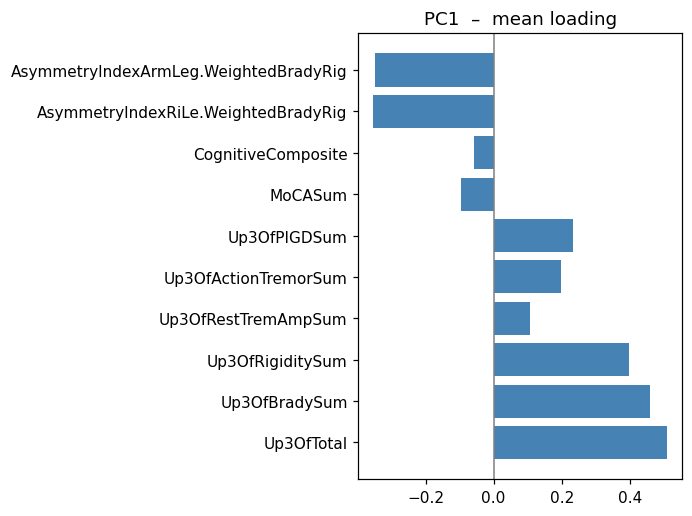

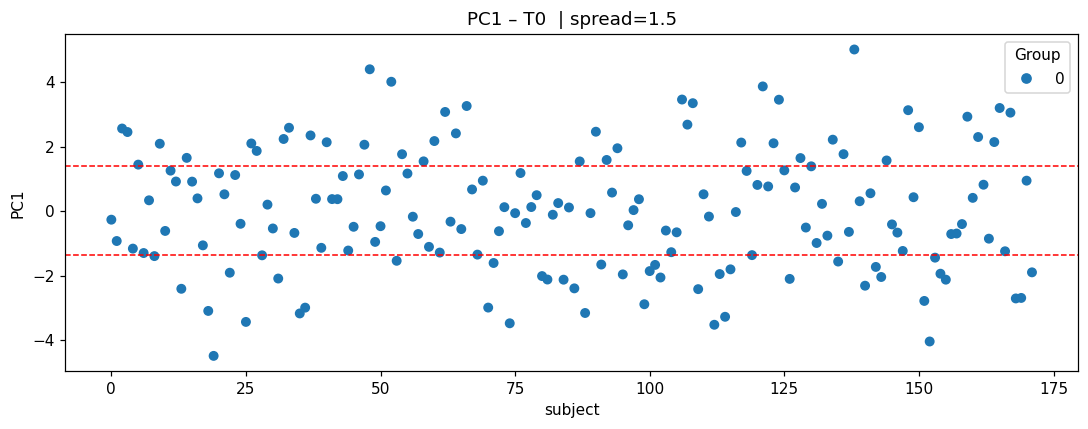

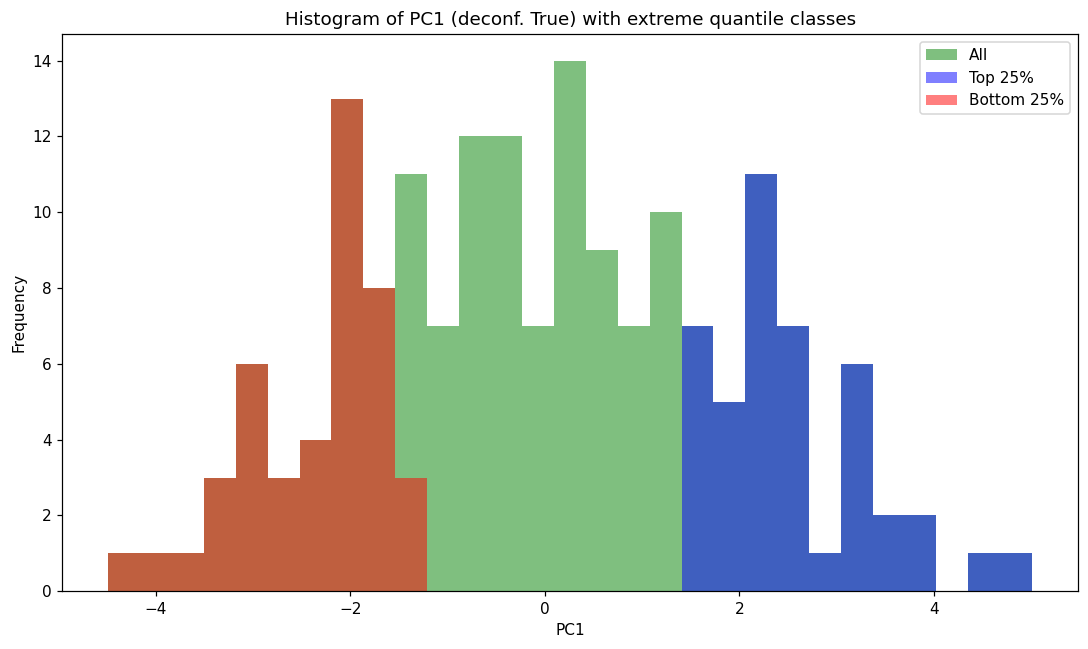

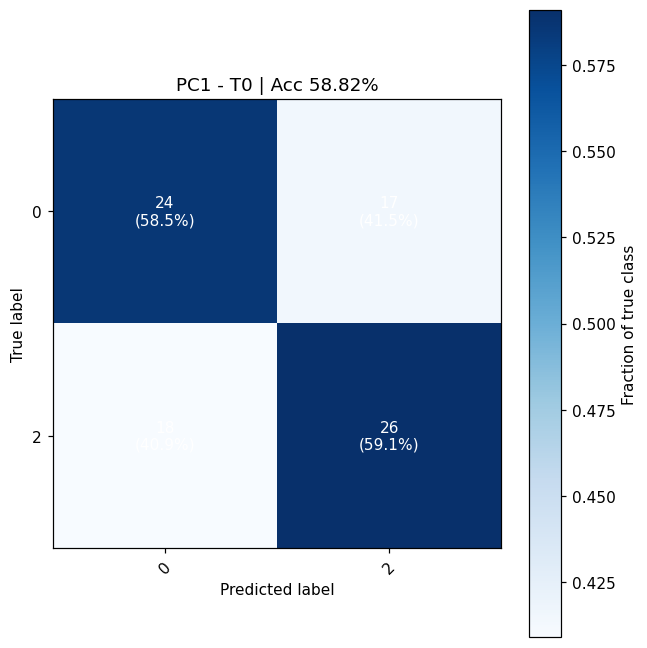

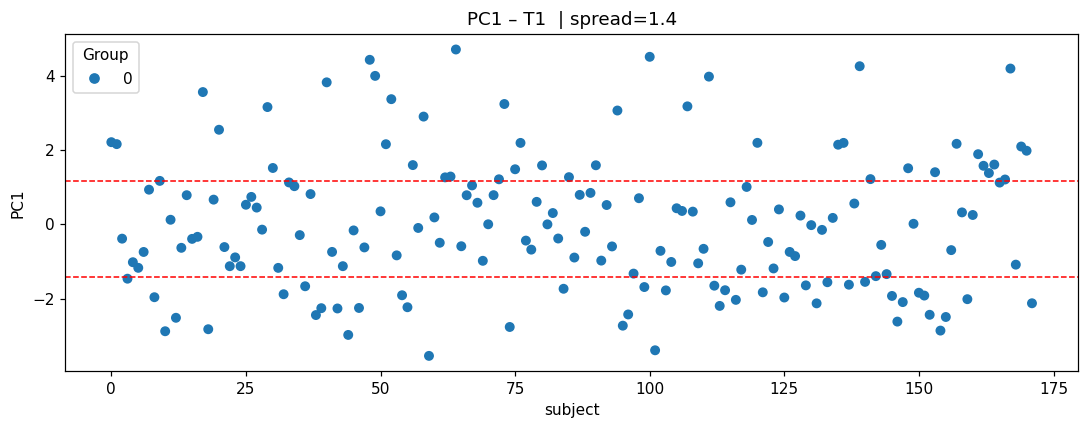

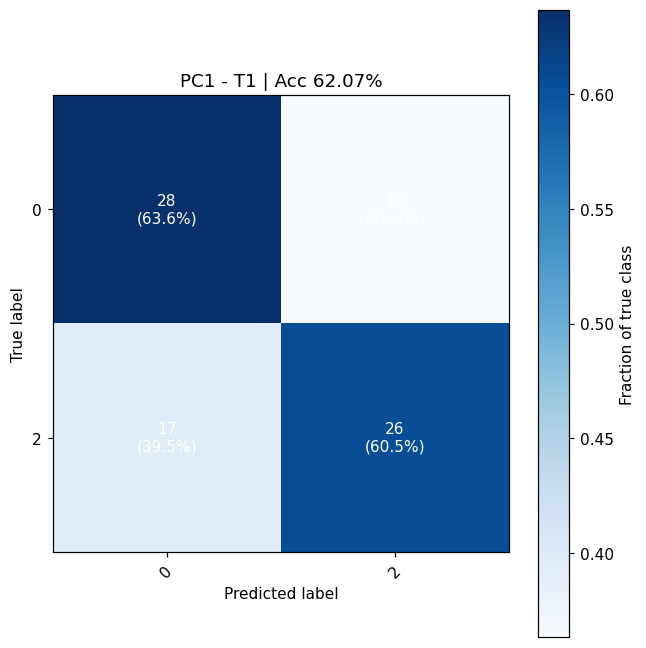

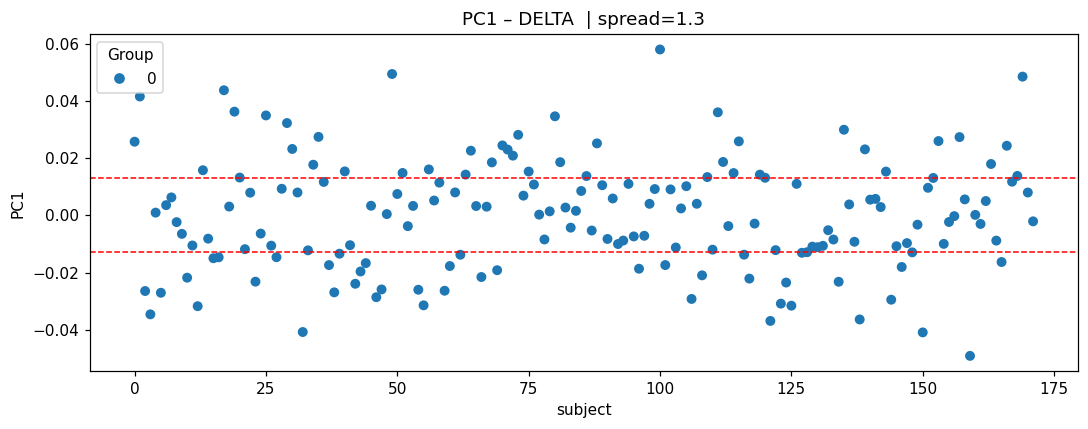

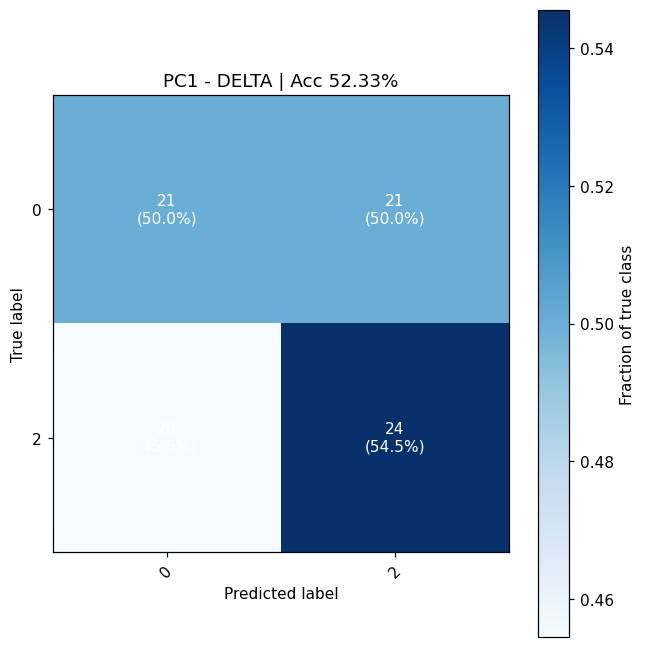

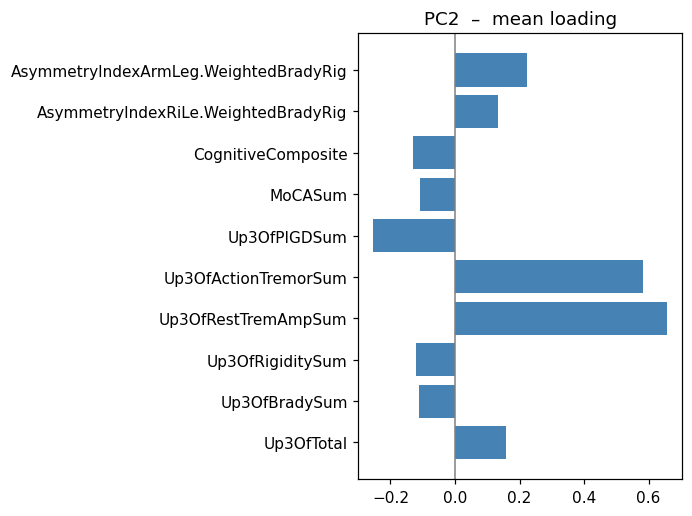

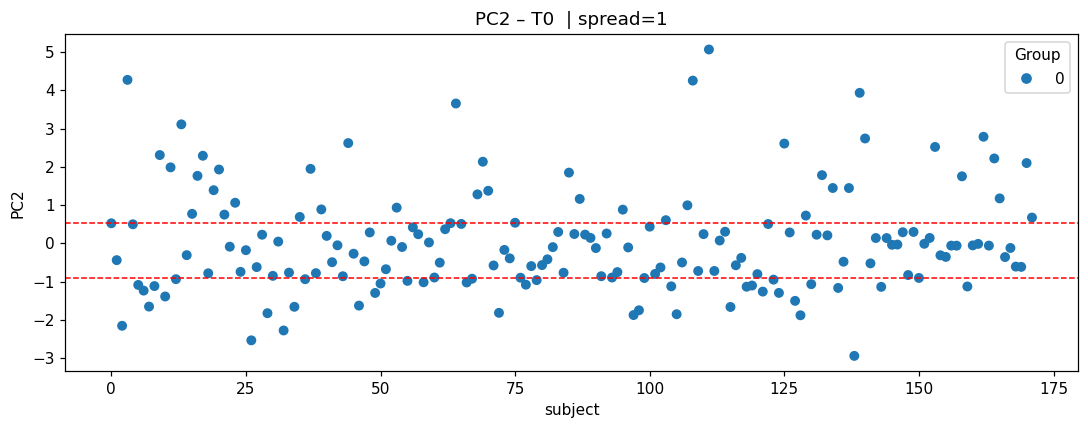

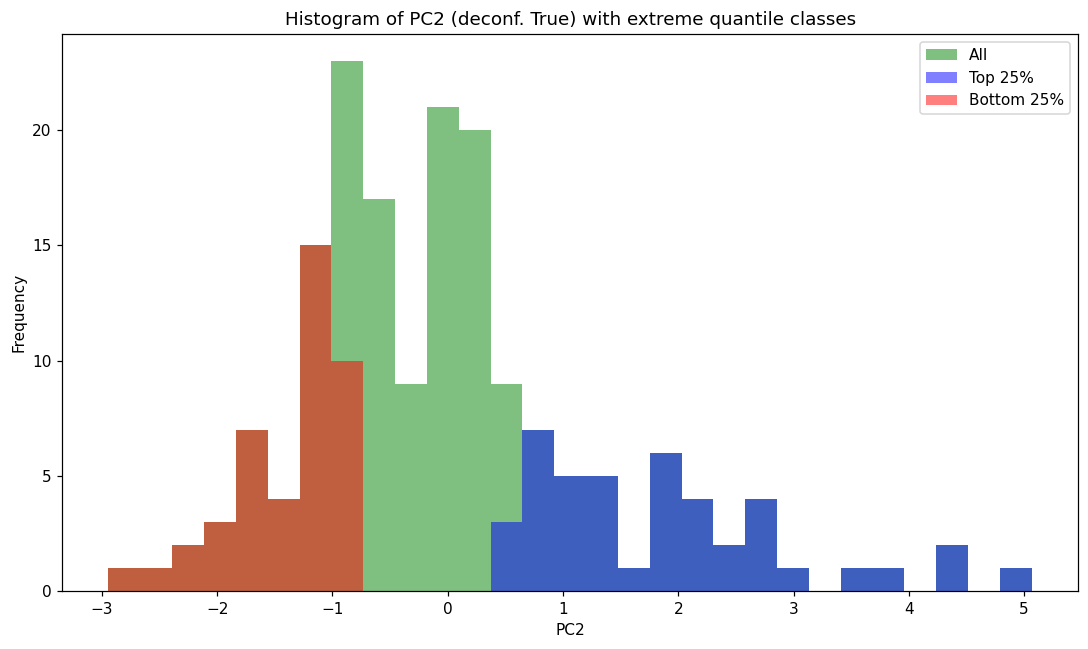

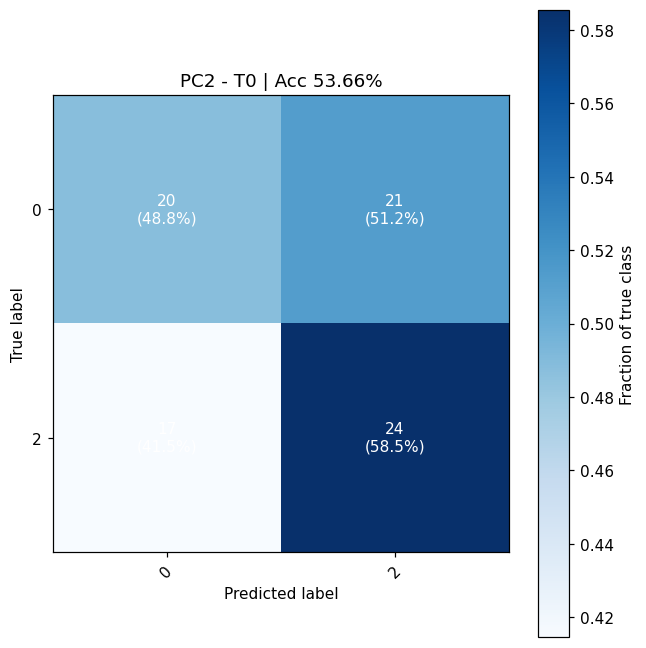

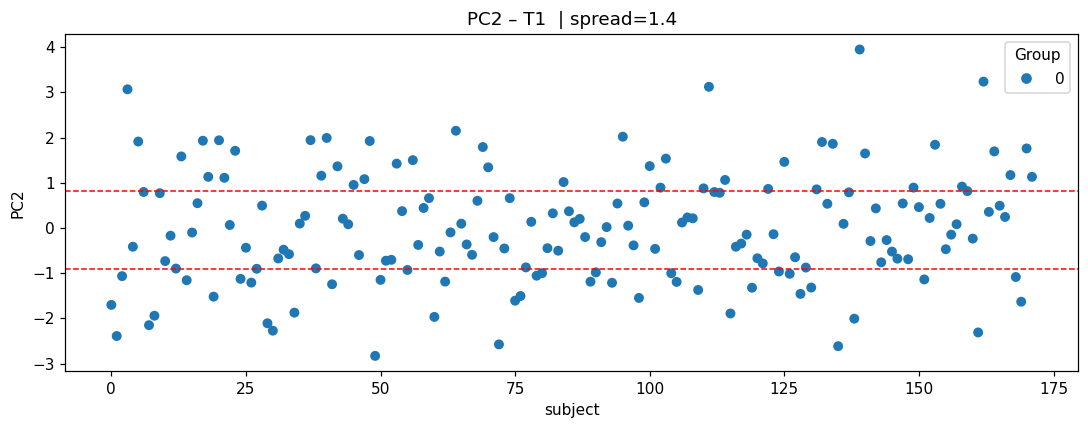

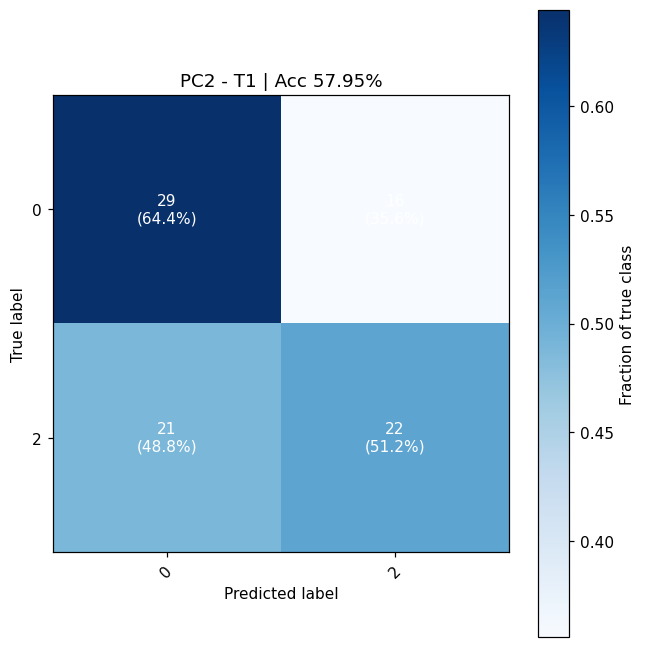

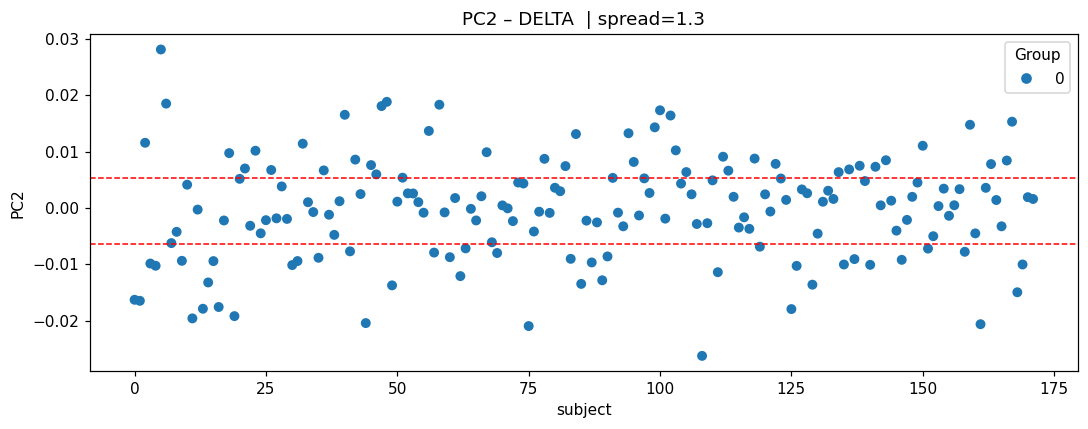

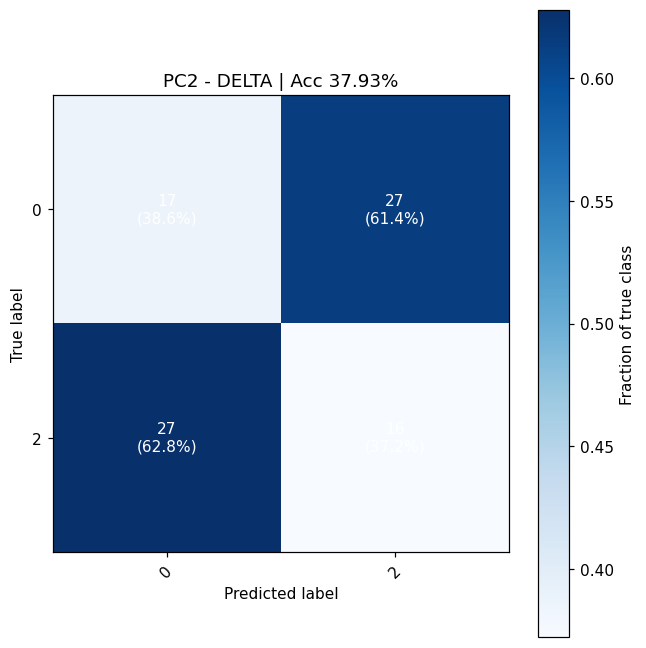

[2]
Kept 236 sessions  covs shape = (236, 122, 122)
Kept 118 subjects
2


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 out of  15 | elapsed:    1.0s remaining:    0.9s
[Parallel(n_jobs=-1)]: Done  15 out of  15 | elapsed:    2.4s finished


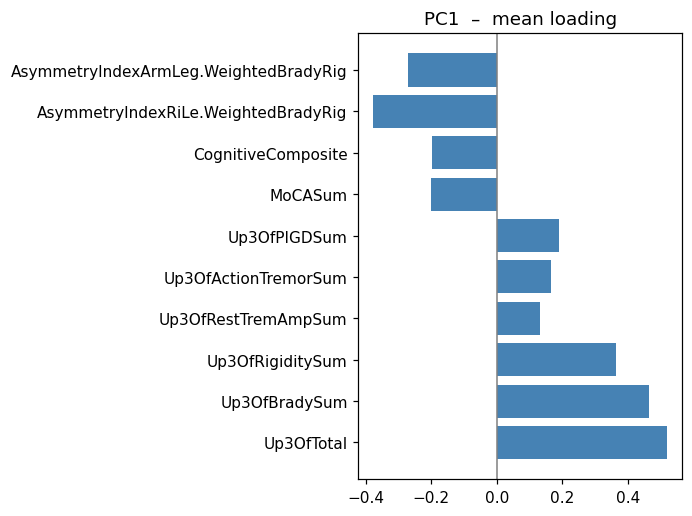

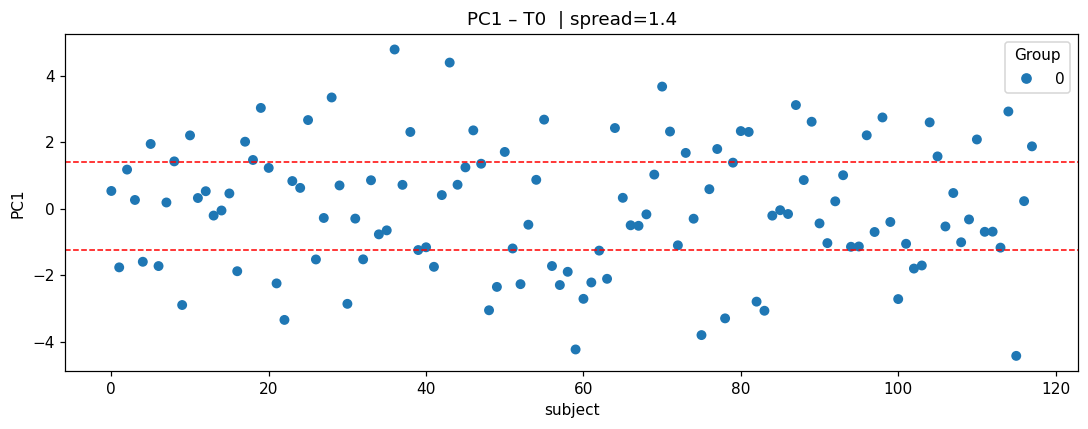

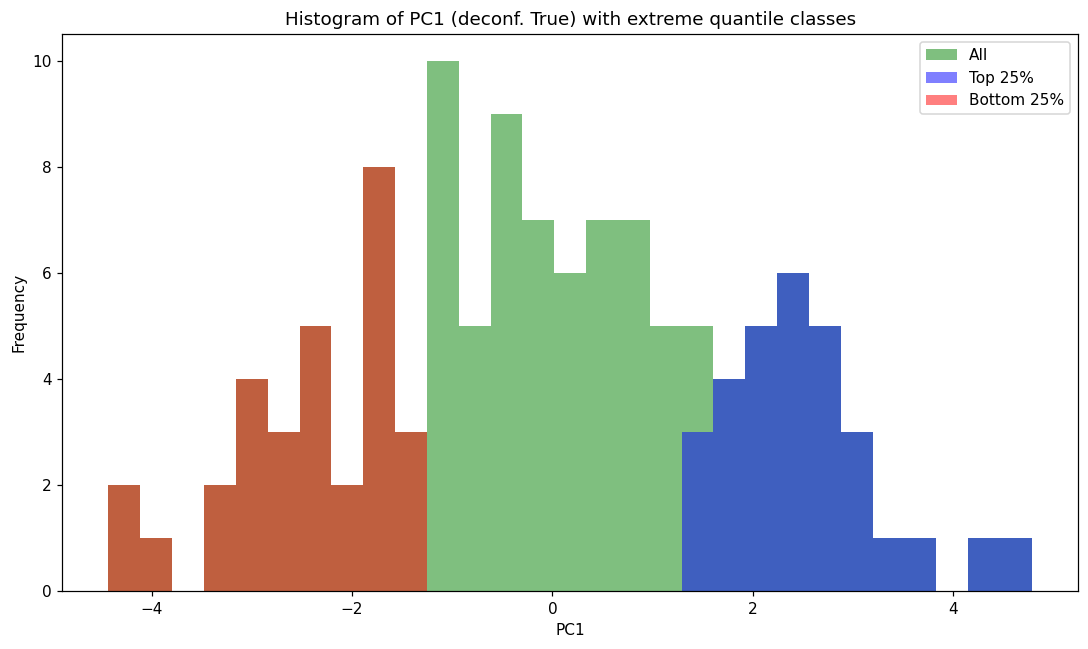

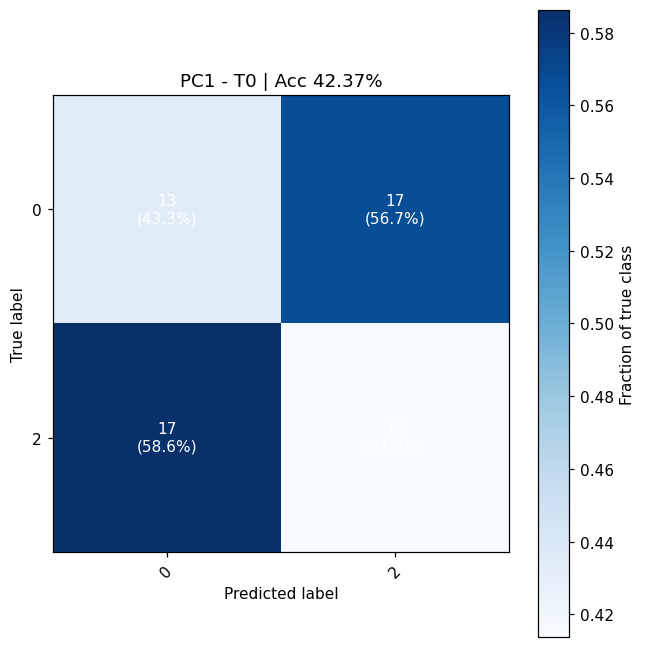

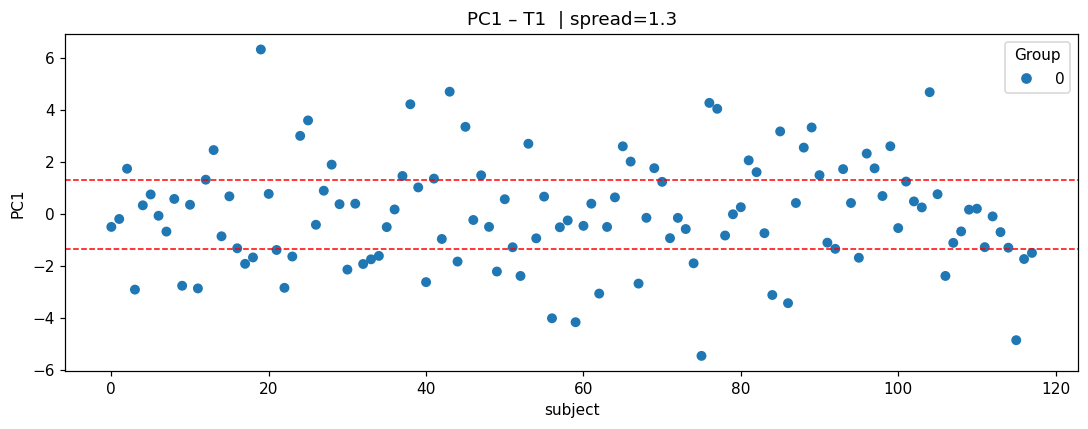

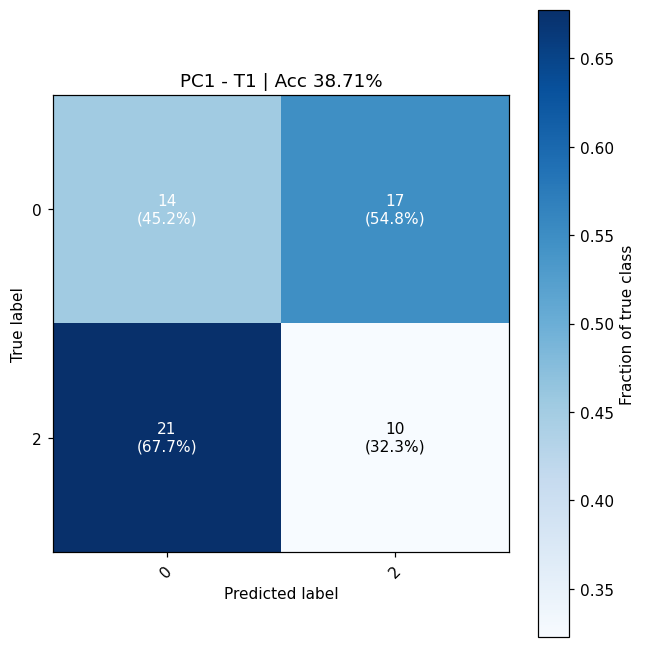

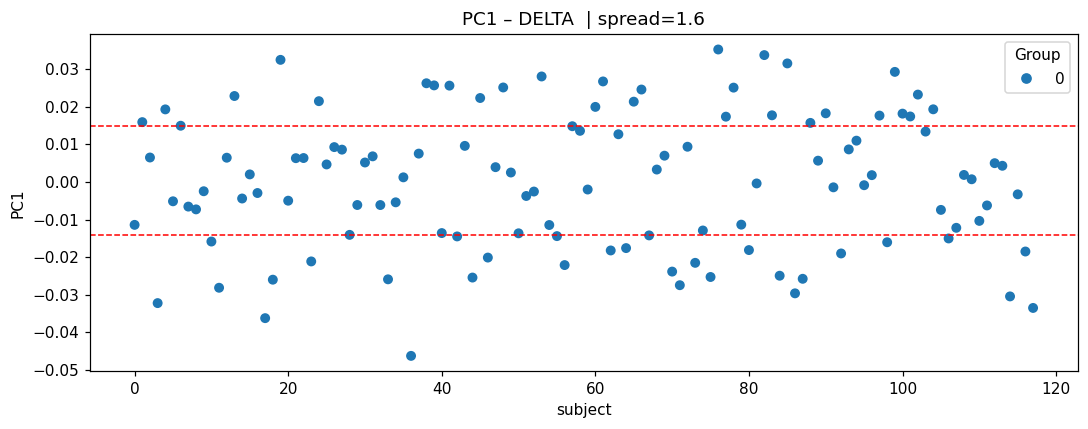

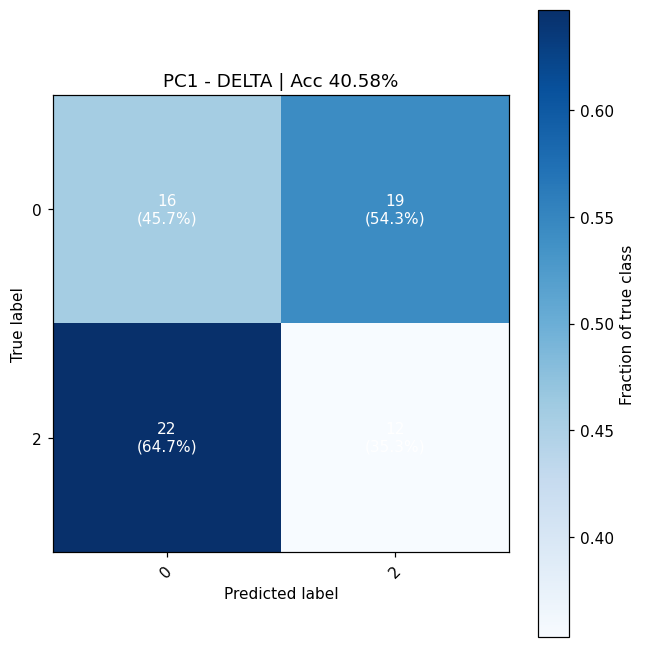

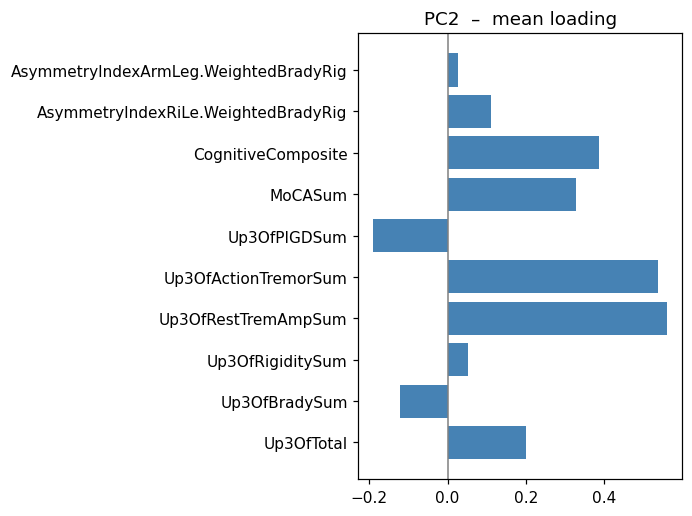

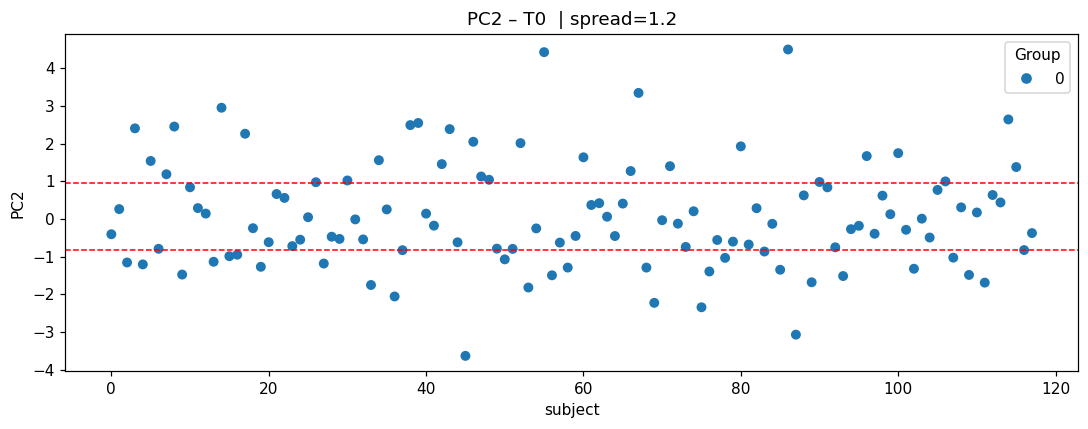

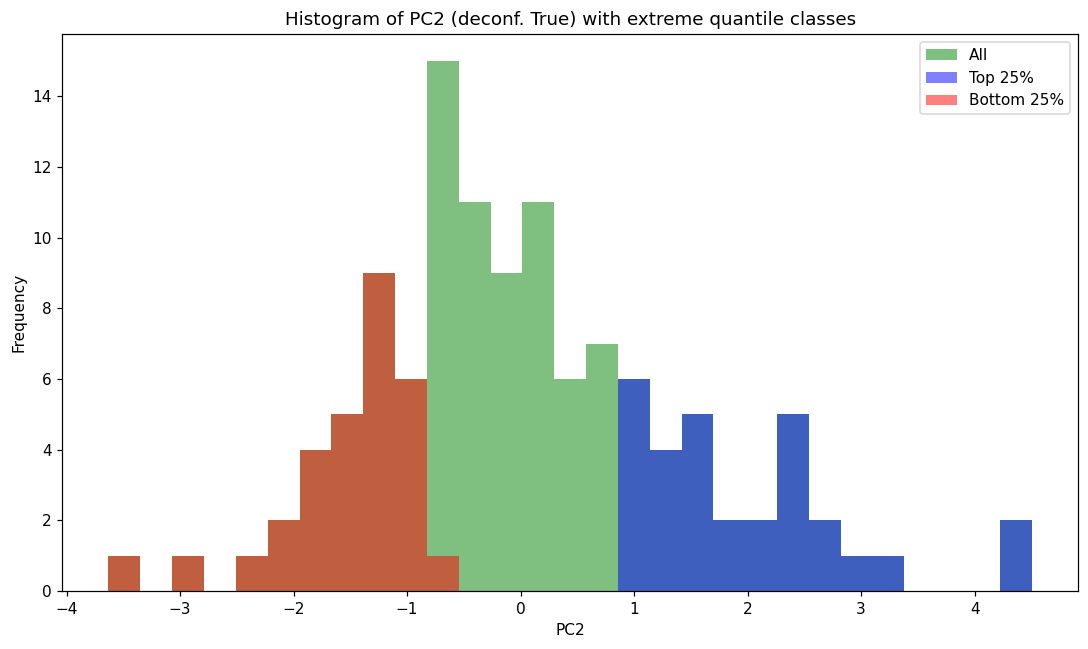

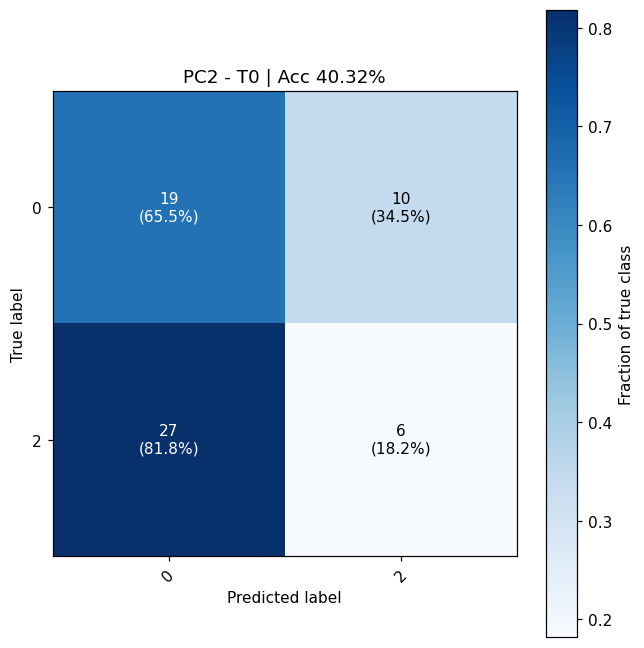

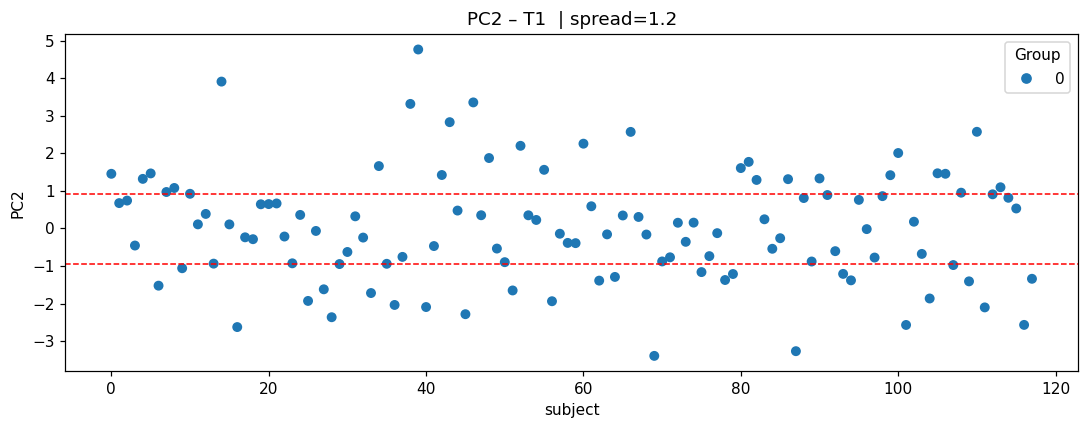

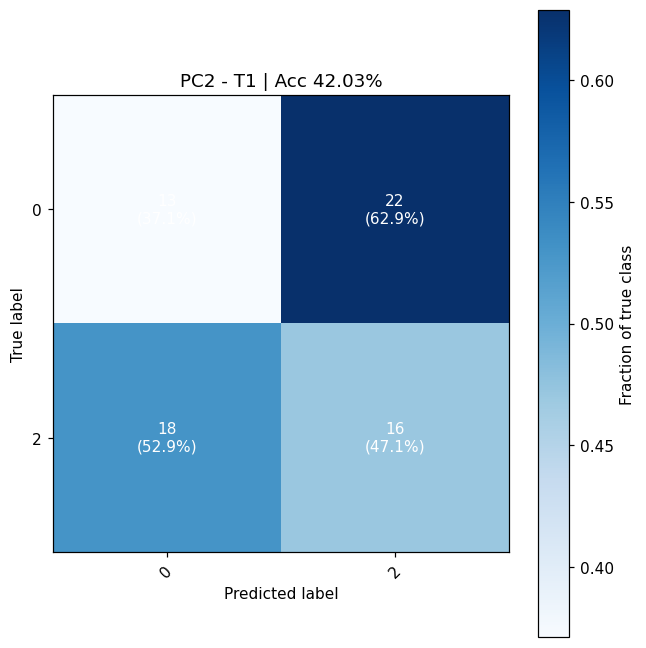

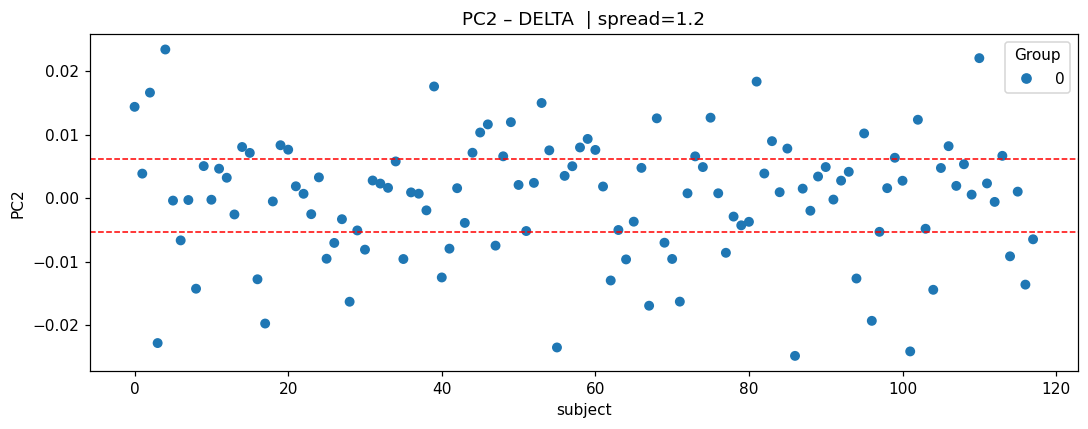

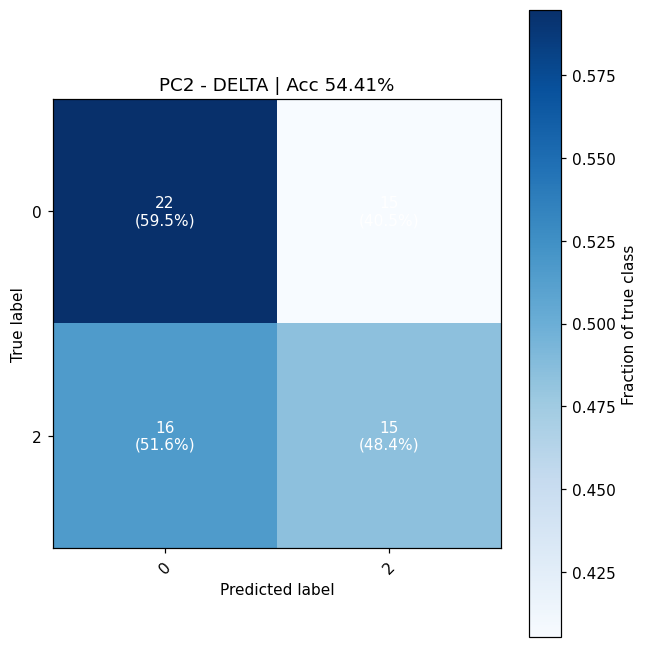

[1, 2]
Kept 580 sessions  covs shape = (580, 122, 122)
Kept 290 subjects
2


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 out of  15 | elapsed:    3.1s remaining:    2.7s
[Parallel(n_jobs=-1)]: Done  15 out of  15 | elapsed:    3.7s finished


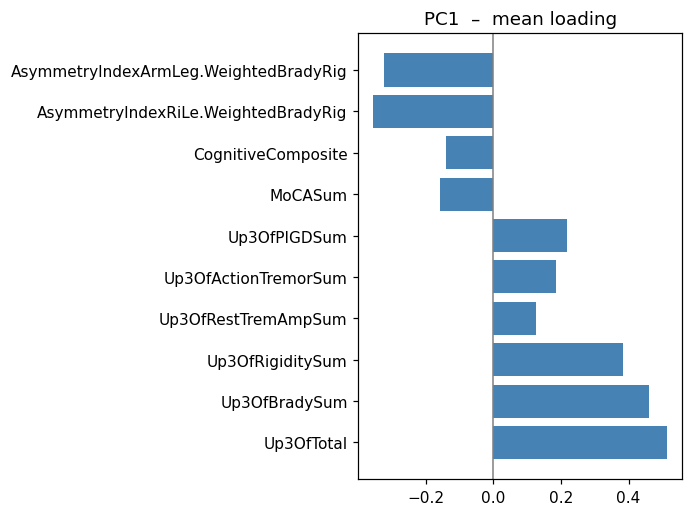

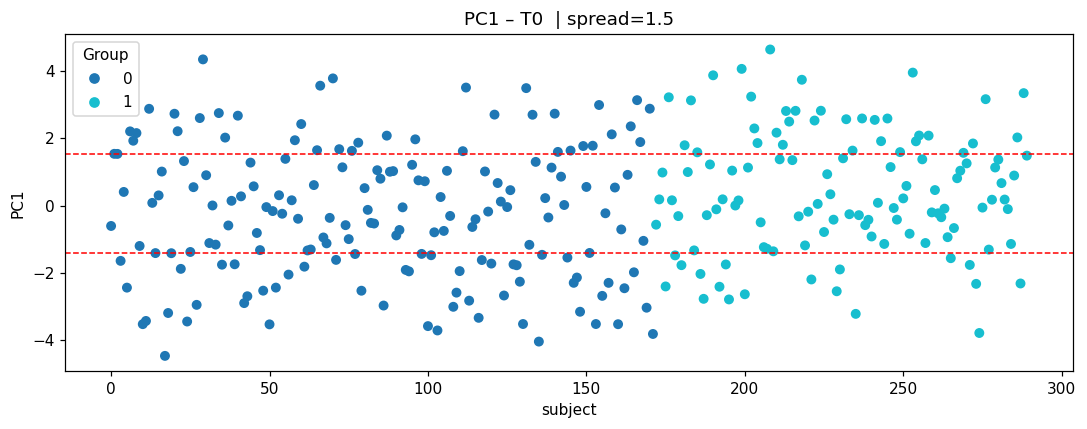

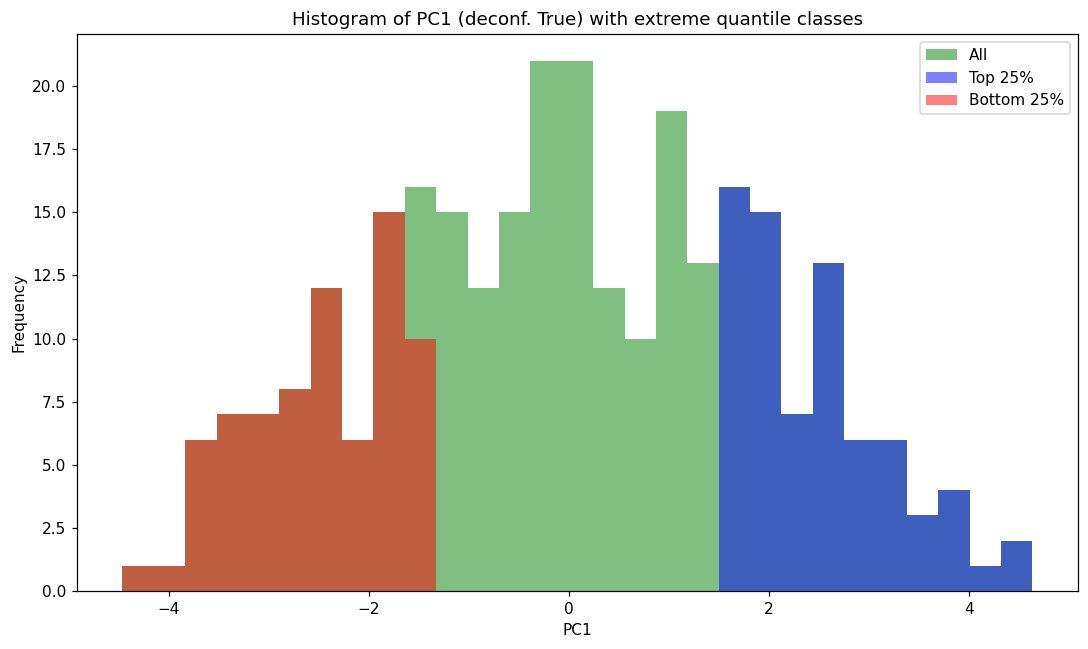

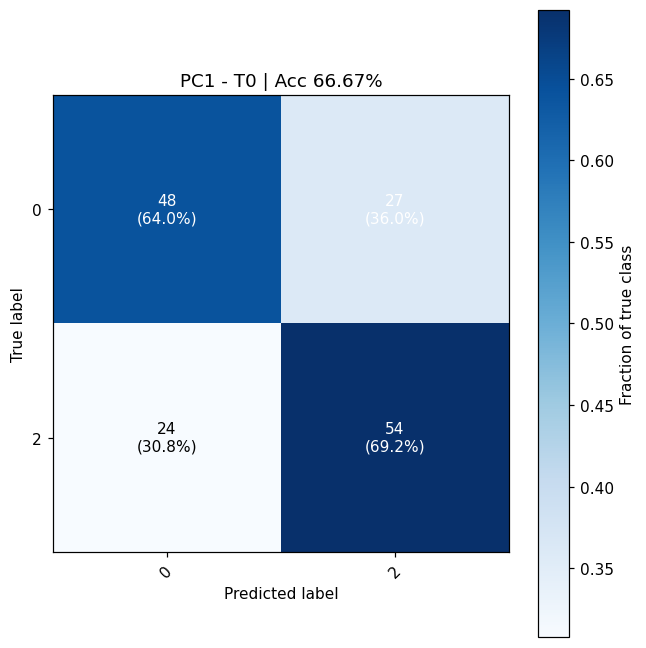

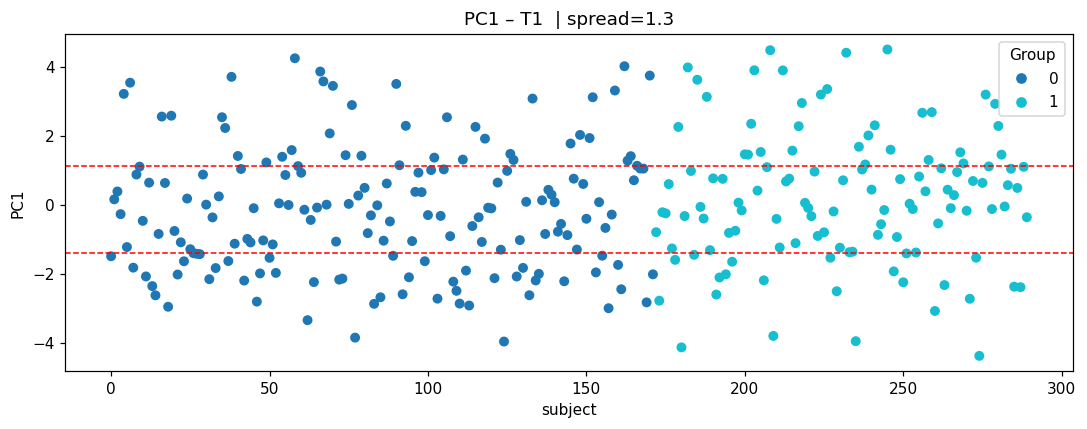

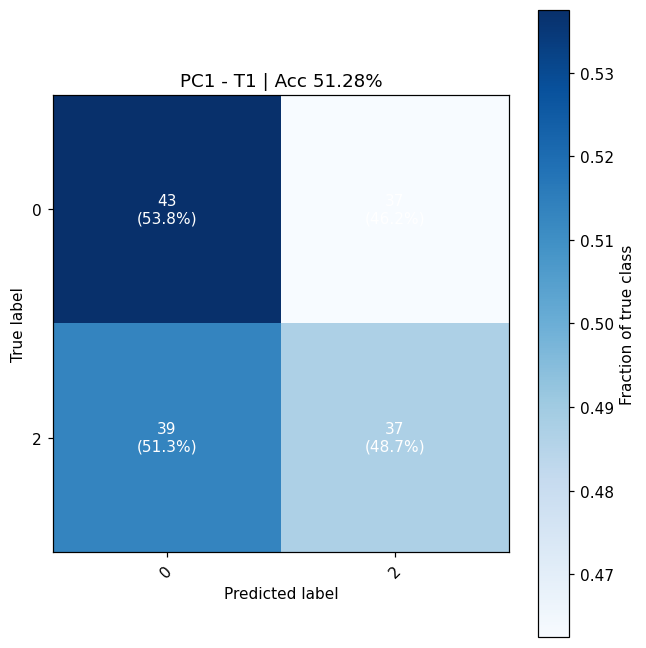

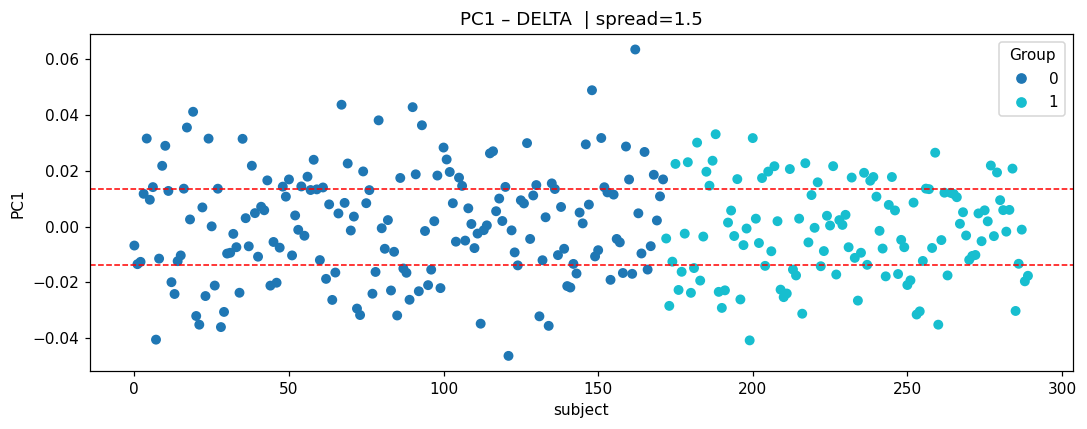

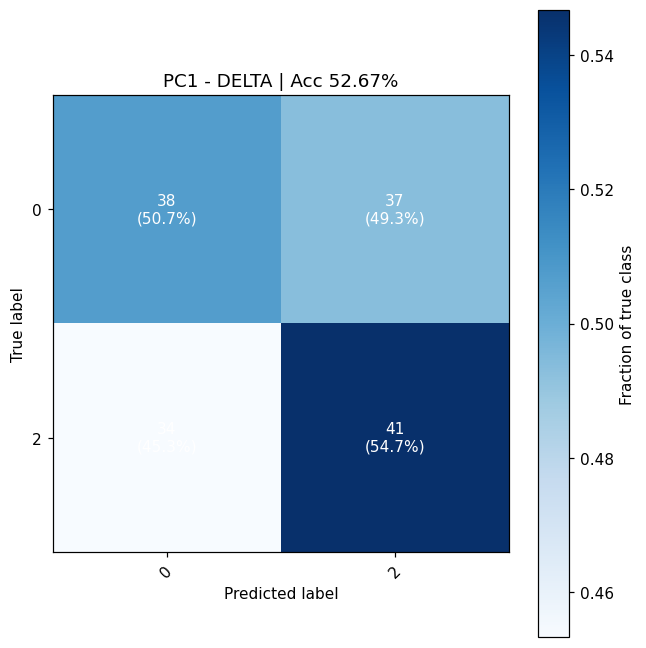

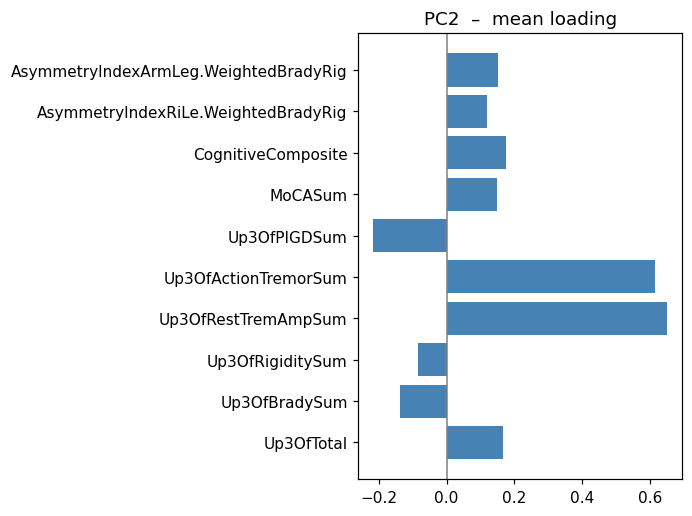

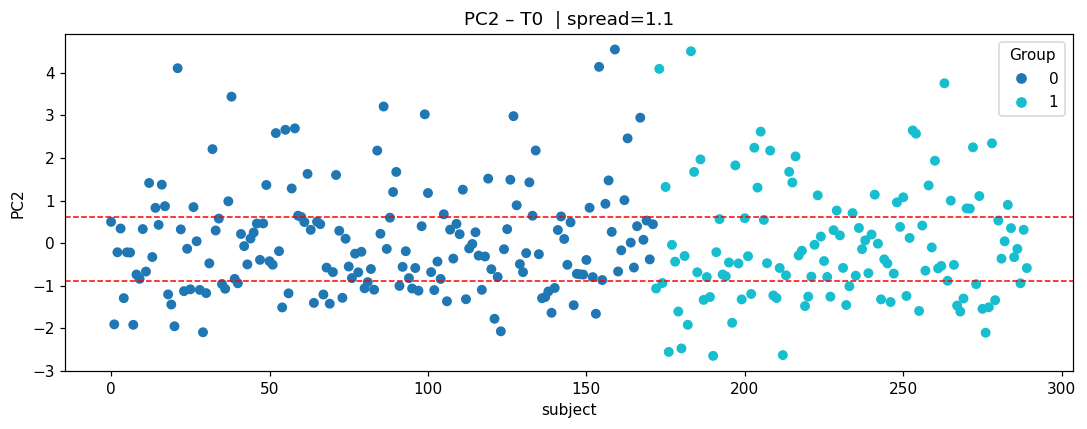

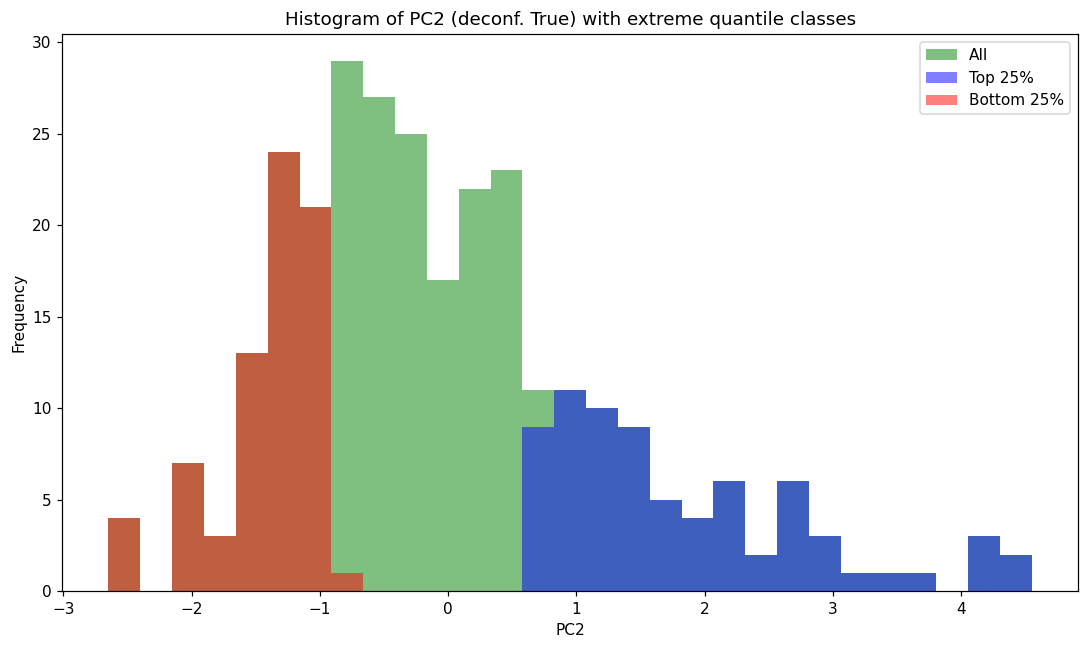

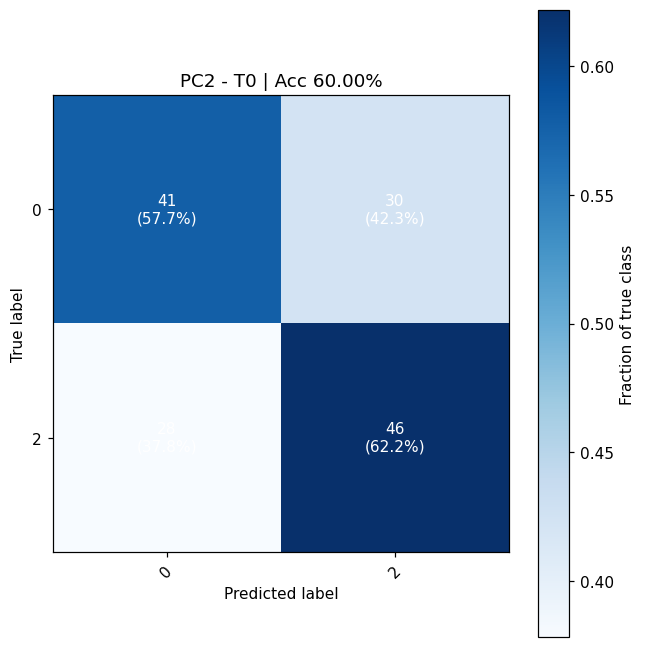

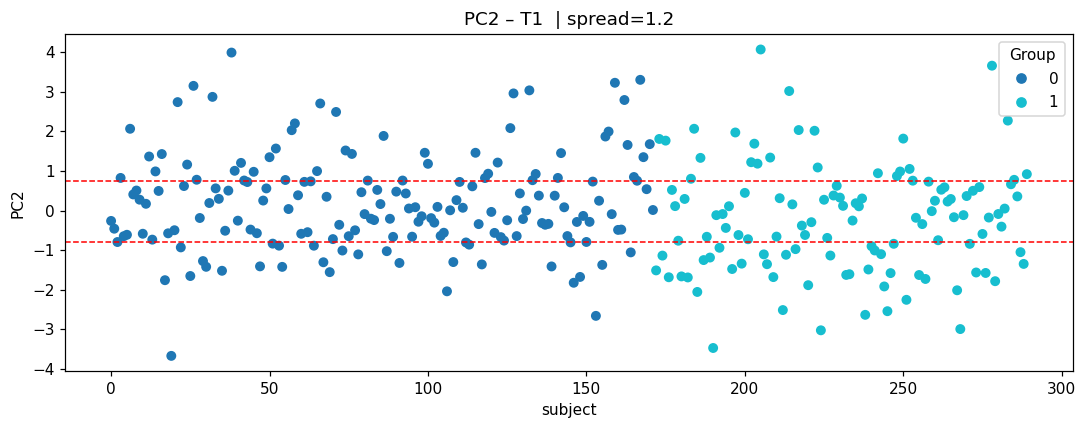

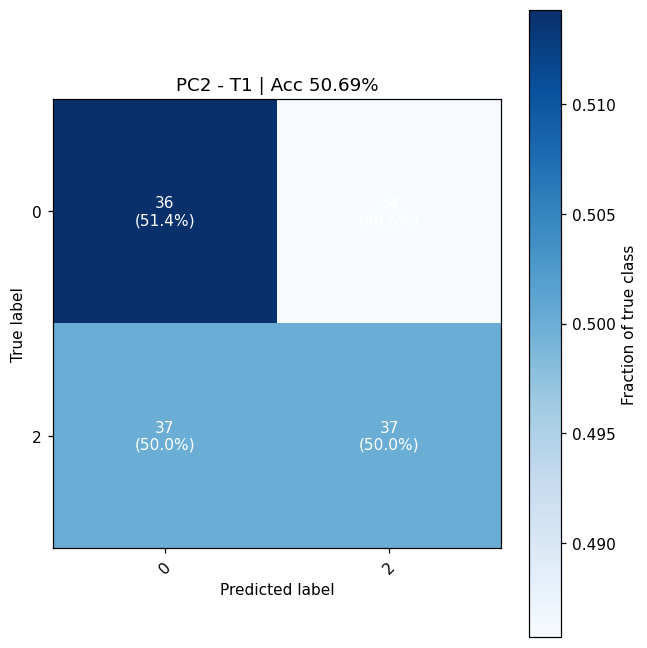

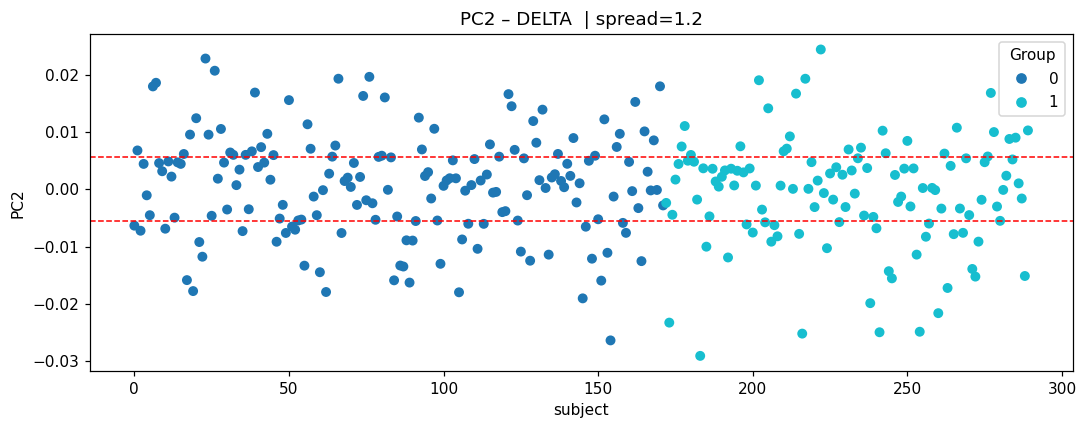

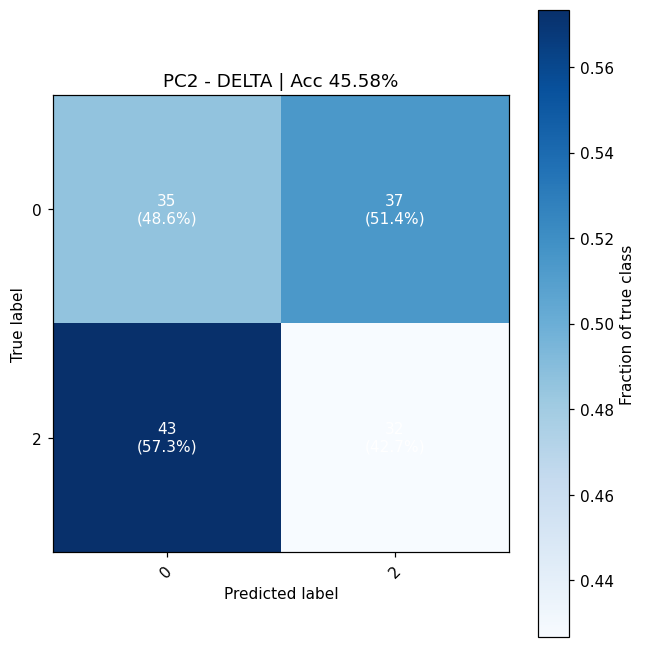

[1, 2, 3]
Kept 646 sessions  covs shape = (646, 122, 122)
Kept 323 subjects
2


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 out of  15 | elapsed:    2.2s remaining:    1.9s
[Parallel(n_jobs=-1)]: Done  15 out of  15 | elapsed:    3.8s finished


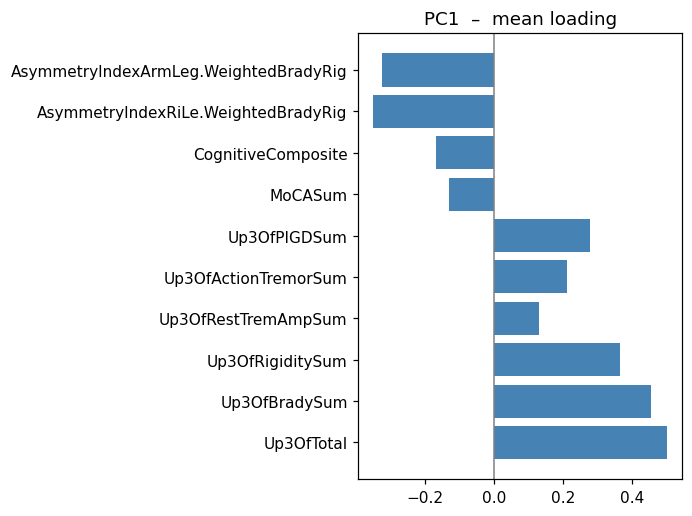

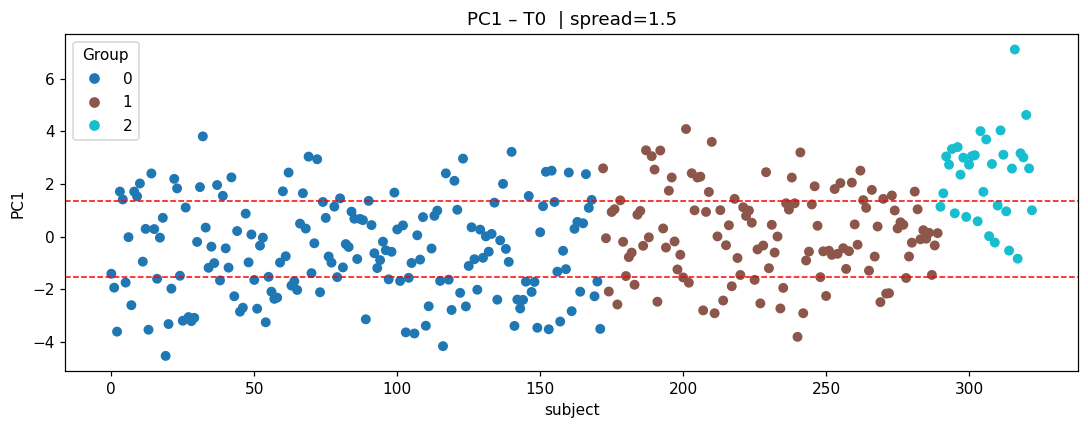

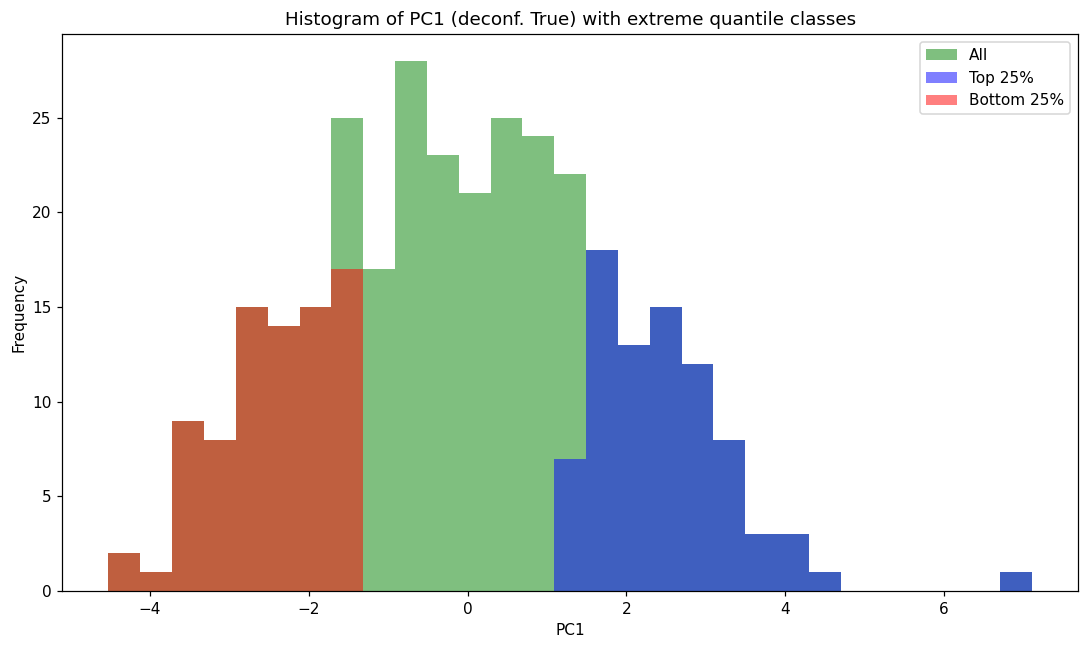

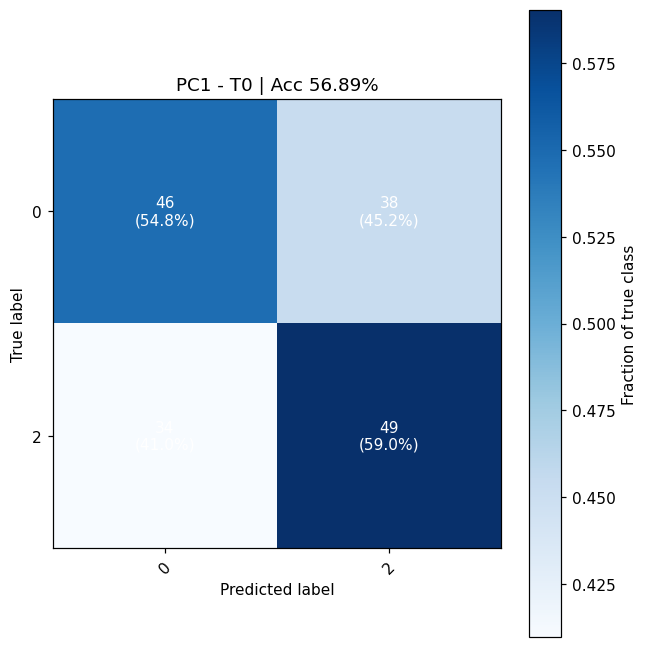

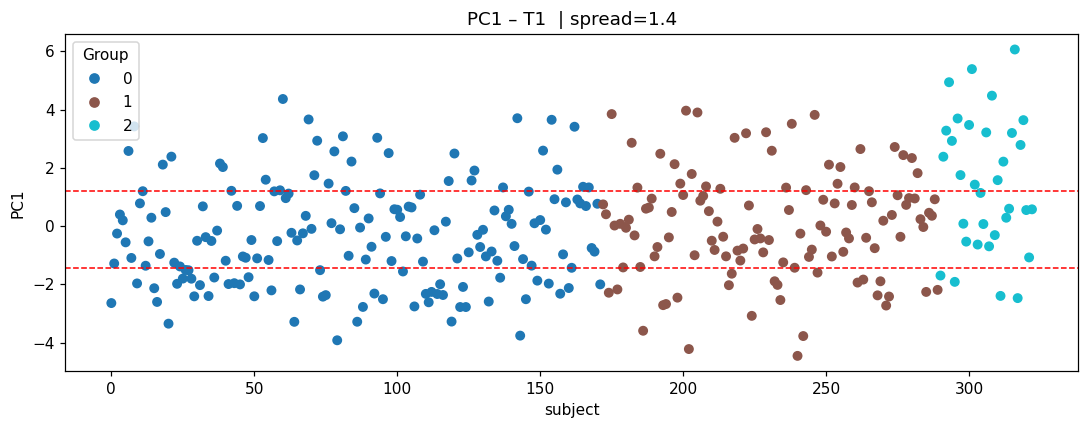

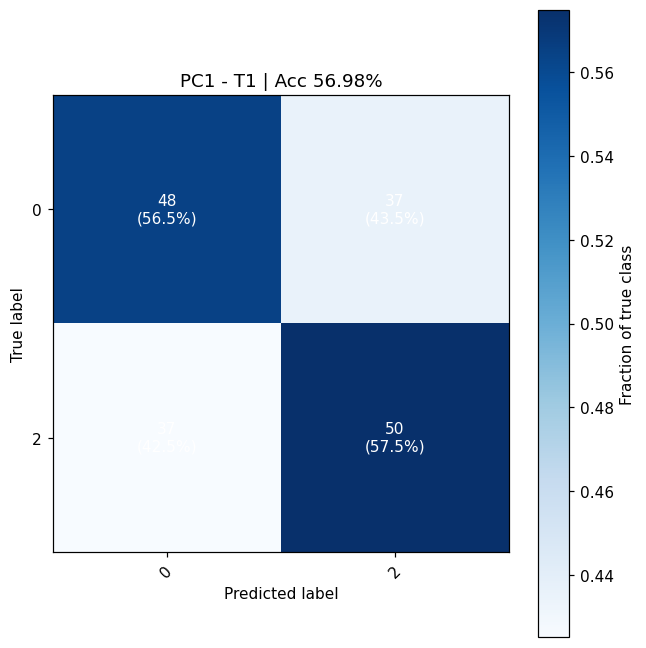

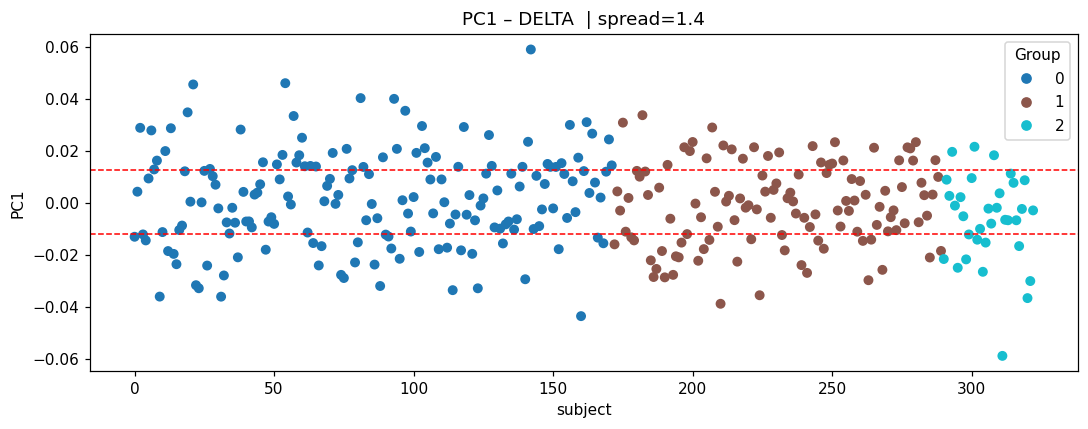

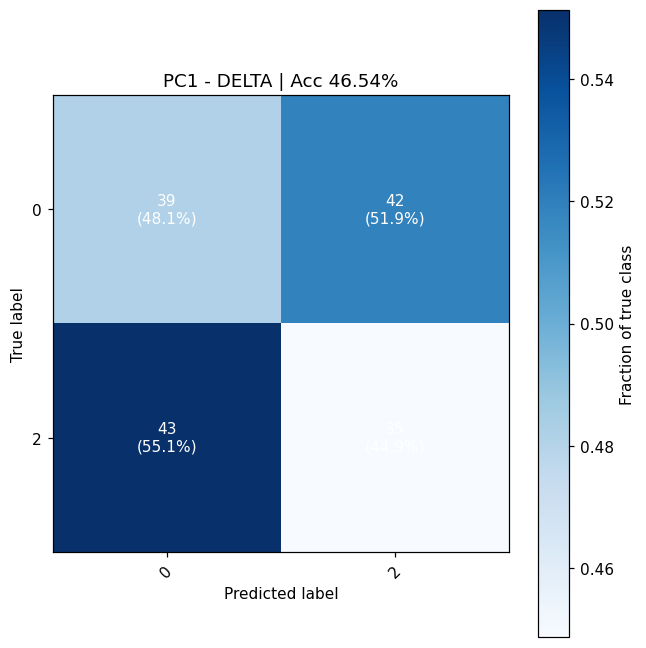

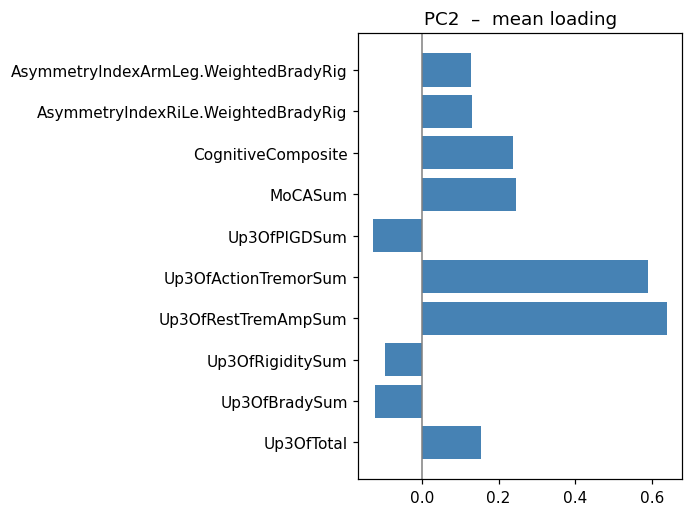

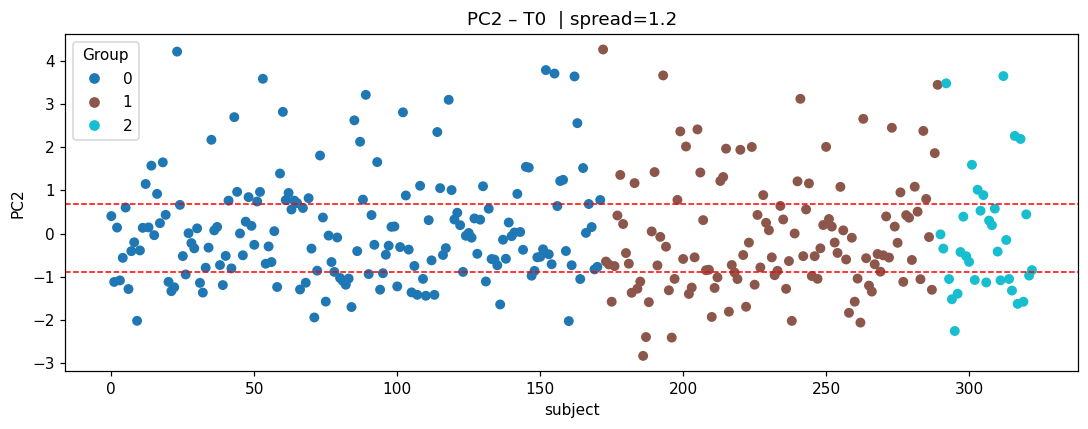

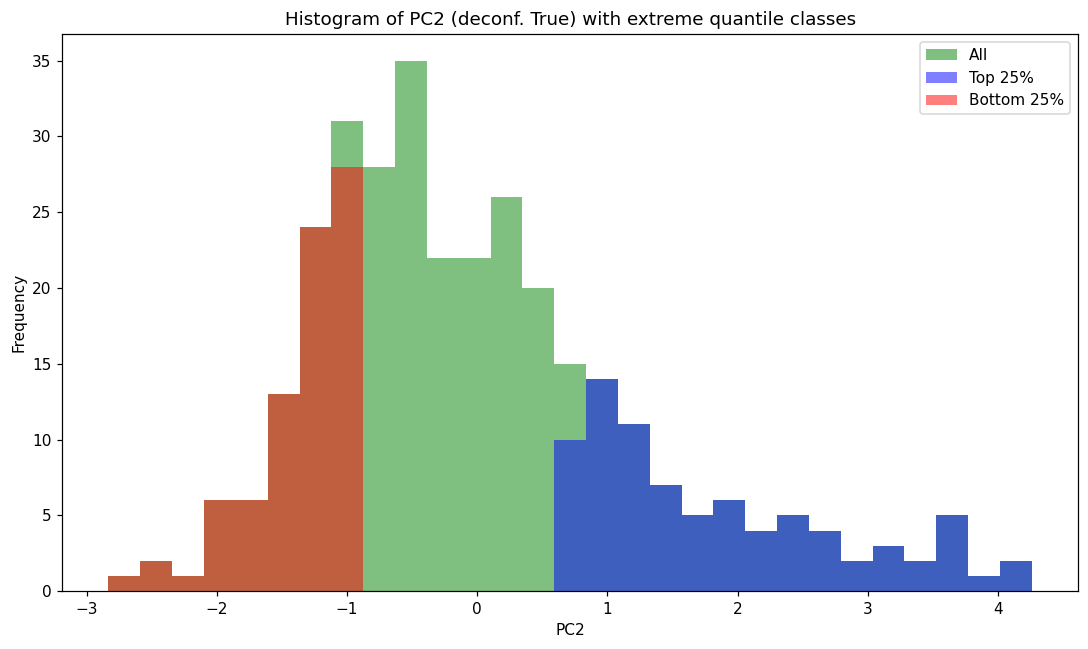

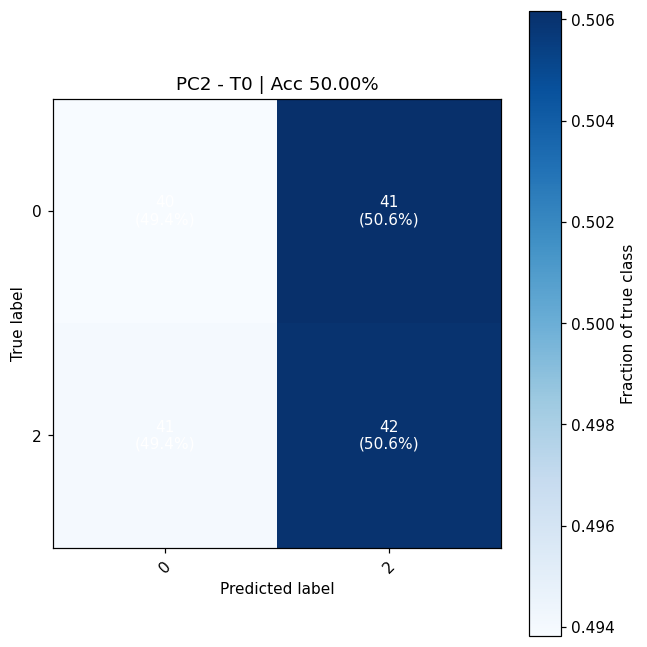

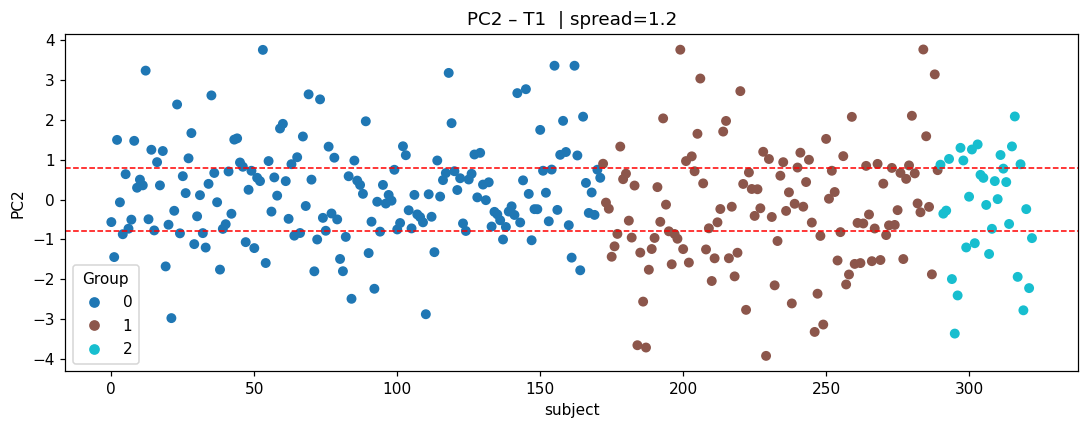

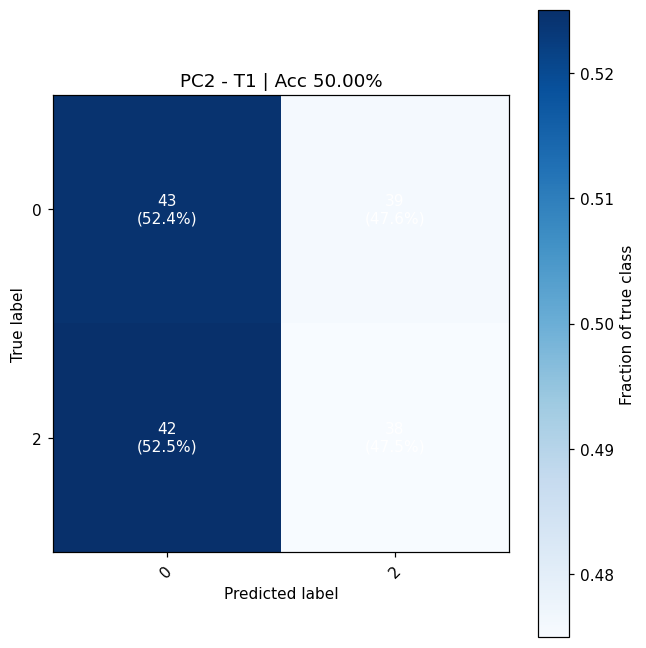

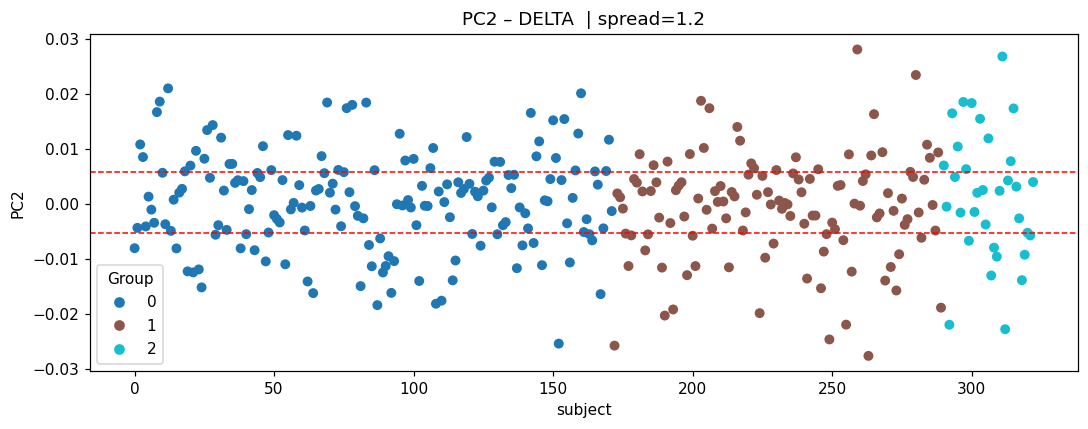

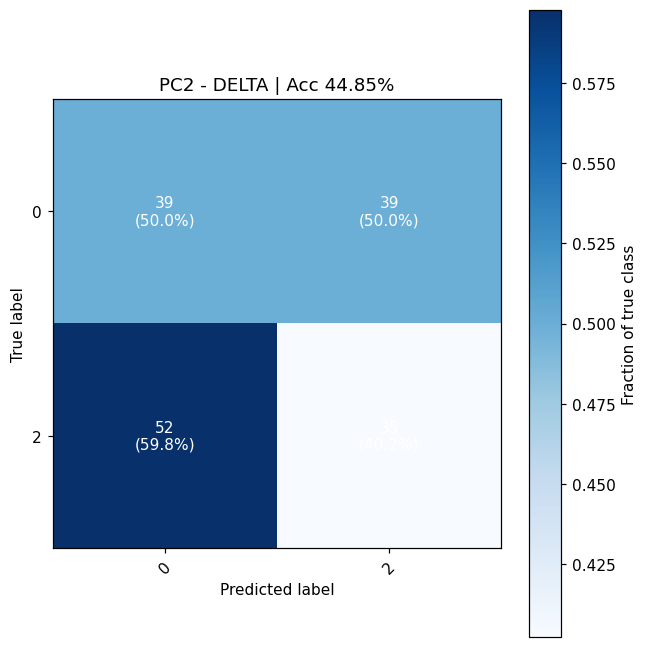

[1, 2, 3, 4]
Kept 678 sessions  covs shape = (678, 122, 122)
Kept 339 subjects
2


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 out of  15 | elapsed:    2.6s remaining:    2.3s
[Parallel(n_jobs=-1)]: Done  15 out of  15 | elapsed:    4.2s finished


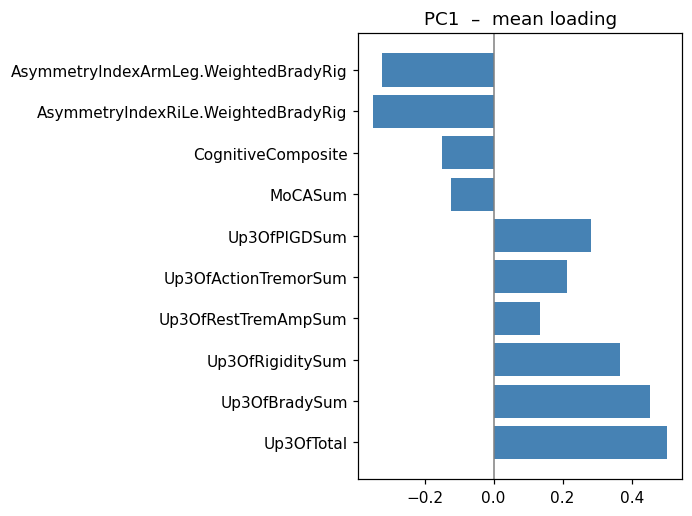

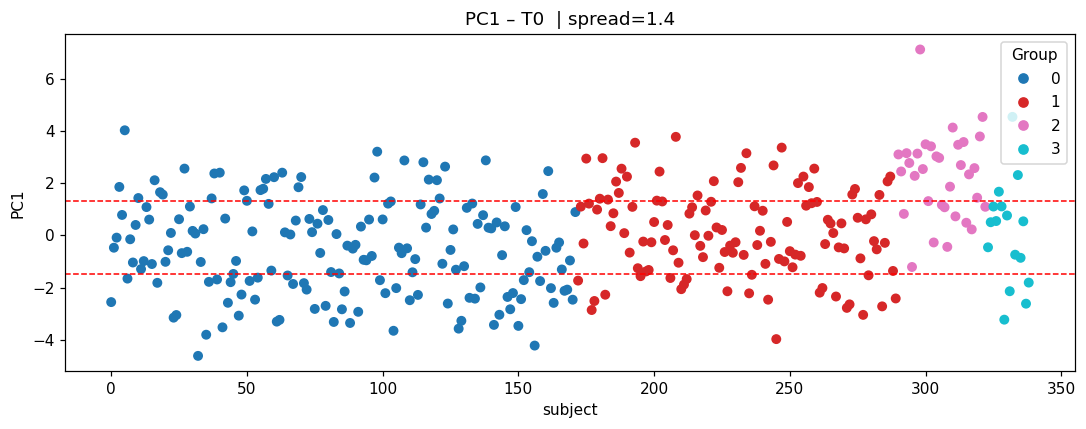

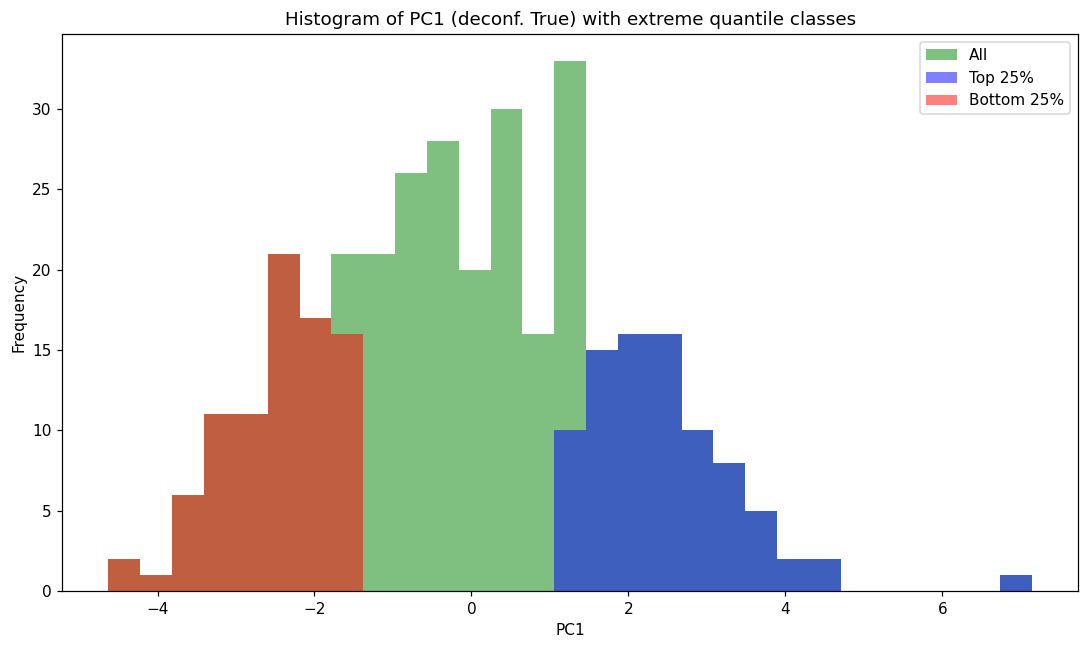

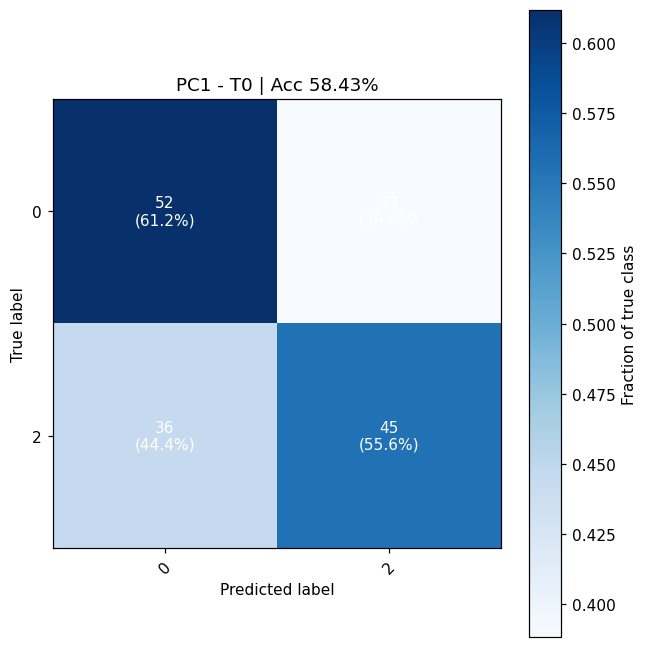

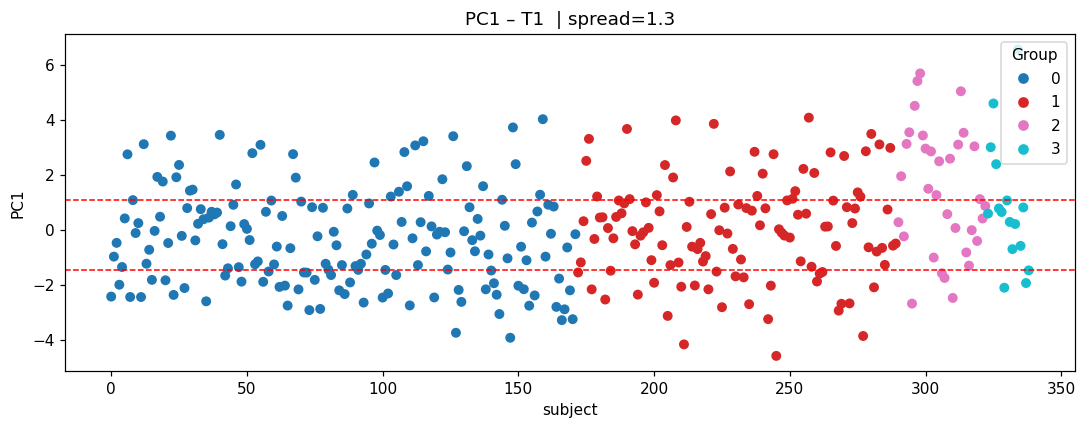

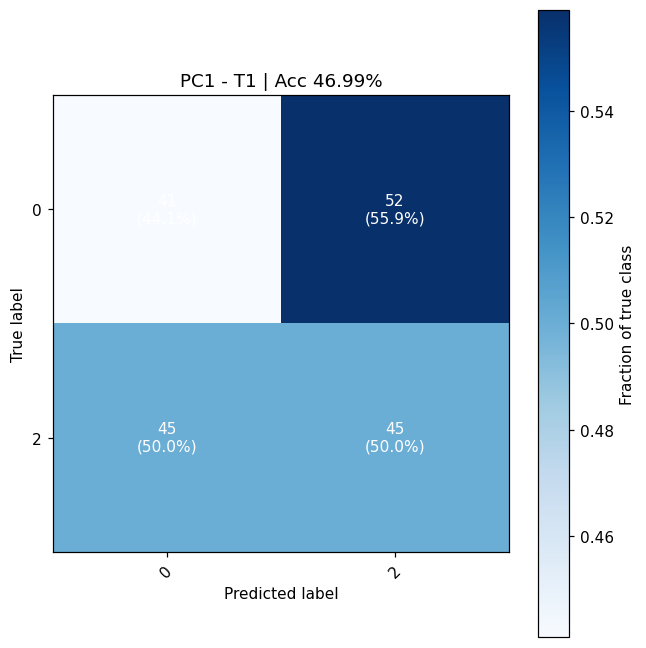

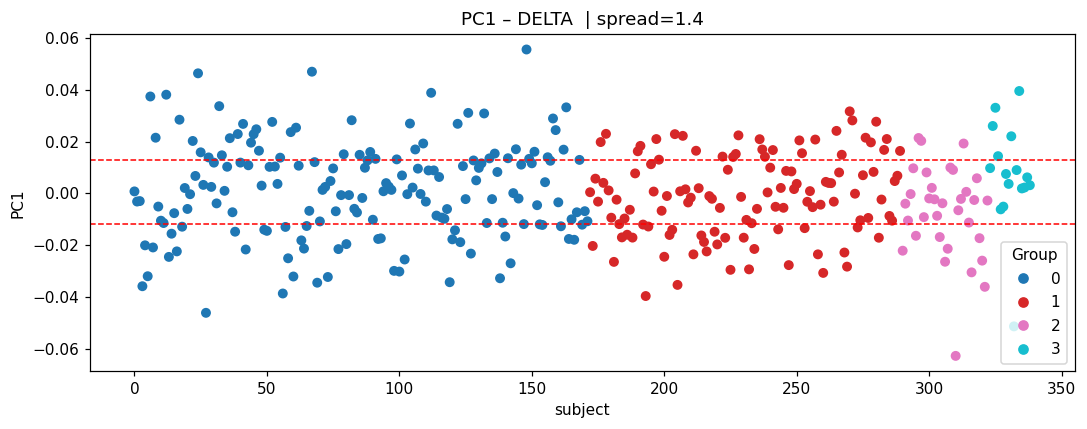

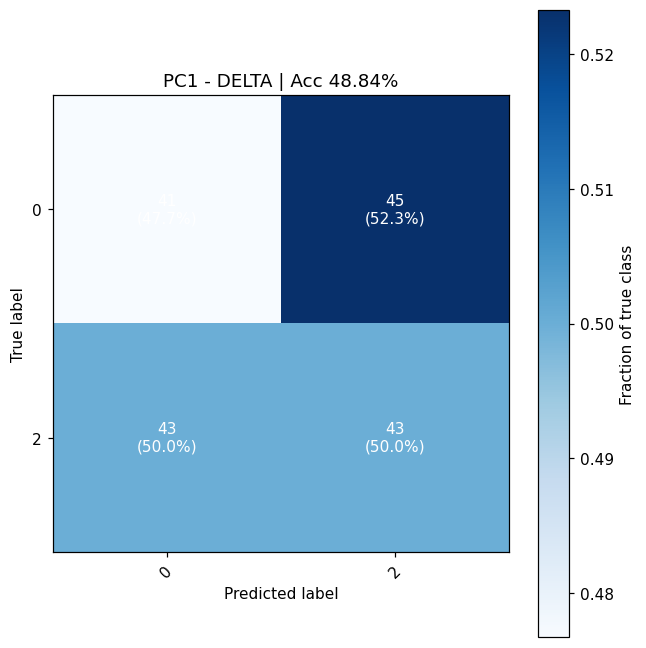

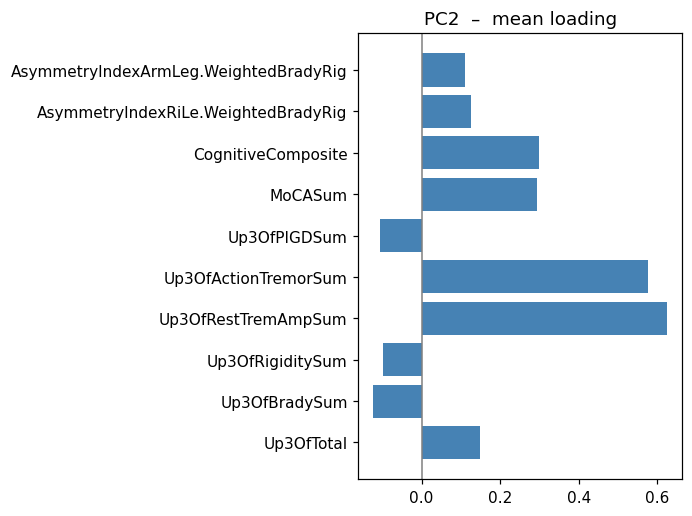

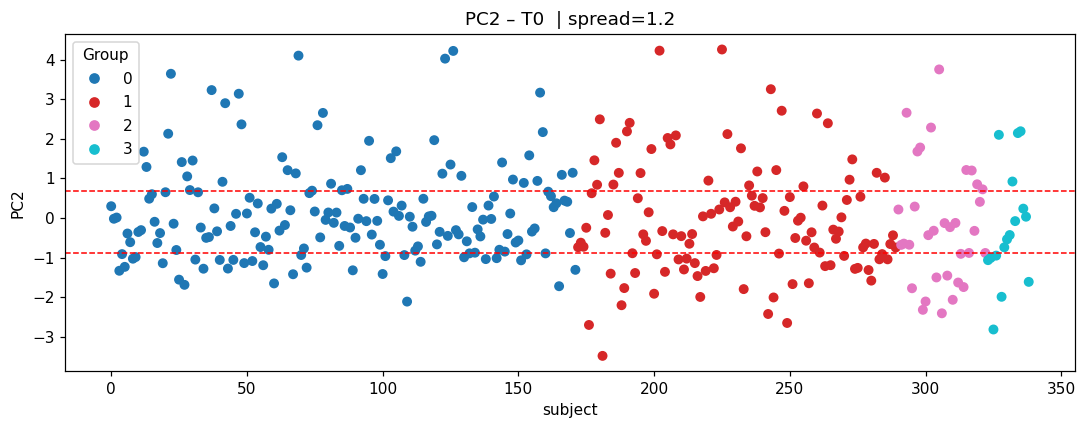

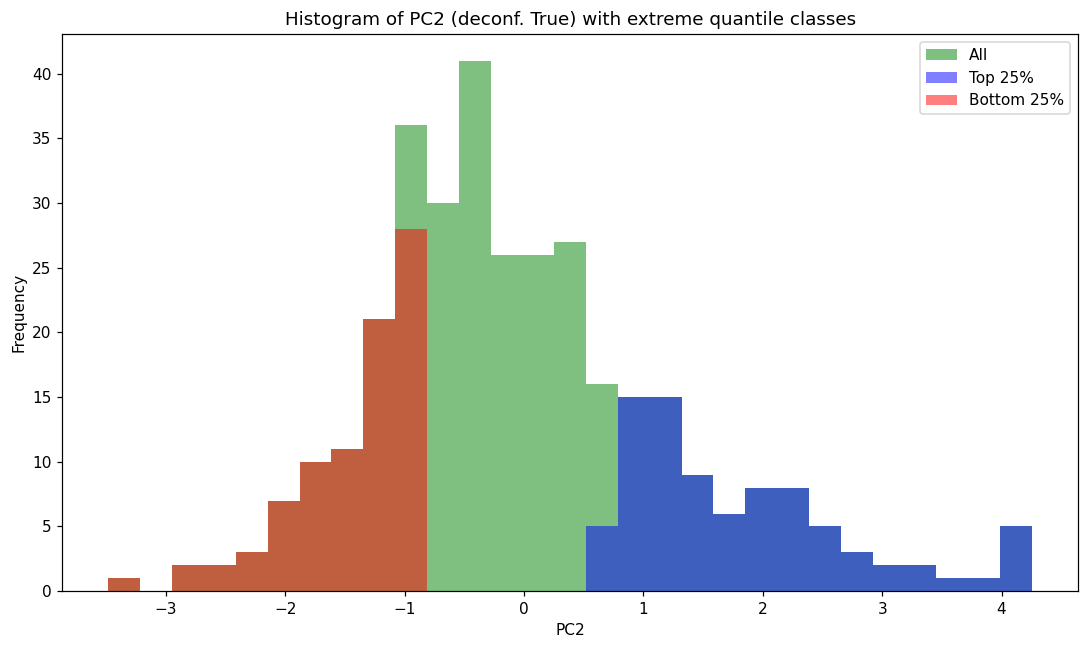

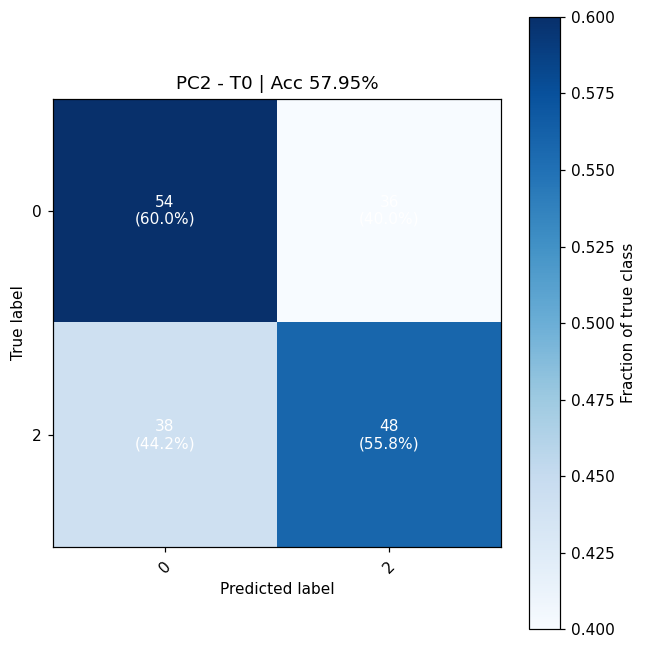

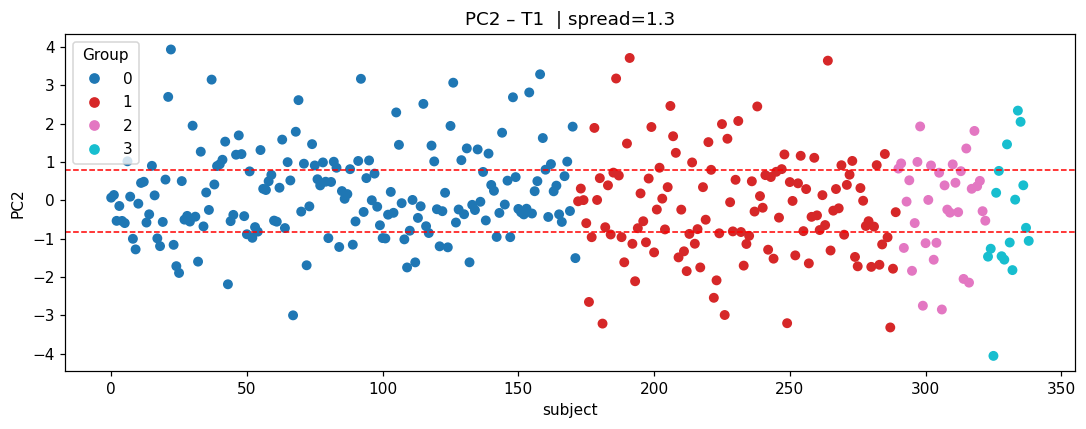

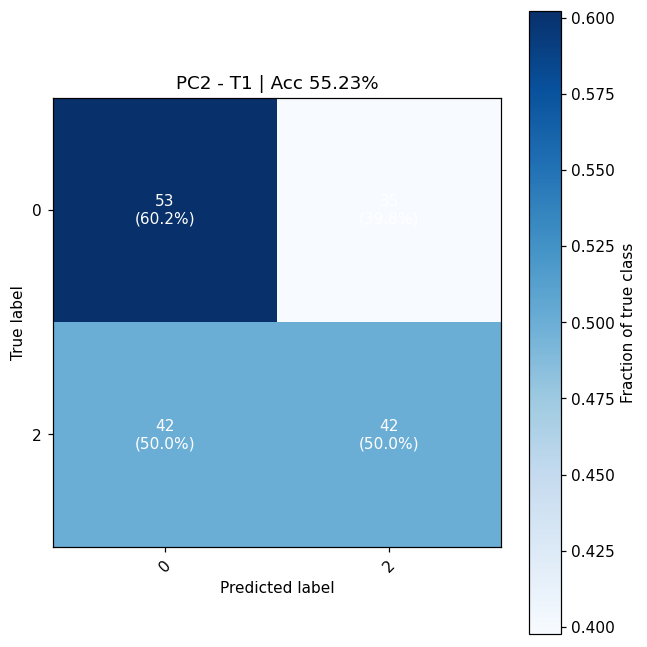

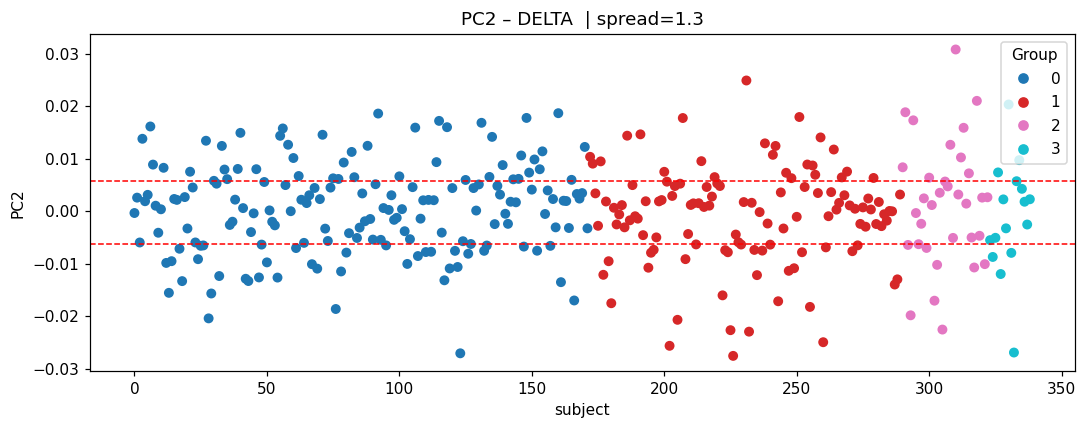

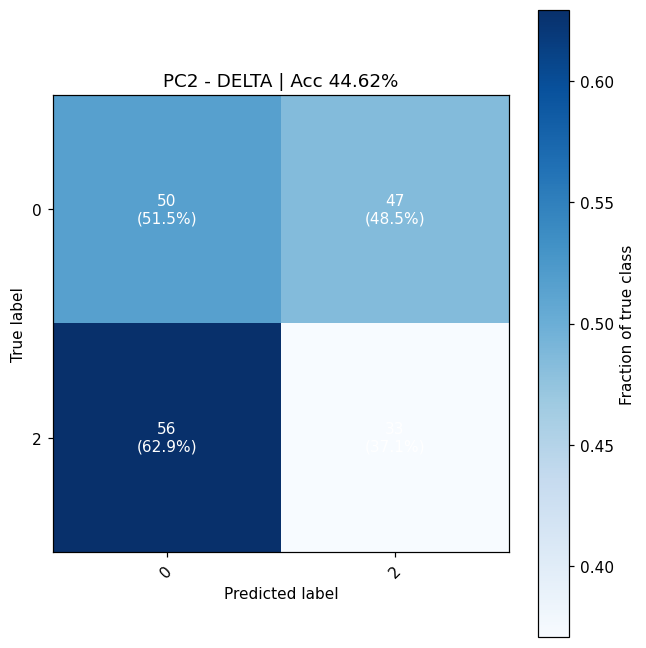

In [153]:
import os, sys

libstdc = os.path.join(os.environ["CONDA_PREFIX"], "lib", "libstdc++.so.6")
os.environ["LD_PRELOAD"] = libstdc   # exported to all child procs
print("Pre‑loading:", libstdc)

sys.path.append('/project/3022057.01/POM/POM_Analysis/')

import regression_analysis_utils

from importlib import reload

# after editing regression.py:
reload(regression_analysis_utils)

from regression_analysis_utils import regression_analysis

target_cols = [
    'Up3OfTotal', 'Up3OfBradySum', 'Up3OfRigiditySum',
    'Up3OfRestTremAmpSum', 'Up3OfActionTremorSum',
    'Up3OfPIGDSum', 'MoCASum', 'CognitiveComposite',
    'AsymmetryIndexRiLe.WeightedBradyRig',
    'AsymmetryIndexArmLeg.WeightedBradyRig'
]

label_config = [[1],[2],[1,2],[1,2,3],[1,2,3,4]]
# quant_all = [None,.33]
# label_config = [[1,2,3,4]]
latent = ["pca"]
for lcfg in label_config:
    print(lcfg)
    for lat in latent:
        regression_analysis(
            df            = sub_df,
            covs          = partial_covs,
            target_cols   = target_cols,

            target_latent = lat,      # "raw", "pca", "plsc", or "lda"
            n_components  = 2,
            deconf        = True,

            con_cols      = ["age","motion"],
            cat_cols      = ["sex"],
            per_week=True,
            label_filter  = lcfg,

            n_splits      = 5,
            alpha         = {'C':1e-1},        # fixed Ridge penalty (set None to tune later)
            random_state  = 0,
            metric = metric,
            stratify = False,
            quantile = .25,
            global_pre=False,
            normalize=False,
            model_key="svc_l1"
        )

### Analyze Clinical Variables

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from pathlib import Path
from scipy.stats import entropy, iqr, differential_entropy

def regression_analysis(
        df,
        covs,
        target_cols,
        *,
        mode="pca",
        n_components=3,
        deconf=False,
        con_cols=None,
        cat_cols=None,
        per_week=True,
        group_col="group_numeric_label",
        subject_col="Subject",
        tp_col="TimepointNr",
        label_filter=None,
        tp0=0,
        tp1=1,
        figsize=(10, 4),
        dpi=110,
        save_dir=None,
):

    # ------------------------------------------------------------------
    # 0) start with “keep everything”
    # ------------------------------------------------------------------
    keep_mask = np.ones(len(df), dtype=bool)

    # ------------------------------------------------------------------
    # 1) label filter  (does NOT shrink df yet!)
    # ------------------------------------------------------------------
    if label_filter is not None:
        groups  = (label_filter if any(isinstance(el, (list, tuple))
                                       for el in label_filter)
                   else [[lbl] for lbl in label_filter])
        mapping = {old: new for new, grp in enumerate(groups) for old in grp}

        mask_lbl = df[group_col].isin(mapping)
        keep_mask &= mask_lbl.values

    # ------------------------------------------------------------------
    # 2) literal “na/NAN/…” → np.nan
    # ------------------------------------------------------------------
    df = df.replace(r"(?i)^\s*na[n]?\s*$", np.nan, regex=True)

    # ------------------------------------------------------------------
    # 3) subject‑level QC
    # ------------------------------------------------------------------
    con_cols = con_cols or []
    cat_cols = cat_cols or []

    mask_subj = np.zeros(len(df), dtype=bool)   # will be True for good rows
    for subj, grp in df.groupby(subject_col):
        ok  =  set(grp[tp_col]) == {tp0, tp1}
        ok &= not grp[target_cols].isna().any().any()
        ok &= not pd.isna(grp.loc[grp[tp_col]==tp1, "WeeksToFollowUp"]).any()
        if deconf:
            ok &= not grp[con_cols + cat_cols].isna().any().any()
        if ok:
            mask_subj[grp.index] = True

    keep_mask &= mask_subj

    # ------------------------------------------------------------------
    # 4) apply the single, final mask
    # ------------------------------------------------------------------
    df   = df[keep_mask].reset_index(drop=True)
    covs = covs[keep_mask]                 # rows still match 1‑to‑1

    print(f"Kept {len(df.groupby(subject_col))} subjects  "
          f"({df.shape[0]} rows),  covs shape = {covs.shape}")

    if df.empty:
        print("No subjects left after filtering."); return

    # ------------------------------------------------------------------
    # 5)  remap group labels now that df is final
    # ------------------------------------------------------------------
    if label_filter is not None:
        df[group_col] = df[group_col].map(mapping).astype(int)

    # ------------------------------------------------------------------
    # 6) baseline (TP0) views for downstream code
    # ------------------------------------------------------------------
    mask_tp0  = (df[tp_col] == tp0)
    covs_tp0  = covs[mask_tp0.values]              # (n_subj, n_ch, n_ch)
    # subs_tp0  = df.loc[mask_tp0, subject_col].values

    # ---------- 2) build feature matrix (optional deconf) -------------
    X_all_raw = df[target_cols].astype(float).values
    if deconf:
        con_df = df[con_cols] if con_cols else pd.DataFrame(index=df.index)
        cat_df = df[cat_cols] if cat_cols else pd.DataFrame(index=df.index)
        mask0  = df[tp_col] == tp0
        X0_dc, X_all = deconfound(
            X_all_raw[mask0],
            con_df[mask0], cat_df[mask0],
            X_test=X_all_raw,
            con_confounder_test=con_df, cat_confounder_test=cat_df,
            output_path=None
        )
    else:
        X_all = X_all_raw
        X0_dc = X_all[df[tp_col]==tp0]

    # ---------- 3) dimensionality choice ------------------------------
    if mode.lower() == "pca":
        scaler = StandardScaler().fit(X0_dc)
        max_k  = min(n_components, X0_dc.shape[0], len(target_cols))
        pca    = PCA(n_components=max_k).fit(scaler.transform(X0_dc))
        feats  = pca.transform(scaler.transform(X_all))
        names  = [f"PC{i+1}" for i in range(max_k)]
        loadings = pca.components_
        extra_info = {"var_exp": pca.explained_variance_ratio_}
    elif mode.lower() == "lda":
        y0 = df.loc[df[tp_col]==tp0, group_col].astype(int).values
        scaler = StandardScaler().fit(X0_dc)
        n_cls  = len(np.unique(y0))
        max_k  = min(n_components, n_cls-1, len(target_cols))
        lda    = LDA(n_components=max_k).fit(scaler.transform(X0_dc), y0)
        feats  = lda.transform(scaler.transform(X_all))
        names  = [f"LD{i+1}" for i in range(max_k)]
        loadings = lda.scalings_[:, :max_k]
        extra_info = {}
    elif mode.lower() == "raw":
        feats  = X_all
        names  = target_cols
        loadings = None
    else:
        raise ValueError('mode must be "pca", "lda", or "raw"')

    # attach features to df
    for i, nm in enumerate(names):
        df[nm] = feats[:, i]

    # ---------- 4) plotting prep --------------------------------------
    subj_order = (df.drop_duplicates(subject_col)
                    .sort_values([group_col, subject_col])[subject_col]
                    .tolist())
    subj_to_x  = {s:i for i,s in enumerate(subj_order)}
    if save_dir:
        save_dir = Path(save_dir); save_dir.mkdir(parents=True, exist_ok=True)

    # ---------- 5) plot loop ------------------------------------------
    for i, nm in enumerate(names):
        tp0_rows = df[df[tp_col] == tp0]
        tp1_rows = df[df[tp_col] == tp1]

        x_vals   = [subj_to_x[s] for s in tp0_rows[subject_col]]
        g_vals   = tp0_rows[group_col].values

        y0 = tp0_rows[nm].values
        y1 = tp1_rows[nm].values
        weeks = tp1_rows["WeeksToFollowUp"].astype(float).values
        delta = (y1 - y0) / weeks if per_week else (y1 - y0)
        tag   = "/week" if per_week else ""

        # helper to compute spread 
        # 1) histogram version: fast, bins chosen by Freedman–Diaconis rule
        def spread(y, bins="fd"):
            if np.nanstd(y, ddof=1) < 1e-10:
                return 0
            y = (y - np.nanmean(y)) / np.nanstd(y, ddof=1)    # z‑score (scale‑free)
            # return differential_entropy(y, base=np.e)                 # nats
            return iqr(y)                 # nats

        # --- coefficient / loading bar‑plot --------------------------
        if loadings is not None:
            bar_vals = loadings[i] if mode.lower() == "pca" else loadings[:, i]

            plt.figure(figsize=(8, 6), dpi=dpi)
            plt.barh(target_cols, bar_vals, color="steelblue")
            plt.axvline(0, color="grey", lw=1)
            title = nm
            if mode.lower() == "pca":
                title += f" • var exp: {extra_info['var_exp'][i]:.1%}"
            plt.title(title)
            plt.tight_layout()
            if save_dir: plt.savefig(save_dir / f"load_{nm}.png"); plt.close()
            else:        plt.show()

        # ----- TP0 ----------------------------------------------------
        plt.figure(figsize=figsize, dpi=dpi)
        plt.scatter(x_vals, y0, c=g_vals, cmap="tab10", s=40)
        plt.title(f"{nm}-TP0  •  entropy={spread(y0):.2g}")
        plt.ylabel(nm)
        plt.xticks(np.arange(len(subj_order)), rotation=90, fontsize=7)
        plt.tight_layout()
        if save_dir: plt.savefig(save_dir / f"{nm}_TP0.png"); plt.close()
        else:        plt.show()

        # ----- TP1 ----------------------------------------------------
        plt.figure(figsize=figsize, dpi=dpi)
        plt.scatter(x_vals, y1, c=g_vals, cmap="tab10", marker="^", s=40)
        plt.title(f"{nm}-TP1  •  entropy={spread(y1):.2g}")
        plt.ylabel(nm)
        plt.xticks(np.arange(len(subj_order)), rotation=90, fontsize=7)
        plt.tight_layout()
        if save_dir: plt.savefig(save_dir / f"{nm}_TP1.png"); plt.close()
        else:        plt.show()

        # ----- Δ ------------------------------------------------------
        plt.figure(figsize=figsize, dpi=dpi)
        plt.scatter(x_vals, delta, c=g_vals, cmap="tab10", s=40)
        plt.axhline(0, ls="--", color="0.5")
        plt.title(f"Δ {nm}{tag} (TP1-TP0)  •  entropy={spread(delta):.2g}")
        plt.ylabel(f"Change {tag}")
        plt.xticks(np.arange(len(subj_order)), rotation=90, fontsize=7)
        plt.tight_layout()
        if save_dir: plt.savefig(save_dir / f"{nm}_delta.png"); plt.close()
        else:        plt.show()


target_cols = [
    'Up3OfTotal', 'Up3OfBradySum', 'Up3OfRigiditySum',
    'Up3OfRestTremAmpSum', 'Up3OfActionTremorSum',
    'Up3OfPIGDSum', 'MoCASum', 'CognitiveComposite',
    'AsymmetryIndexRiLe.WeightedBradyRig',
    'AsymmetryIndexArmLeg.WeightedBradyRig'
]

# PCA with de‑confounding
regression_analysis(
    df           = sub_df,
    covs         = partial_covs,
    target_cols  = target_cols,
    mode         = "pca",
    deconf       = True,
    con_cols     = ["age","motion"],
    cat_cols     = ["sex"],
    n_components = 2,
    per_week=True,
    label_filter=[1,2,3,4]
)

### Regression Phenotype Prediction

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSCanonical
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
from sklearn.kernel_ridge import KernelRidge
from pathlib import Path

import sys
sys.path.append('/project/3022057.01/IFA/utils')

import regression
import tangent
from importlib import reload

# after editing regression.py:
reload(regression)
reload(tangent)

# now pull in your updated functions
from regression import deconfound
from tangent    import tangent_transform


from skopt import gp_minimize
from skopt.space import Real
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score

def preprocess(tr_idx,te_idx, cvs,targ,con_conf,cat_conf, deconf=True,metric='riemann'):
    cvs_tr = cvs[tr_idx]
    cvs_te = cvs[te_idx]

    # Tangent Project
    X_tr_tan, X_te_tan, _ = tangent_transform(cvs_tr, cvs_te, metric=metric)

    # deconfound
    if deconf:
        X_tr, X_te = deconfound(
            X_tr_tan,
            con_conf.iloc[tr_idx], cat_conf.iloc[tr_idx],
            X_test=X_te_tan,
            con_confounder_test=con_conf.iloc[te_idx],
            cat_confounder_test=cat_conf.iloc[te_idx]
        )
        # X_tr, X_te = X_tr_tan, X_te_tan
    else:
        X_tr, X_te = X_tr_tan, X_te_tan
        
    # scaler = StandardScaler().fit(X_tr)
    # X_tr = scaler.transform(X_tr)
    # X_te = scaler.transform(X_te)
    
    targ_tr = targ.iloc[tr_idx]
    targ_te = targ.iloc[te_idx]

    if deconf:
        Y_tr, Y_te = deconfound(
            targ_tr,
            con_conf.iloc[tr_idx], cat_conf.iloc[tr_idx],
            X_test=targ_te,
            con_confounder_test=con_conf.iloc[te_idx],
            cat_confounder_test=cat_conf.iloc[te_idx],
            output_path=None
        )
    else:
        Y_tr = targ_tr  
        Y_te = targ_te

    return  X_tr, X_te, Y_tr, Y_te

def tune_elastic_net(cvs, targ, con_conf, cat_conf, groups, deconf=True, metric='riemann', n_splits=5, n_calls=20, random_state=0):    
    def objective(params):
        alpha, l1_ratio = params
        cv = GroupKFold(n_splits=n_splits)
        fold_scores = []

        for tr_idx, val_idx in cv.split(np.arange(len(targ)), targ, groups):
            # run your entire preprocess pipeline for this fold
            X_tr, X_val, Y_tr, Y_val = preprocess(
                tr_idx, val_idx, cvs, targ,
                con_conf, cat_conf,
                deconf=deconf, metric=metric
            )
            # fit & score
            en = ElasticNet(alpha=alpha, l1_ratio=l1_ratio,
                            max_iter=5000, tol=1e-4)
            en.fit(X_tr, Y_tr)
            preds = en.predict(X_val)
            fold_scores.append(r2_score(Y_val, preds))
        # minimize negative mean R²
        return -np.mean(fold_scores)

    # search space
    space = [
        Real(1e-4, 1e2, prior="log-uniform", name="alpha"),
        Real(1e-3,   1.0, prior="uniform",     name="l1_ratio")
    ]

    res = gp_minimize(
        objective,
        space,
        n_calls=n_calls,
        n_initial_points=5,
        random_state=random_state,
        acq_optimizer="lbfgs",
        verbose=False
    )

    return res.x  # [best_alpha, best_l1_ratio]

def tangent_regression(
    covs,
    subs,
    df,
    target_cols,
    con_df=None,
    cat_df=None,
    metric="riemann",
    deconf=False,
    label_filter=None,
    one_time_point = True,
    n_splits=4
):
    # ————————————— (0) timepoint filter —————————————
    if one_time_point:
        tp0_mask = df["TimepointNr"] == 0
        covs      = np.asarray(covs)[tp0_mask]
        subs      = np.asarray(subs)[tp0_mask]
        df        = df.loc[tp0_mask].reset_index(drop=True)
        if con_df is not None:
            con_df = con_df.loc[tp0_mask].reset_index(drop=True)
        if cat_df is not None:
            cat_df = cat_df.loc[tp0_mask].reset_index(drop=True)


    y_df = df[target_cols]
    # ——— (A) filter by label if requested ———
    if label_filter is not None:
        # build mapping: groups → new labels 0,1,2…
        groups = label_filter if isinstance(label_filter, (list,tuple)) else [label_filter]
        mapping = {}
        for new_lbl, grp in enumerate(groups):
            for old in np.atleast_1d(grp):
                mapping[int(old)] = new_lbl
        # assume one of your columns in y_df is the “label” column; e.g. y_df['label']
        lbls = df['group_numeric_label'].astype(int).values
        keep = np.array([l in mapping for l in lbls])
        covs       = covs[keep]
        subs       = np.asarray(subs)[keep]
        y_df       = y_df.loc[keep].reset_index(drop=True)
        if con_df is not None: con_df = con_df.loc[keep].reset_index(drop=True)
        if cat_df is not None: cat_df = cat_df.loc[keep].reset_index(drop=True)

    # (A) Drop invalid rows
    n_subjects = y_df.shape[0]
    dummy_idx = np.arange(n_subjects)

    con_placeholder = con_df if con_df is not None else pd.DataFrame(index=y_df.index)
    cat_placeholder = cat_df if cat_df is not None else pd.DataFrame(index=y_df.index)

    mask_tr, _, y_train_clean, _, \
      con_train_clean, cat_train_clean, _, _, _, _ = drop_invalid_rows(
        y_df, y_df,
        con_placeholder, cat_placeholder,
        con_placeholder, cat_placeholder,
        dummy_idx, dummy_idx
    )

    covs_filt = np.asarray(covs)[mask_tr]
    sub_ID_filt = subs[mask_tr]
    y_filt = y_train_clean.reset_index(drop=True)
    con_filt = con_train_clean.reset_index(drop=True) if con_df is not None else None
    cat_filt = cat_train_clean.reset_index(drop=True) if cat_df is not None else None
    n_kept = covs_filt.shape[0]

    # (A.2) Group splits: leave-one-group-out by subject
    # logo = LeaveOneGroupOut()
    # splits = list(logo.split(
    #     X=np.zeros(n_kept),
    #     y=y_filt.values,
    #     groups=sub_ID_filt
    # ))

    gkf = GroupKFold(n_splits=n_splits)  
    splits = list(gkf.split(
        X=np.zeros(len(sub_ID_filt)),
        y=y_filt.values,
        groups=sub_ID_filt
        ))

    # optional sanity check
    for fold, (train_idx, test_idx) in enumerate(splits):
        overlap = set(sub_ID_filt[train_idx]) & set(sub_ID_filt[test_idx])
        print(f"Fold {fold}: {'OK' if not overlap else f'Overlap: {overlap}'}")

    # (C) process one fold
    def _process_fold(train_idx, test_idx):
        # tangent transform
    
        X_tr, X_te, Y_tr, Y_te = preprocess(
            train_idx, test_idx, covs_filt, y_filt,
            con_filt, cat_filt,
            deconf=deconf, metric=metric
        )

        covs_tr = covs_filt[train_idx]
        groups_tr = sub_ID_filt[train_idx]
        
        Y_tr = np.asarray(Y_tr)
        Y_te = np.asarray(Y_te)
        Y_te_pred = np.zeros_like(Y_te)

        for j in range(Y_tr.shape[1]):
            model_j = Ridge(alpha=10).fit(X_tr, Y_tr[:,j])
            # model_j =ElasticNet(alpha=1,l1_ratio=0.01).fit(X_tr, Y_tr[:,j])

            # best_alpha, best_l1 = tune_elastic_net(covs_tr, y_filt.iloc[train_idx,j], con_filt.iloc[train_idx], cat_filt.iloc[train_idx], groups_tr, deconf=deconf, metric=metric, n_splits=n_splits, n_calls=20, random_state=0)
            # print(f"Latent {j}: α={best_alpha:.4g}, l1_ratio={best_l1:.3f}")

            # model_j = ElasticNet(alpha=best_alpha,l1_ratio=best_l1).fit(X_tr, Y_tr[:,j])

            # pred_tr_j = model_j.predict(X_tr)
            # slope_j = (pred_tr_j @ Y_tr[:, j]) / (pred_tr_j @ pred_tr_j + 1e-8)
            # Y_te_pred[:, j] = slope_j * model_j.predict(X_te)
            Y_te_pred[:, j] = model_j.predict(X_te)
        return test_idx, Y_te, Y_te_pred

    # parallel execution
    results = Parallel(n_jobs=-1)(
        delayed(_process_fold)(ti, te)
        for ti, te in splits
    )

    # (D) collect
    for i, (test_idx, Y_true, Y_pred) in enumerate(results):
        if i == 0:
            n_targets = Y_true.shape[1]
            y_true = np.zeros((n_kept, n_targets))
            y_pred = np.zeros((n_kept, n_targets))
        y_true[test_idx] = Y_true
        y_pred[test_idx] = Y_pred


    metrics = {}

    for j in range(n_targets):
        # 2) True vs Pred scatter
        true_j = y_true[:, j]
        pred_j = y_pred[:, j]
        r_j = pearsonr(true_j, pred_j)[0]
        r2_j = r2_score(true_j, pred_j)
        metrics[target_cols[j]] = {"pearson_r": r_j, "r2": r2_j}

        plt.figure(figsize=(5, 5))
        plt.scatter(true_j, pred_j, alpha=0.6)
        plt.xlabel(f"True Value {j+1}")
        plt.ylabel(f"Predicted Value {j+1}")
        plt.title(f"{target_cols[j]}: r={r_j:.3f}, R²={r2_j:.3f}")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return y_true, y_pred, metrics

target_cols = [
    'Up3OfTotal', 'Up3OfBradySum', 'Up3OfRigiditySum',
    'Up3OfRestTremAmpSum', 'Up3OfActionTremorSum',
    'Up3OfPIGDSum', 'MoCASum', 'CognitiveComposite',
    'AsymmetryIndexRiLe.WeightedBradyRig',
    'AsymmetryIndexArmLeg.WeightedBradyRig'
]

print(set(sub_df["group_numeric_label"]))
y_true_latents, y_pred_latents, metrics = tangent_regression(
    partial_covs,
    sub_ID,
    sub_df,
    target_cols,
    con_df=con_confs,
    cat_df=cat_confs,
    metric=metric,
    deconf=True,
    label_filter=[1,2,3,4],
    one_time_point = True,
    n_splits=5
)

### Regression Follow Up Phenotype Prediction

In [ ]:
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from sklearn.model_selection import GroupKFold, LeaveOneOut
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
import matplotlib.pyplot as plt


def delta_regression_global_ref(
        df          : pd.DataFrame,
        covs        : np.ndarray,
        target_cols : list[str],
        *,
        metric      : str  = "riemann",
        con_cols    : list[str] | None = None,   # e.g. ["age"]
        cat_cols    : list[str] | None = None,   # e.g. ["sex"]
        outer_split : str  = "kfold",            # "kfold" | "loo"
        n_splits    : int  = 5,
        alpha_ridge : float= 1.0
):
    """Predict Δ phenotype (TP1–TP0) from baseline connectivity + confounds
       using the *same* tangent_transform(cvs_tr, cvs_te) you already use."""

    # --------------------------------------------------------
    # 0) keep subjects that have both TP0 & TP1
    # --------------------------------------------------------
    ok_subs = df.groupby("Subject")["TimepointNr"].apply(lambda tp: {0,1}.issubset(tp))
    df      = df[df["Subject"].isin(ok_subs[ok_subs].index)].reset_index(drop=True)
    covs    = covs[df.index]                       # align ndarray with filtered df

    # --------------------------------------------------------
    # 1) build subject‑level table: baseline cov, ΔY, confounds
    # --------------------------------------------------------
    rows = []
    for subj, grp in df.groupby("Subject"):
        base = grp[grp["TimepointNr"]==0].iloc[0]
        foll = grp[grp["TimepointNr"]==1].iloc[0]
        
        delta_y = (foll[target_cols] - base[target_cols]).astype(float).values

        if con_cols:
            con_confs = base[con_cols].copy()           # start from baseline values
            if "WeeksToFollowUp" in con_cols:         # overwrite with follow‑up value
                con_confs["WeeksToFollowUp"] = foll["WeeksToFollowUp"]
        else:
            con_confs = None
        
        cat_confs = base[cat_cols] if cat_cols else None
        
        bad = (
            np.isnan(delta_y).any() or
            (con_confs is not None and pd.isna(con_confs).any()) or
            (cat_confs is not None and pd.isna(cat_confs).any())
        )
        if bad:
            continue          # skip this subject entirely

        rows.append(dict(
            subj      = subj,
            idx_cov   = base.name,                         # index into `covs`
            delta_y   = (foll[target_cols]).astype(float).values,
            con       = con_confs,
            cat       = cat_confs
        ))

    # subj_df = pd.DataFrame(rows).replace(r'(?i)^\s*(na|nan)\s*$', np.nan, regex=True).dropna()
    subj_df = pd.DataFrame(rows)

    print(subj_df.head())
    # -----------------------------------------------------------------
    # 2) outer‑CV splitter  (each subj = 1 sample)
    # -----------------------------------------------------------------
    X_cov   = covs[subj_df["idx_cov"].to_numpy()]          # (n_subj, n_ch, n_ch)
    Y       = np.vstack(subj_df["delta_y"].values)         # (n_subj, q)
    groups  = subj_df["subj"].to_numpy()
    print(Y.shape)
    if outer_split.lower() == "loo":
        splitter = LeaveOneOut().split(X_cov, groups=groups)
    else:
        splitter = GroupKFold(n_splits=n_splits).split(X_cov, groups=groups)

    # -----------------------------------------------------------------
    # 3) training / testing per fold
    # -----------------------------------------------------------------
    def _fold(train_idx, test_idx):
        cvs_tr, cvs_te = X_cov[train_idx], X_cov[test_idx]
        # ---- tangent projection (global reference = train mean)
        X_tr_tan, X_te_tan, _ = tangent_transform(cvs_tr, cvs_te, metric=metric)

        # ---- append confounds
        if con_cols or cat_cols:
            con_tr = pd.DataFrame([subj_df.iloc[i]["con"] for i in train_idx])
            con_te = pd.DataFrame([subj_df.iloc[i]["con"] for i in test_idx])
            cat_tr = pd.DataFrame([subj_df.iloc[i]["cat"] for i in train_idx])
            cat_te = pd.DataFrame([subj_df.iloc[i]["cat"] for i in test_idx])
            X_tr, X_te = add_confounds(X_tr_tan, con_tr, cat_tr,
                                       X_test=X_te_tan,
                                       con_confounder_test=con_te,
                                       cat_confounder_test=cat_te)
        else:
            X_tr, X_te = X_tr_tan, X_te_tan
        print(X_tr_tan.shape, X_te_tan.shape, X_tr.shape,X_te.shape)
        scaler = StandardScaler().fit(X_tr)
        X_tr = scaler.transform(X_tr)
        X_te = scaler.transform(X_te)
        Y_tr, Y_te = Y[train_idx], Y[test_idx]
        mdl = Ridge(alpha=alpha_ridge).fit(X_tr, Y_tr)
        return test_idx, Y_te, mdl.predict(X_te)

    fold_out = Parallel(n_jobs=-1)(delayed(_fold)(tr, te) for tr, te in splitter)

    # -----------------------------------------------------------------
    # 4) collect predictions
    # -----------------------------------------------------------------
    Y_true = np.zeros_like(Y);  Y_pred = np.zeros_like(Y)
    for te_idx, y_t, y_p in fold_out:
        Y_true[te_idx] = y_t
        Y_pred[te_idx] = y_p

    # -----------------------------------------------------------------
    # 5) metrics & quick plot
    # -----------------------------------------------------------------
    metrics = {}
    for j, col in enumerate(target_cols):
        r  = pearsonr(Y_true[:,j], Y_pred[:,j])[0]
        r2 = r2_score(Y_true[:,j], Y_pred[:,j])
        metrics[col] = dict(pearson_r=r, r2=r2)

        plt.figure(figsize=(4,4))
        plt.scatter(Y_true[:,j], Y_pred[:,j], alpha=.6)
        plt.axhline(0, ls="--"); plt.axvline(0, ls="--")
        plt.xlabel(f"Δ {col} (true)"); plt.ylabel(f"Δ {col} (pred)")
        plt.title(f"{col}:  r={r:.3f}  R²={r2:.3f}")
        plt.tight_layout(); plt.show()

    return Y_true, Y_pred, metrics

target_cols = [
    'Up3OfTotal', 'Up3OfBradySum', 'Up3OfRigiditySum',
    'Up3OfRestTremAmpSum', 'Up3OfActionTremorSum',
    'Up3OfPIGDSum', 'MoCASum', 'CognitiveComposite',
    'AsymmetryIndexRiLe.WeightedBradyRig',
    'AsymmetryIndexArmLeg.WeightedBradyRig'
]

y_true, y_pred, metrics = delta_regression_global_ref(
    sub_df,
    partial_covs,
    target_cols,
    metric      = metric,
    con_cols    = ["age","WeeksToFollowUp"],        # motion intentionally omitted
    cat_cols    = ["sex"],
    outer_split = "kfold",
    n_splits    = 4,
    alpha_ridge = 1.0
)

### Regression ...

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSCanonical
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
from sklearn.kernel_ridge import KernelRidge
from pathlib import Path

import sys
sys.path.append('/project/3022057.01/IFA/utils')

import regression
import tangent
from importlib import reload

# after editing regression.py:
reload(regression)
reload(tangent)

# now pull in your updated functions
from regression import deconfound
from tangent    import tangent_transform


from skopt import gp_minimize
from skopt.space import Real
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score

def tune_elastic_net(X, y, groups, n_calls=20):
    """
    Bayesian‐optimize alpha and l1_ratio via GP,
    minimizing negative mean R² over a 5‐fold GroupKFold.
    """
    def objective(params):
        alpha, l1_ratio = params
        inner = GroupKFold(n_splits=5)
        scores = []
        for tr_i, val_i in inner.split(X, y, groups):
            en = ElasticNet(alpha=alpha, l1_ratio=l1_ratio,
                            max_iter=5000, tol=1e-4)
            en.fit(X[tr_i], y[tr_i])
            pred = en.predict(X[val_i])
            scores.append(r2_score(y[val_i], pred))
        return -np.mean(scores)

    space = [
        Real(1e-4, 1e2, prior="log-uniform", name="alpha"),
        Real(0.0, 1.0,   prior="uniform",     name="l1_ratio")
    ]
    res = gp_minimize(
        objective,
        space,
        n_calls=n_calls,
        n_initial_points=5,
        random_state=0,
        acq_optimizer="lbfgs"
    )
    return res.x  # [best_alpha, best_l1_ratio]


def loo_tangent_pls_regression(
    covs,
    subs,
    df,
    target_cols,
    con_df=None,
    cat_df=None,
    metric="riemann",
    deconf=False,
    use_pls=False,
    label_filter=None,
    outfolder = "TEST"
):
    """
    Runs leave-one-subject-out (or grouped) CV with tangent transform.
    If use_pls=False: PCA on Y + Ridge per latent.
    If use_pls=True: Canonical PLS, predicting latent scores.

    Returns:
        y_true_latents: array (n_samples, n_latents)
        y_pred_latents: array (n_samples, n_latents)
        metrics: dict of pearson_r and R^2 per latent
    """
    # ————————————— (0) timepoint filter —————————————
    tp0_mask = df["TimepointNr"] == 0
    covs      = np.asarray(covs)[tp0_mask]
    subs      = np.asarray(subs)[tp0_mask]
    df        = df.loc[tp0_mask].reset_index(drop=True)
    if con_df is not None:
        con_df = con_df.loc[tp0_mask].reset_index(drop=True)
    if cat_df is not None:
        cat_df = cat_df.loc[tp0_mask].reset_index(drop=True)


    y_df = df[target_cols]
    # ——— (A) filter by label if requested ———
    if label_filter is not None:
        # build mapping: groups → new labels 0,1,2…
        groups = label_filter if isinstance(label_filter, (list,tuple)) else [label_filter]
        mapping = {}
        for new_lbl, grp in enumerate(groups):
            for old in np.atleast_1d(grp):
                mapping[int(old)] = new_lbl
        # assume one of your columns in y_df is the “label” column; e.g. y_df['label']
        lbls = df['group_numeric_label'].astype(int).values
        keep = np.array([l in mapping for l in lbls])
        covs       = covs[keep]
        subs       = np.asarray(subs)[keep]
        y_df       = y_df.loc[keep].reset_index(drop=True)
        if con_df is not None: con_df = con_df.loc[keep].reset_index(drop=True)
        if cat_df is not None: cat_df = cat_df.loc[keep].reset_index(drop=True)

    # (A) Drop invalid rows
    n_subjects = y_df.shape[0]
    dummy_idx = np.arange(n_subjects)

    con_placeholder = con_df if con_df is not None else pd.DataFrame(index=y_df.index)
    cat_placeholder = cat_df if cat_df is not None else pd.DataFrame(index=y_df.index)

    mask_tr, _, y_train_clean, _, \
      con_train_clean, cat_train_clean, _, _, _, _ = drop_invalid_rows(
        y_df, y_df,
        con_placeholder, cat_placeholder,
        con_placeholder, cat_placeholder,
        dummy_idx, dummy_idx
    )

    covs_filt = np.asarray(covs)[mask_tr]
    sub_ID_filt = subs[mask_tr]
    y_filt = y_train_clean.reset_index(drop=True)
    con_filt = con_train_clean.reset_index(drop=True) if con_df is not None else None
    cat_filt = cat_train_clean.reset_index(drop=True) if cat_df is not None else None
    n_kept = covs_filt.shape[0]

    # (A.2) Group splits: leave-one-group-out by subject
    # logo = LeaveOneGroupOut()
    # splits = list(logo.split(
    #     X=np.zeros(n_kept),
    #     y=y_filt.values,
    #     groups=sub_ID_filt
    # ))

    gkf = GroupKFold(n_splits=4)  
    splits = list(gkf.split(
        X=np.zeros(len(sub_ID_filt)),
        y=y_filt.values,
        groups=sub_ID_filt
        ))

    # optional sanity check
    for fold, (train_idx, test_idx) in enumerate(splits):
        overlap = set(sub_ID_filt[train_idx]) & set(sub_ID_filt[test_idx])
        print(f"Fold {fold}: {'OK' if not overlap else f'Overlap: {overlap}'}")

    # (C) process one fold
    def _process_fold(train_idx, test_idx):
        # tangent transform
        covs_tr = covs_filt[train_idx]
        covs_te = covs_filt[test_idx]
        X_tr_tan, X_te_tan, _ = tangent_transform(
            covs_tr, covs_te, metric=metric
        )
        # scaler = StandardScaler().fit(X_tr_tan)
        # X_tr_tan = scaler.transform(X_tr_tan)
        # X_te_tan = scaler.transform(X_te_tan)

        # deconfound
        if deconf:
            X_tr, X_te = deconfound(
                X_tr_tan,
                con_filt.iloc[train_idx], cat_filt.iloc[train_idx],
                X_test=X_te_tan,
                con_confounder_test=con_filt.iloc[test_idx],
                cat_confounder_test=cat_filt.iloc[test_idx]
            )
            # X_tr, X_te = add_confounds(X_tr_tan,
            #     con_filt.iloc[train_idx], cat_filt.iloc[train_idx],
            #     X_test=X_te_tan,
            #     con_confounder_test=con_filt.iloc[test_idx],
            #     cat_confounder_test=cat_filt.iloc[test_idx])
            # X_tr, X_te = X_tr_tan, X_te_tan
        else:
            X_tr, X_te = X_tr_tan, X_te_tan
        
        # stds = X_tr.std(axis=0)
        # pct = 10  # bottom 5%
        # thresh = np.percentile(stds, pct)
        # low_var = stds < thresh
        # X_tr[:, low_var] = 0
        # X_te[:, low_var] = 0

        # print("Mean of train features", np.mean(np.mean(X_tr,axis=0)), "Std of train features", np.mean(np.std(X_tr,axis=0)))
        # print("Mean of test features", np.mean(np.mean(X_te,axis=0)), "Std of test features", np.mean(np.std(X_te,axis=0)))

        # # compute per‐feature mean and std for the training set
        # feat_idx   = np.arange(X_tr.shape[1])
        # train_means = X_tr.mean(axis=0)
        # train_stds  = X_tr.std(axis=0)

        # outdir = Path("/project/3022057.01/POM/Visualize") / f"fold_{train_idx[0]}"
        # outdir.mkdir(parents=True, exist_ok=True)

        # # scatter of feature means
        # fig = plt.figure(figsize=(10,4))
        # plt.scatter(feat_idx, train_means, alpha=0.7)
        # plt.xlabel('Feature index')
        # plt.ylabel('Mean of train features')
        # plt.title('Per‐Feature Means')
        # fig.savefig(outdir / "train_means.png")
        # plt.close(fig)

        # # scatter of feature stds
        # fig = plt.figure(figsize=(10,4))
        # plt.scatter(feat_idx, train_stds, alpha=0.7)
        # plt.xlabel('Feature index')
        # plt.ylabel('Std deviation of train features')
        # plt.title('Per‐Feature Standard Deviations')
        # fig.savefig(outdir / "train_stds.png")
        # plt.close(fig)

        # test_means = X_te.mean(axis=0)
        # test_stds  = X_te.std(axis=0)

        # fig = plt.figure(figsize=(10,4))
        # plt.scatter(feat_idx, test_means, alpha=0.7)
        # plt.xlabel('Feature index')
        # plt.ylabel('Mean of test features')
        # plt.title('Per‐Feature Means (Test)')
        # fig.savefig(outdir / "test_means.png")
        # plt.close(fig)

        # fig = plt.figure(figsize=(10,4))
        # plt.scatter(feat_idx, test_stds, alpha=0.7)
        # plt.xlabel('Feature index')
        # plt.ylabel('Std deviation of test features')
        # plt.title('Per‐Feature Standard Deviations (Test)')
        # plt.tight_layout()
        # fig.savefig(outdir / "test_stds.png")
        # plt.close(fig)        
        if deconf:
            # # label_con_train = con_confounder_train.drop(columns=["motion"])
            # # label_con_test  = con_confounder_test .drop(columns=["motion"])
            Y_tr_raw = y_filt.iloc[train_idx]   # keep column names!
            Y_te_raw = y_filt.iloc[test_idx]

            Y_tr_raw, Y_te_raw = deconfound(
                Y_tr_raw,
                con_filt.iloc[train_idx], cat_filt.iloc[train_idx],
                X_test=Y_te_raw,
                con_confounder_test=con_filt.iloc[test_idx],
                cat_confounder_test=cat_filt.iloc[test_idx],
                output_path=None
            )
            # Y_tr_raw = y_filt.iloc[train_idx]  
            # Y_te_raw = y_filt.iloc[test_idx]

        else:
            Y_tr_raw = y_filt.iloc[train_idx]  
            Y_te_raw = y_filt.iloc[test_idx]

        scaler = StandardScaler().fit(Y_tr_raw)
        Y_tr = scaler.transform(Y_tr_raw)
        Y_te = scaler.transform(Y_te_raw)

        if not use_pls:
            # PCA + Ridge per latent
            pca = PCA(n_components=Y_tr.shape[1]).fit(Y_tr)
            Y_tr_lat = pca.transform(Y_tr)
            Y_te_lat = pca.transform(Y_te)

            # Y_tr_lat = 1/(1 + np.exp(-Y_tr_lat))
            # Y_te_lat =  1/(1 + np.exp(-Y_te_lat))

            Y_te_pred = np.zeros_like(Y_te_lat)
            groups_tr = sub_ID_filt[train_idx]

            for j in range(Y_tr_lat.shape[1]):
                model_j = Ridge(alpha=1).fit(X_tr, Y_tr_lat[:, j])
                # model_j = KernelRidge(alpha=1.0, kernel='rbf').fit(X_tr, Y_tr_lat[:, j])
                # best_alpha, best_l1 = tune_elastic_net(
                #     X_tr, Y_tr_lat[:, j], groups_tr, n_calls=15
                # )
                # print(f"Latent {j}: α={best_alpha:.4g}, l1_ratio={best_l1:.3f}")

                # model_j = ElasticNet(alpha=best_alpha,l1_ratio=best_l1).fit(X_tr, Y_tr_lat[:, j])

                pred_tr_j = model_j.predict(X_tr)
                slope_j = (pred_tr_j @ Y_tr_lat[:, j]) / (pred_tr_j @ pred_tr_j + 1e-8)
                Y_te_pred[:, j] = slope_j * model_j.predict(X_te)
            return test_idx, Y_te_lat, Y_te_pred
        else:
            # Canonical PLS
            pls = PLSCanonical(n_components=Y_tr.shape[1]).fit(X_tr, Y_tr)
            X_tr_lat, Y_tr_lat = pls.transform(X_tr, Y_tr)
            X_te_lat, Y_te_lat = pls.transform(X_te, Y_te)
            return test_idx, X_te_lat, Y_te_lat

    # parallel execution
    results = Parallel(n_jobs=-1)(
        delayed(_process_fold)(ti, te)
        for ti, te in splits
    )

    # (D) collect
    for i, (test_idx, Y_lat_true, Y_lat_pred) in enumerate(results):
        if i == 0:
            n_latents = Y_lat_true.shape[1]
            y_true_latents = np.zeros((n_kept, n_latents))
            y_pred_latents = np.zeros((n_kept, n_latents))
        y_true_latents[test_idx] = Y_lat_true
        y_pred_latents[test_idx] = Y_lat_pred


    metrics = {}

    # Build Y_plot so plots match what the model saw
    if deconf:
        Y_plot, _ = deconfound(
            y_filt, con_filt, cat_filt,
            X_test=y_filt,                # dummy to reuse the API
            con_confounder_test=con_filt,
            cat_confounder_test=cat_filt,
            output_path = os.path.join(outfolder,"betas")
        )
        # Y_plot = y_filt

    else:
        Y_plot = y_filt


    if not use_pls:
        # — PCA + Ridge path (unchanged) —
        scaler_full = StandardScaler().fit(Y_plot.values)
        Y_filt_scaled = scaler_full.transform(Y_plot.values)
        full_pca = PCA(n_components=Y_filt_scaled.shape[1]).fit(Y_filt_scaled)
        loadings = full_pca.components_   # (n_latents, n_targets)

        for j in range(n_latents):
            # 1) PCA Y-loadings
            plt.figure(figsize=(12, 8))
            plt.barh(y_filt.columns, loadings[j], color="salmon")
            plt.axvline(0, color="gray", linestyle="--", linewidth=0.8)
            plt.title(f"PCA Y-Loadings (Component {j+1})")
            plt.xlabel("Loading Weight")
            plt.ylabel("Target Variable")
            plt.tight_layout()
            plt.show()

            # 2) True vs Pred scatter
            true_j = y_true_latents[:, j]
            pred_j = y_pred_latents[:, j]
            r_j = pearsonr(true_j, pred_j)[0]
            r2_j = r2_score(true_j, pred_j)
            metrics[f"latent_{j+1}"] = {"pearson_r": r_j, "r2": r2_j}

            plt.figure(figsize=(5, 5))
            plt.scatter(true_j, pred_j, alpha=0.6)
            plt.xlabel(f"True Latent {j+1}")
            plt.ylabel(f"Predicted Latent {j+1}")
            plt.title(f"Latent {j+1}: r={r_j:.3f}, R²={r2_j:.3f}")
            plt.grid(True)
            plt.tight_layout()
            plt.show()

    else:
        # — PLSCanonical path plotting —
        # fit on full data to get final weights
        # you must rebuild X_full and Y_full_scaled exactly as in CV
            # ────────────────────────────────────────────────────────────────────
        # Build full‐dataset features & scaled Y for final PLS weights plot
        # ────────────────────────────────────────────────────────────────────
        # 1) Tangent‐space on all covs
        #    we pass covs_filt for both train & test to get X_full_tan
        X_full_tan, _, _ = tangent_transform(
            covs_filt, covs_filt,
            metric=metric
        )

        # 2) Deconfound (if used)
        if deconf:
            # we only need the first output for the full data
            X_full, _ = deconfound(
                X_full_tan,
                con_filt, cat_filt,
                X_test=X_full_tan,
                con_confounder_test=con_filt,
                cat_confounder_test=cat_filt
            )
        else:
            X_full = X_full_tan

        # 3) Scale Y on full data
        scaler_full = StandardScaler().fit(Y_plot.values)
        Y_full_scaled = scaler_full.transform(Y_plot.values)

        # Assume you have stored X_full (tangent + deconfound) earlier
        full_pls = PLSCanonical(n_components=n_latents).fit(X_full, Y_full_scaled)
        x_w = full_pls.x_weights_   # (n_features, n_latents)
        y_w = full_pls.y_weights_   # (n_targets,  n_latents)

        feature_names = [f"feat{i}" for i in range(x_w.shape[0])]  # or your real names

        for j in range(n_latents):
            # 1) PLS Y-weights
            plt.figure(figsize=(12, 8))
            plt.barh(y_filt.columns, y_w[:, j], color="salmon")
            plt.axvline(0, color="gray", linestyle="--", linewidth=0.8)
            plt.title(f"PLSCanonical Y-Weights (Component {j+1})")
            plt.xlabel("Weight")
            plt.ylabel("Target Variable")
            plt.tight_layout()
            plt.show()

            # 3) True vs Pred_laten
            true_j = y_true_latents[:, j]
            pred_j = y_pred_latents[:, j]
            r_j = pearsonr(true_j, pred_j)[0]
            r2_j = r2_score(true_j, pred_j)
            metrics[f"latent_{j+1}"] = {"pearson_r": r_j, "r2": r2_j}

            plt.figure(figsize=(5, 5))
            plt.scatter(true_j, pred_j, alpha=0.6)
            plt.xlabel(f"True Latent {j+1}")
            plt.ylabel(f"Predicted Latent {j+1}")
            plt.title(f"Latent {j+1}: r={r_j:.3f}, R²={r2_j:.3f}")
            plt.grid(True)
            plt.tight_layout()
            plt.show()

    return y_true_latents, y_pred_latents, metrics

target_cols = [
    'Up3OfTotal', 'Up3OfBradySum', 'Up3OfRigiditySum',
    'Up3OfRestTremAmpSum', 'Up3OfActionTremorSum',
    'Up3OfPIGDSum', 'MoCASum', 'CognitiveComposite',
    'AsymmetryIndexRiLe.WeightedBradyRig',
    'AsymmetryIndexArmLeg.WeightedBradyRig'
]

print(set(sub_df["group_numeric_label"]))
y_true_latents, y_pred_latents, metrics = loo_tangent_pls_regression(
    partial_covs, sub_ID, sub_df, target_cols,
    con_df=con_confs, cat_df=cat_confs,
    metric=metric, deconf=True, label_filter=[1,2,3,4],
    use_pls=False
)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

def group_tangent_classification(
    covs,
    y_labels,
    subs,                       # NEW ➊  – array‑like subject IDs
    con_df=None,
    cat_df=None,
    metric="riemann",
    deconf=False,
    label_filter=None,
    cv_type="logo",             # NEW ➋  – "logo" or "groupkfold"
    n_splits=5                  #      – only used if cv_type="groupkfold"
):
    """
    Tangent‑space multinomial classification with group‑aware CV.

    Parameters
    ----------
    covs : array (n_samples, P, P)
    y_labels : array‑like of shape (n_samples,)
    subs : array‑like of shape (n_samples,)  ← subject IDs
    con_df, cat_df : (optional) confounder DataFrames
    metric : riemann | logeuclid | ...
    deconf : bool
    label_filter : None | list or nested list (same semantics as before)
    cv_type : "logo" | "groupkfold"
    n_splits : int, used only for GroupKFold
    """
    # ────────────────────────────────────────────────────────
    # 0) Filter / remap labels exactly as before
    # ────────────────────────────────────────────────────────
    covs_filt = np.asarray(covs)
    y_arr     = np.asarray(y_labels).astype(int)
    subs_arr  = np.asarray(subs)

    # keep only the first visit of each subject
    _, first_idx = np.unique(subs_arr, return_index=True)
    first_idx = np.sort(first_idx)  # keep the visits in original order
    covs_filt, y_arr, subs_arr = covs_filt[first_idx], y_arr[first_idx], subs_arr[first_idx]
    if con_df  is not None: con_df  = con_df.iloc[first_idx]
    if cat_df  is not None: cat_df  = cat_df.iloc[first_idx]
    
    if label_filter is not None:
        groups = label_filter if isinstance(label_filter, (list, tuple)) else [label_filter]
        mapping = {int(old): new_lbl
                   for new_lbl, grp in enumerate(groups)
                   for old in np.atleast_1d(grp)}
        keep_msk = np.isin(y_arr, list(mapping))
        covs_filt = covs_filt[keep_msk]
        y_arr     = np.array([mapping[lbl] for lbl in y_arr[keep_msk]], dtype=int)
        subs_arr  = subs_arr[keep_msk]
        # ↓ immediately after you do covs_filt = covs_filt[keep_msk], y_arr = y_arr[keep_msk], …
        if con_df is not None: con_df = con_df.iloc[keep_msk]
        if cat_df is not None: cat_df = cat_df.iloc[keep_msk]

    # from imblearn.under_sampling import RandomUnderSampler

    # keep_subs = RandomUnderSampler(random_state=42).fit_resample(np.unique(subs_arr).reshape(-1,1), pd.Series(y_arr, index=subs_arr).groupby(level=0).agg(lambda s: s.mode()[0]).values)[0].ravel()
    # m = np.isin(subs_arr, keep_subs)
    # covs_filt, y_arr, subs_arr = covs_filt[m], y_arr[m], subs_arr[m]
    # con_df = con_df.iloc[m] if con_df is not None else None
    # cat_df = cat_df.iloc[m] if cat_df is not None else None
    n_kept = covs_filt.shape[0]

    # ────────────────────────────────────────────────────────
    # 1) Choose group‑aware splitter
    # ────────────────────────────────────────────────────────
    if cv_type == "logo":
        splitter = LeaveOneGroupOut()
    elif cv_type == "groupkfold":
        splitter = GroupKFold(n_splits=n_splits)
    else:
        raise ValueError("cv_type must be 'logo' or 'groupkfold'")

    splits = list(splitter.split(np.zeros(n_kept), y_arr, groups=subs_arr))
    
    # ────────────────────────────────────────────────────────
    # 2) Pre‑allocate outputs
    # ────────────────────────────────────────────────────────
    y_true_all = np.zeros(n_kept, dtype=int)
    y_pred_all = np.zeros(n_kept, dtype=int)

    # ────────────────────────────────────────────────────────
    # 3) Per‑fold worker
    # ────────────────────────────────────────────────────────
    def _process_fold(train_idx, test_idx):
        covs_tr, covs_te = covs_filt[train_idx], covs_filt[test_idx]

        X_tr_tan, X_te_tan, _ = tangent_transform(covs_tr, covs_te, metric=metric)

        if deconf:
            X_tr, X_te = deconfound(
                X_tr_tan,
                con_df.iloc[train_idx] if con_df is not None else None,
                cat_df.iloc[train_idx] if cat_df is not None else None,
                X_test=X_te_tan,
                con_confounder_test=con_df.iloc[test_idx] if con_df is not None else None,
                cat_confounder_test=cat_df.iloc[test_idx] if cat_df is not None else None
            )
        else:
            X_tr, X_te = X_tr_tan, X_te_tan

        y_tr, y_te = y_arr[train_idx], y_arr[test_idx]
        groups_tr    = subs_arr[train_idx]          # inner CV needs the groups

        # ─── INNER CV ‑‑ tune C on train‑only data ────────────
        def score(params):
            C_val = float(params[0])
            # group‑aware inner splitter
            inner = GroupKFold(n_splits=5)
            f1s = []
            for tr_i, val_i in inner.split(X_tr, y_tr, groups=groups_tr):
                clf = LinearSVC(C=C_val, class_weight='balanced', max_iter=10000)
                clf.fit(X_tr[tr_i], y_tr[tr_i])
                f1s.append(
                    f1_score(y_tr[val_i], clf.predict(X_tr[val_i]), average='macro')
                )
            return -np.mean(f1s)          # gp_minimize minimizes

        best_C = gp_minimize(
            score,
            [Real(1e-5, 1e2, prior='log-uniform')],
            n_calls=20,
            n_initial_points=5,
            random_state=0,
            acq_optimizer='lbfgs',
            n_jobs=1
        ).x[0]
        print(best_C)
        # ─── fit on *all* outer‑train data with best C ────────
        clf = LinearSVC(C=best_C, class_weight='balanced', max_iter=10000)
        clf.fit(X_tr, y_tr)

        # ─── test on outer‑test fold ──────────────────────────
        y_pred = clf.predict(X_te)
        return test_idx, y_te, y_pred

    results = Parallel(n_jobs=-1)(
        delayed(_process_fold)(ti, te) for ti, te in splits
    )

    # ────────────────────────────────────────────────────────
    # 4) Gather predictions
    # ────────────────────────────────────────────────────────
    for test_idx, y_te, y_pred in results:
        y_true_all[test_idx] = y_te
        y_pred_all[test_idx] = y_pred

    # ────────────────────────────────────────────────────────
    # 5) Confusion matrix + plot
    # ────────────────────────────────────────────────────────
    cm = confusion_matrix(y_true_all, y_pred_all)
    classes = np.unique(y_arr)
    cm_pct = cm / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(6, 6))
    plt.imshow(cm_pct, cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.colorbar(label="Fraction of true class")
    ticks = np.arange(len(classes))
    plt.xticks(ticks, classes, rotation=45)
    plt.yticks(ticks, classes)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

    thresh = cm_pct.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, f"{cm[i,j]}\n({cm_pct[i,j]:.1%})",
                     ha="center",
                     color="white" if cm_pct[i,j] > thresh else "black")
    plt.tight_layout()
    plt.show()

    return y_true_all, y_pred_all, cm

y_true, y_pred, cm = group_tangent_classification(
    partial_covs,
    labels,
    subs=sub_ID,                 # ← array of subject IDs
    con_df=con_confs,
    cat_df=cat_confs,
    metric=metric,
    deconf=True,
    label_filter=[1,2],      #
    cv_type="groupkfold",               # or "groupkfold" "logo"  
    n_splits=4                 # only for groupkfold
)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.model_selection import LeaveOneOut, StratifiedKFold
from sklearn.svm import LinearSVC
from skopt import gp_minimize
from skopt.space import Real
from pyriemann.utils.mean import mean_covariance
from pyriemann.utils.tangentspace import tangent_space

# -----------------------------------------------------------------------------
# Main routine
# -----------------------------------------------------------------------------

def long_tangent_classification(
    df: pd.DataFrame,
    covs: np.ndarray,
    *,
    metric: str = "riemann",
    deconf: bool = False,
    label_filter: list | tuple | None = None,
    cv_type: str = "kfold",  # 'kfold' or 'loo'
    n_splits: int = 5,
):
    """Train/test a classifier on longitudinal covariance deltas.

    Parameters
    ----------
    df : long‑format dataframe, one row per visit.
    covs : ndarray of shape (n_rows, n_channels, n_channels)
    subs : ndarray of subject IDs, same length as *df*.
    metric : Riemannian metric passed to ``pyriemann``.
    deconf : if *True*, calls an external ``deconfound`` helper.
    label_filter : Any of …
        * None – keep labels as‑is;
        * [1, 2] – keep only labels 1 & 2;
        * [[0, 1], [2]] – merge 0 & 1 → 0, keep 2 → 1.
    cv_type : 'kfold' │ 'loo'
    n_splits : Number of folds for kfold.
    """

    # ------------------------------------------------------------------
    # 0) keep subjects with exactly one baseline & one follow‑up and
    #    stable diagnostic label across visits
    # ------------------------------------------------------------------
    have_both = df.groupby("Subject")["TimepointNr"].apply(lambda tp: {0, 1}.issubset(tp))
    stable = df.groupby("Subject")["group_label"].nunique().eq(1)
    good_subs = have_both & stable

    mask = df["Subject"].isin(good_subs[good_subs].index)
    df = df.loc[mask].reset_index(drop=True)
    covs = np.asarray(covs)[mask.values]

    # ------------------------------------------------------------------
    # 1) optional label filtering / remapping
    # ------------------------------------------------------------------
    df["y_orig"] = df["group_numeric_label"].astype(int)
    if label_filter is not None:
        if isinstance(label_filter, (list, tuple)) and any(
            isinstance(el, (list, tuple)) for el in label_filter
        ):
            groups = label_filter  # list of lists to merge
        elif isinstance(label_filter, (list, tuple)):
            groups = [[lbl] for lbl in label_filter]
        else:
            groups = [[label_filter]]

        mapping = {old: new for new, grp in enumerate(groups) for old in grp}
        keep = df["y_orig"].isin(mapping)
        df = df.loc[keep].reset_index(drop=True)
        covs = covs[keep.values]
        df["y"] = df["y_orig"].map(mapping).astype(int)
    else:
        df["y"] = df["y_orig"]

    # ------------------------------------------------------------------
    # 2) build one Δ‑vector per subject
    # ------------------------------------------------------------------
    def _delta_for_subject(subj):
        rows = df[df["Subject"] == subj]
        try:
            i0 = rows.index[rows["TimepointNr"].eq(0)][0]
            i1 = rows.index[rows["TimepointNr"].eq(1)][0]
        except IndexError:
            return None  # should not happen after filtering but be safe

        C_stack = np.stack([covs[i0], covs[i1]])
        C_ref = mean_covariance(C_stack, metric=metric)
        T = tangent_space(C_stack, C_ref, metric=metric)
        delta = T[1] - T[0]

        base, foll = rows.loc[i0], rows.loc[i1]
        return dict(
            Subject=subj,
            delta=delta,
            y=int(base["y"]),
            age=float(base["age"]),
            sex=base["sex"],
            motion=float(rows["motion"].mean()),
            weeks=float(foll["WeeksToFollowUp"]),
        )

    results = Parallel(n_jobs=-1)(delayed(_delta_for_subject)(s) for s in df["Subject"].unique())
    results = [r for r in results if r is not None]
    subj_df = pd.DataFrame(results)

    X = np.vstack(subj_df["delta"].values)
    y = subj_df["y"].to_numpy(dtype=int)

    # con_df = subj_df[["age", "motion", "weeks"]]
    con_df = subj_df[["age", "motion"]]

    cat_df = subj_df[["sex"]]
    
    # ------------------------------------------------------------------
    # 2a) detect & remove NaNs, printing details first
    # ------------------------------------------------------------------
    nan_mask = (
        np.isnan(X).any(axis=1)
        | np.isnan(y)
        | con_df.isna().any(axis=1).values
        | cat_df.isna().any(axis=1).values
    )

    if nan_mask.any():
        print("Found NaNs; affected rows:")
        for idx in np.where(nan_mask)[0]:
            issues = []
            if np.isnan(X[idx]).any():
                issues.append("delta")
            if np.isnan(y[idx]):
                issues.append("y")
            issues.extend(con_df.columns[con_df.iloc[idx].isna()].tolist())
            issues.extend(cat_df.columns[cat_df.iloc[idx].isna()].tolist())
            print(f"  – Subject {subj_df.iloc[idx]['Subject']} (row {idx}): {', '.join(issues)}")
        # drop rows with any NaN
        keep = ~nan_mask
        X, y = X[keep], y[keep]
        con_df, cat_df = con_df[keep].reset_index(drop=True), cat_df[keep].reset_index(drop=True)
        subj_df = subj_df[keep].reset_index(drop=True)

    # ------------------------------------------------------------------
    # 3) choose outer splitter (stratified or LOO)
    # ------------------------------------------------------------------
    if cv_type == "loo":
        splitter = LeaveOneOut()
        split_iter = splitter.split(X, y)
    elif cv_type == "kfold":
        # ensure we have enough samples per class for the requested folds
        max_folds = np.bincount(y).min()
        if max_folds < 2:
            raise ValueError("Not enough samples per class for k‑fold.")
        n_splits = min(n_splits, max_folds)
        splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)
        split_iter = splitter.split(X, y)
    else:
        raise ValueError("cv_type must be 'kfold' or 'loo'")

    # ------------------------------------------------------------------
    # 4) outer CV loop (parallelised)
    # ------------------------------------------------------------------
    def _process_fold(train_idx, test_idx):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        if deconf:
            X_tr, X_te = deconfound(
                X_tr,
                con_df.iloc[train_idx],
                cat_df.iloc[train_idx],
                X_test=X_te,
                con_confounder_test=con_df.iloc[test_idx],
                cat_confounder_test=cat_df.iloc[test_idx],
            )

        # inner CV → Bayesian search for C
        def score(params):
            C_val = float(params[0])
            inner = StratifiedKFold(n_splits=min(5, np.bincount(y_tr).min()))
            f1s = []
            for tr_i, val_i in inner.split(X_tr, y_tr):
                clf = LinearSVC(C=C_val, class_weight="balanced", max_iter=10000)
                clf.fit(X_tr[tr_i], y_tr[tr_i])
                f1s.append(f1_score(y_tr[val_i], clf.predict(X_tr[val_i]), average="macro"))
            return -np.mean(f1s)

        result = gp_minimize(
            score,
            [Real(1e-5, 1e2, prior="log-uniform")],
            n_calls=20,
            n_initial_points=5,
            random_state=0,
            acq_optimizer="lbfgs",
            n_jobs=1,
        )

        best_C = result.x[0]
        clf = LinearSVC(C=best_C, class_weight="balanced", max_iter=10000)
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_te)
        return test_idx, y_te, y_pred

    fold_results = Parallel(n_jobs=-1)(delayed(_process_fold)(tr, te) for tr, te in split_iter)

    # ------------------------------------------------------------------
    # 5) gather predictions
    # ------------------------------------------------------------------
    y_true_all = np.empty_like(y)
    y_pred_all = np.empty_like(y)
    for te_idx, y_te, y_pr in fold_results:
        y_true_all[te_idx] = y_te
        y_pred_all[te_idx] = y_pr

    # ------------------------------------------------------------------
    # 6) confusion matrix & heat‑map
    # ------------------------------------------------------------------
    cm = confusion_matrix(y_true_all, y_pred_all, labels=np.unique(y))
    with np.errstate(divide="ignore", invalid="ignore"):
        cm_pct = cm / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(cm_pct, cmap=plt.cm.Blues)
    ax.set(
        title="Confusion matrix (fraction per true class)",
        xlabel="Predicted label",
        ylabel="True label",
        xticks=np.arange(len(np.unique(y))),
        yticks=np.arange(len(np.unique(y))),
    )
    ax.set_xticklabels(np.unique(y), rotation=45)
    ax.set_yticklabels(np.unique(y))

    thresh = np.nanmax(cm_pct) / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            pct = cm_pct[i, j]
            text = f"{value}\n({pct:.1%})" if not np.isnan(pct) else f"{value}\n(–)"
            ax.text(j, i, text, ha="center", va="center", color="white" if pct > thresh else "black")

    fig.colorbar(im, ax=ax, label="Fraction of true class")
    fig.tight_layout()

    return y_true_all, y_pred_all, cm, fig

y_true, y_pred, cm, fig = long_tangent_classification(
    sub_df,
    partial_covs,
    metric=metric,
    deconf=True,
    label_filter=[3,4],      #
    cv_type="kfold",               # or "kfold" "loo"  
    n_splits=4                 # only for groupkfold
)